In [1]:
### from qiskit_ibm_runtime import QiskitRuntimeService

# token = "76cb070e735207bc82f0bab41b1dd69e8bfbe59ba63bad5486da3eb1e7b36f42d7d54851f7596d71837d6b66992054c50fa159ed61b7382424745cf9b73df995"

# QiskitRuntimeService.save_account(
#     token=token,
#     channel="ibm_quantum",# `channel` distinguishes between different account types
#     set_as_default=True,
#     overwrite=True
# )


from qiskit import QuantumCircuit,transpile
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

# Load saved credentials
service = QiskitRuntimeService()

#backend = service.least_busy(operational=True, simulator=False)
backend = service.backend('ibm_brisbane')

sampler = Sampler(backend)

In [3]:
import sys,os

# Get the absolute path of the project's root directory
cd = os.path.abspath(os.path.join(os.path.dirname("Qiskit-cloud-supermarq"), '..'))

# Add the utils and models directories to sys.path
sys.path.insert(0, os.path.join(cd, 'supermarq-benchmarks/supermarq/benchmarks'))
sys.path.insert(0, os.path.join(cd, 'supermarq-benchmarks/supermarq'))
sys.path.insert(0, os.path.join(cd, 'supermarq-benchmarks'))

In [4]:
from plotting import *
from converters import *
from benchmarks import GHZ, BitCode, HamiltonianSimulation, MerminBell, PhaseCode, QAOAFermionicSwapProxy, QAOAVanillaProxy, VQEProxy
import time

In [5]:
qubits = 20
shots=1000

Features = dict()
device_scores = []

In [5]:
def run(benchmark_class,qubits,shots,name):
    
    benchmark_obj = benchmark_class(qubits)
    
    # Calculate Creation time 
    t_c = time.time()
    qc= benchmark_obj.qiskit_circuit()
    creation_time = time.time()-t_c  #in sec
    #print(qc)
    print(f"********** Executing on {backend.name} backend*****************")
    
    qc = transpile(qc, backend=backend, optimization_level=2)

    # Calculate Execution time 
    t_e = time.time()
    job = sampler.run([qc], shots=shots)
    result = job.result()
    execution_time = time.time() - t_e #in sec
    #print(result)
    
    # Calculate quantum processing time 
    quantum_time = (job.usage()) #in sec

    #finding creg
    reg = qc.cregs[0].name

    counts = result[0].data[reg].get_counts()
    #print("counts : ",counts)
    
    score = benchmark_obj.score(counts)
    print("Score : ",score)
    device_scores.append(score)
    print(f"Creation, execution and Quantum Times = {creation_time},{execution_time} & {quantum_time} seconds")

    benchmark_name = f"{name}-{qubits}"
    plot_results([score],[benchmark_name])

    features = [
    compute_communication_with_qiskit(qc),
    compute_depth_with_qiskit(qc),
    compute_entanglement_with_qiskit(qc),
    compute_liveness_with_qiskit(qc),
    compute_measurement_with_qiskit(qc),
    compute_parallelism_with_qiskit(qc),
    ]

    label = str(name)+"_"+str(qubits)
    
    Features[label] = features
    print("Features :",features)

    plot_benchmark(title=f"A single {name} benchmark",labels=[benchmark_name],features=[features],
                   spoke_labels=["PC", "CD", "Ent", "Liv", "Mea", "Par"] )

    return label,features,score
    

# GHZ State

********** Executing on ibm_brisbane backend*****************
Score :  0.011999999999999964
Creation, execution and Quantum Times = 0.0005922317504882812,9.360371828079224 & 1 seconds


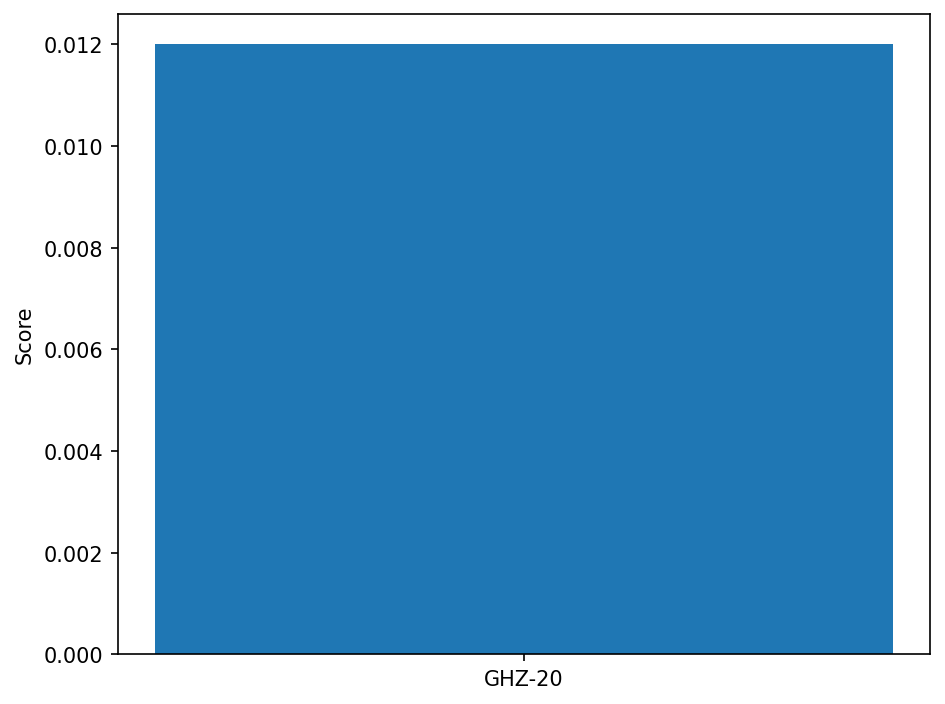

Features : [0.002374703162104737, 1.0, 0.1111111111111111, 0.02093092793780524, 0.0, 0.009462759462759464]


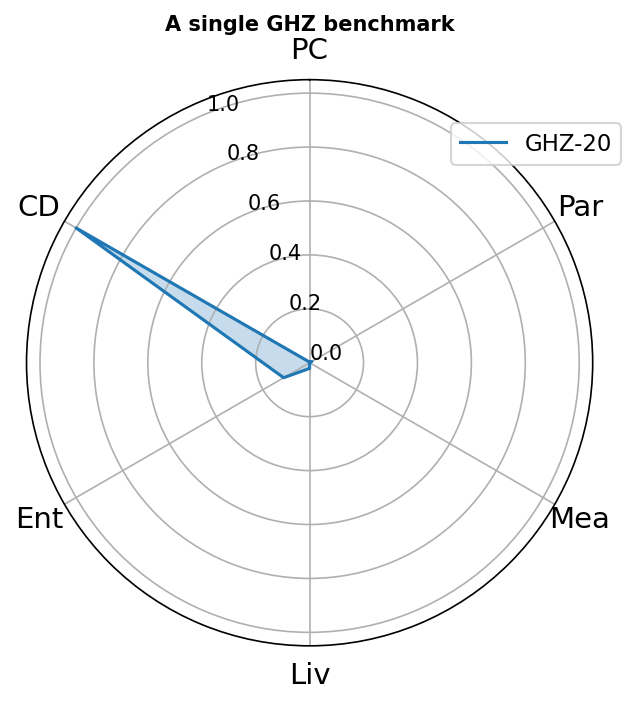

In [6]:
ghz_label, ghz_features, ghz_score = run(GHZ,qubits=qubits,shots=shots,name="GHZ")

# Hamiltonian Simulation

********** Executing on ibm_brisbane backend*****************
Score :  0.9020466094066648
Creation, execution and Quantum Times = 0.0007543563842773438,8.737581491470337 & 1 seconds


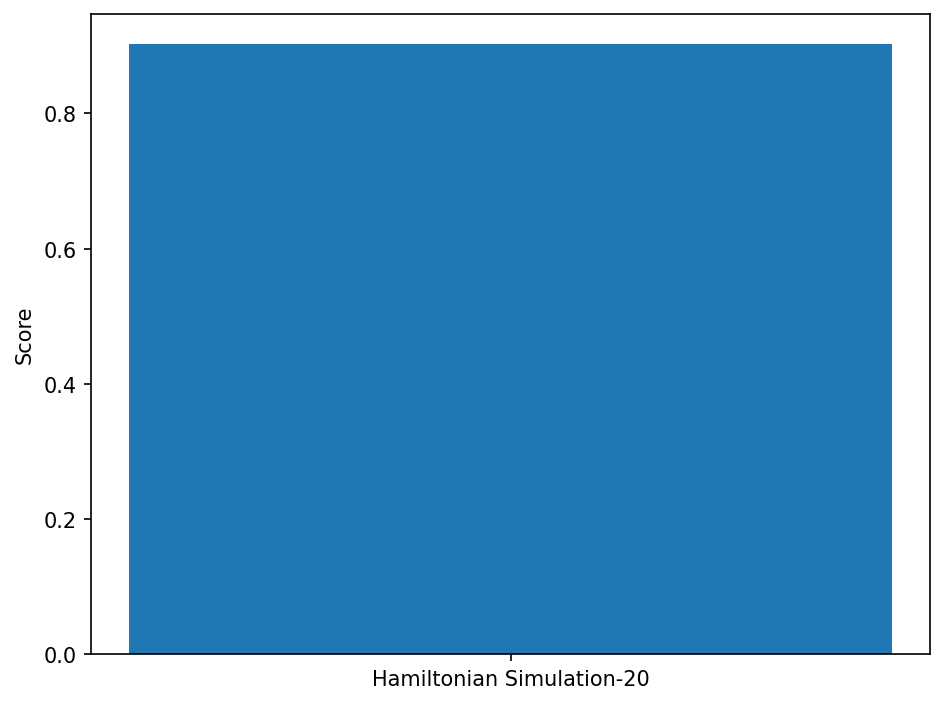

Features : [0.002374703162104737, 1.0, 0.1043956043956044, 0.025972499706193444, 0.0, 0.01394901394901395]


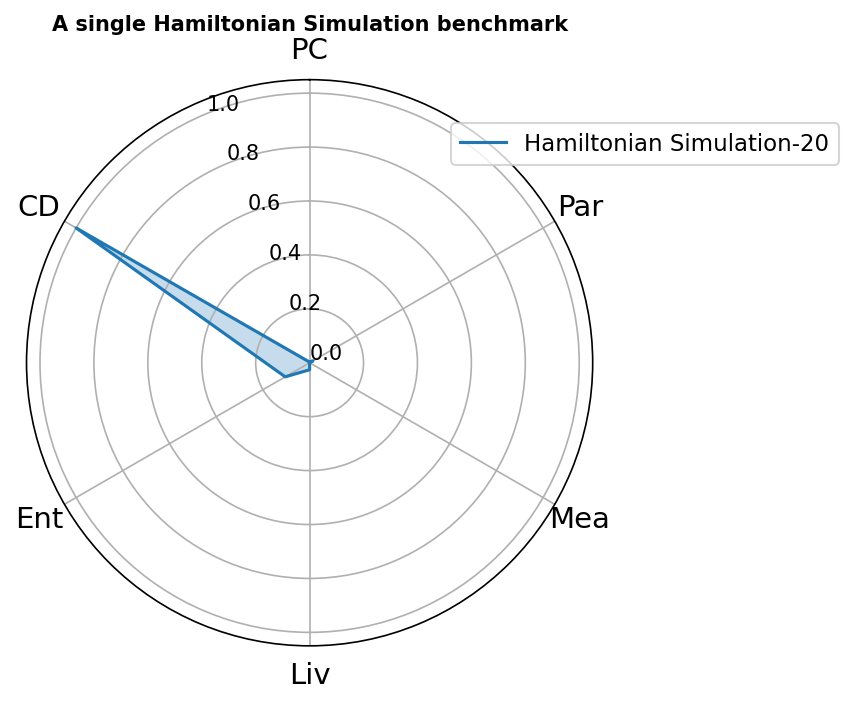

In [7]:
hs_label, hs_features, hs_score = run(HamiltonianSimulation,qubits=qubits,shots=shots,name="Hamiltonian Simulation")

# Mermin-Bell

********** Executing on ibm_brisbane backend*****************
Score :  0.5
Creation, execution and Quantum Times = 110.00164794921875,8.799696207046509 & 2 seconds


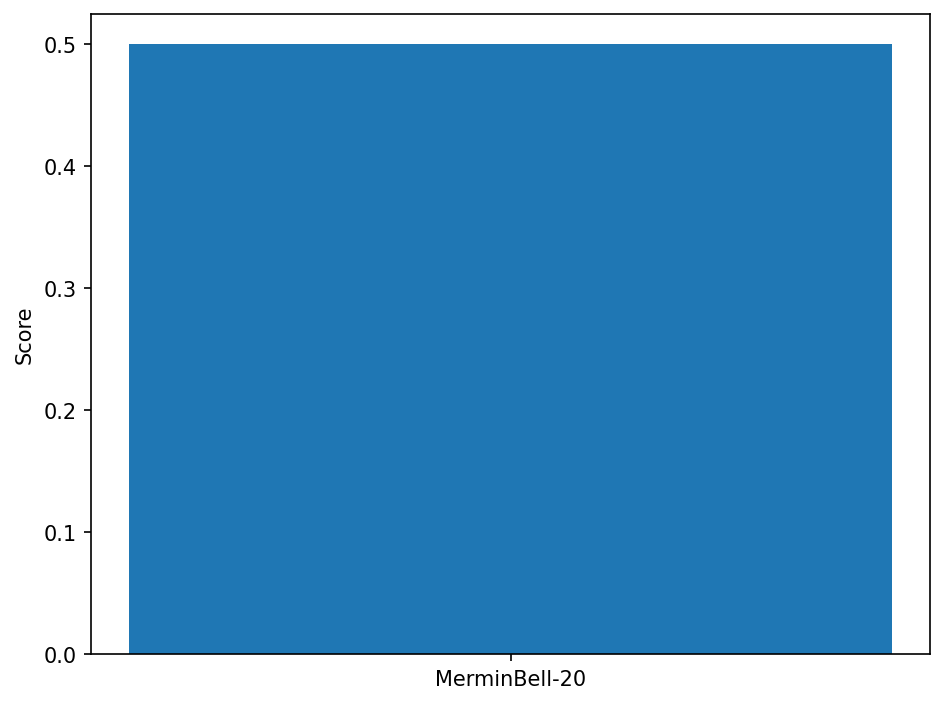

Features : [0.0029996250468691415, 0.48558758314855877, 0.16278650063165492, 0.02914648555528497, 0.0, 0.017264747350707238]


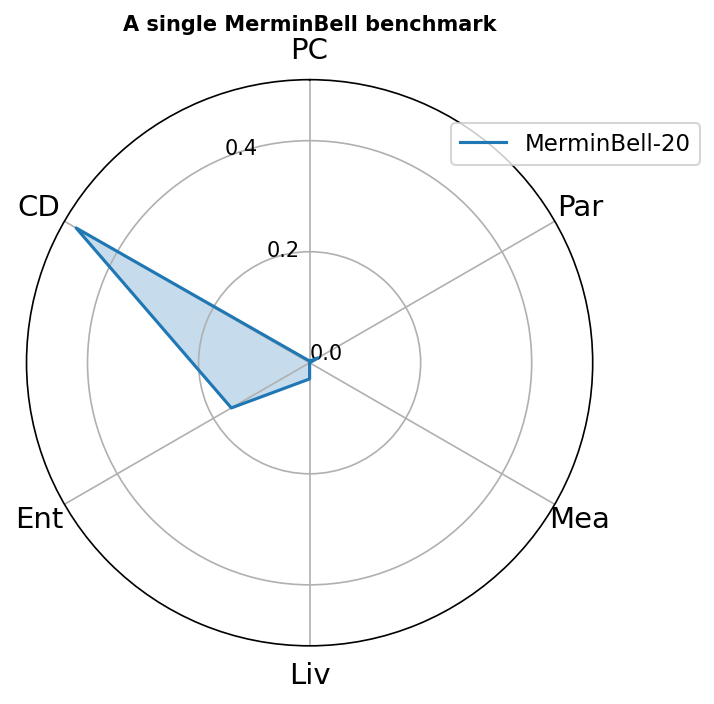

In [8]:
mb_label, mb_features, mb_score = run(MerminBell,qubits=qubits,shots=shots,name="MerminBell")

# QAOA-FermionicSwap Proxy

********** Executing on ibm_brisbane backend*****************
Score :  0.48561793760176497
Creation, execution and Quantum Times = 0.023081541061401367,10.552270889282227 & 1 seconds


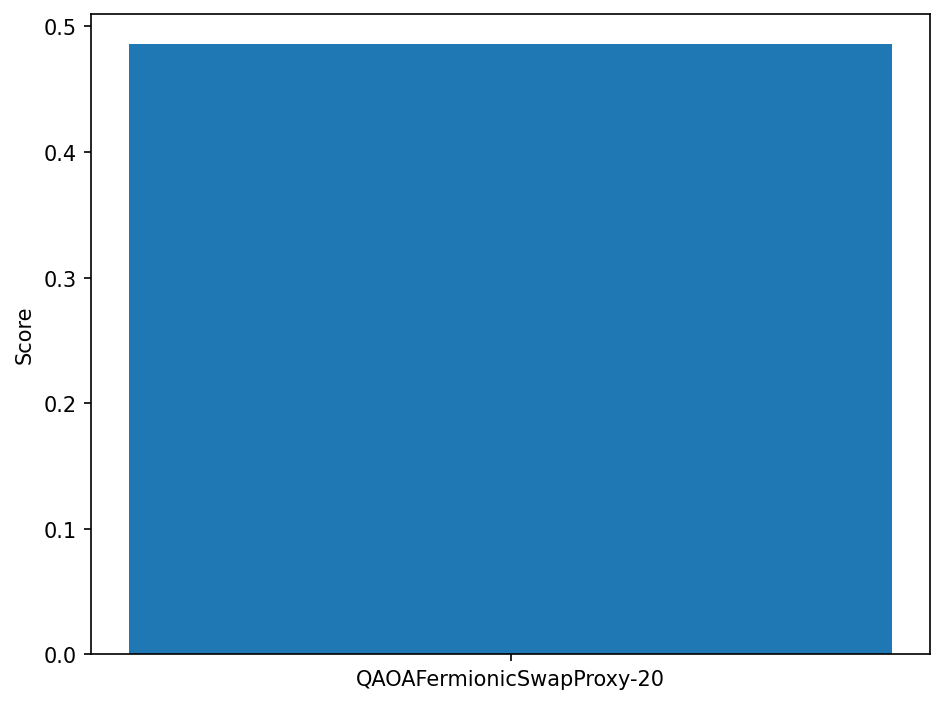

Features : [0.002374703162104737, 0.10526315789473684, 0.16691068814055637, 0.12223036073979125, 0.0, 0.09752331542214811]


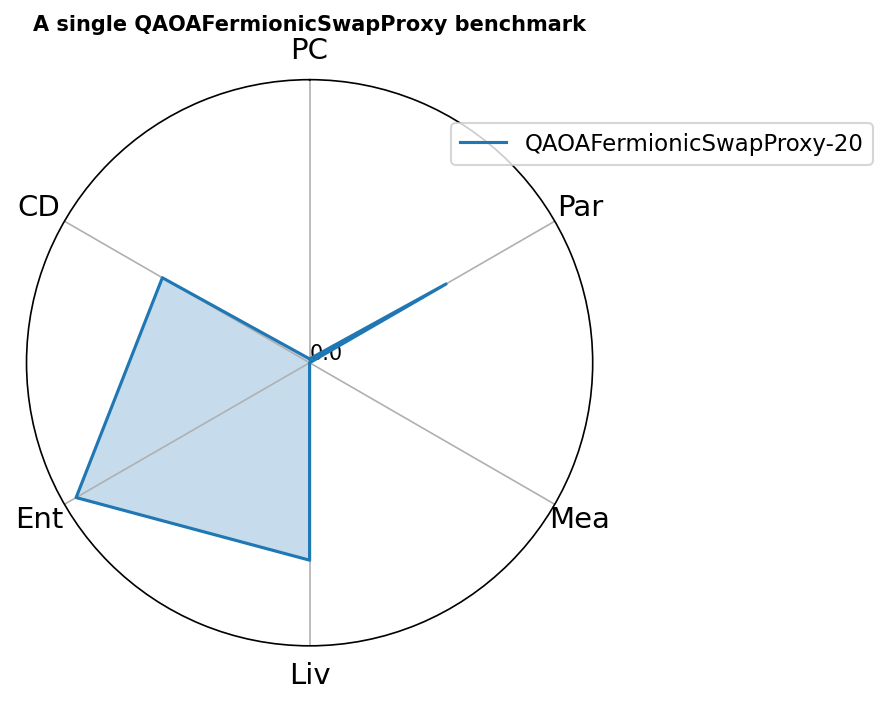

In [9]:
qaoaf_label, qaoaf_features, qaoaf_score = run(QAOAFermionicSwapProxy,qubits=qubits,shots=shots,name="QAOAFermionicSwapProxy")

# QAOA-Vanilla Proxy

********** Executing on ibm_brisbane backend*****************
Score :  0.5077430489014851
Creation, execution and Quantum Times = 0.01872730255126953,91.00451564788818 & 2 seconds


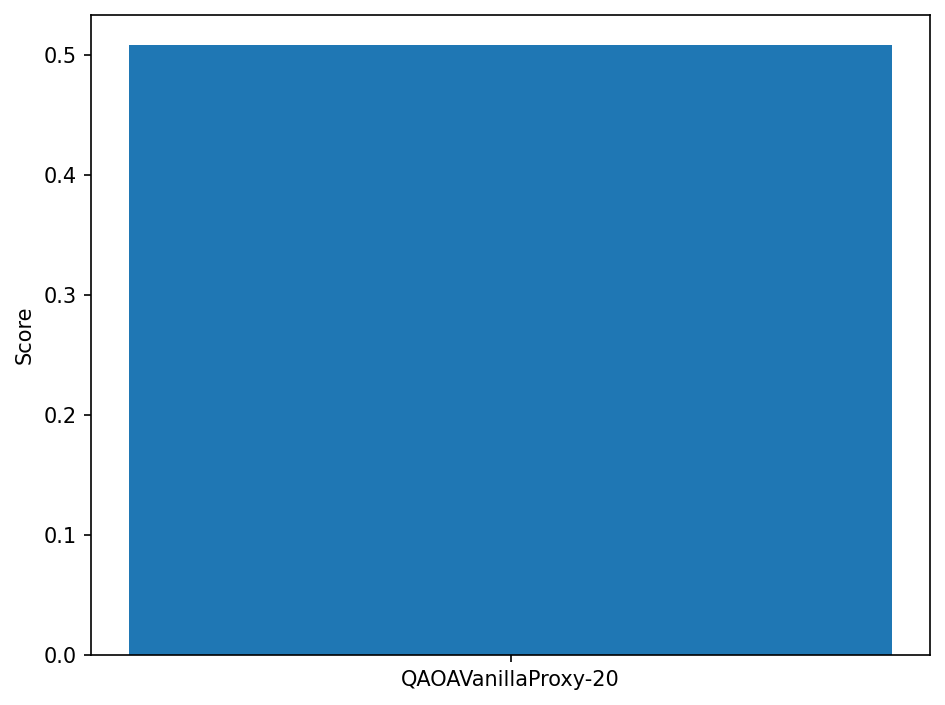

Features : [0.0029996250468691415, 0.35865595325054783, 0.18410435718128026, 0.03700116558912564, 0.0, 0.023505086637745136]


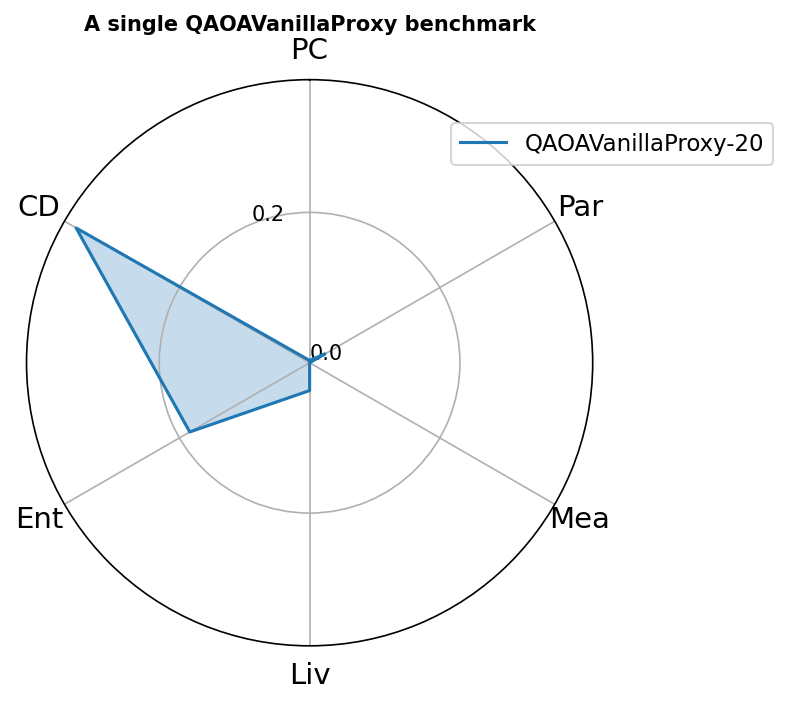

In [10]:
qaoav_label, qaoav_features, qaoav_score = run(QAOAVanillaProxy,qubits=qubits,shots=shots,name="QAOAVanillaProxy")

# Bit Code

Executing BitCode with 3 qubits.....
********** Executing on ibm_brisbane backend*****************
Score :  0.0
Creation, execution and Quantum Times = 0.0009229183197021484,8.428004503250122 & 1 seconds


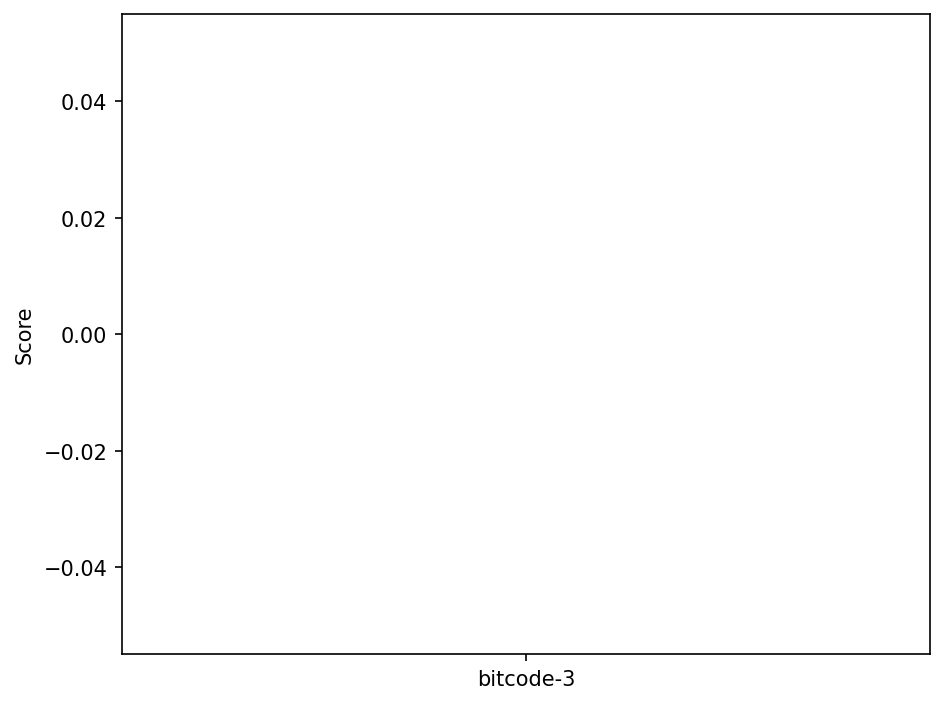

Features : [0.0004999375078115235, 0.5, 0.125, 0.02214566929133858, 0.13333333333333333, 0.008994708994708995]


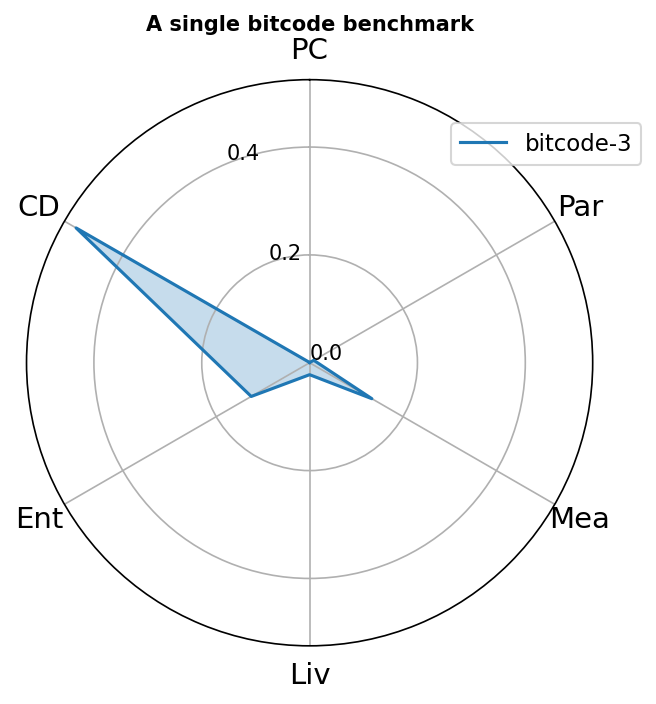

Executing BitCode with 4 qubits.....
********** Executing on ibm_brisbane backend*****************
Score :  0.0
Creation, execution and Quantum Times = 0.0012536048889160156,10.636072635650635 & 2 seconds


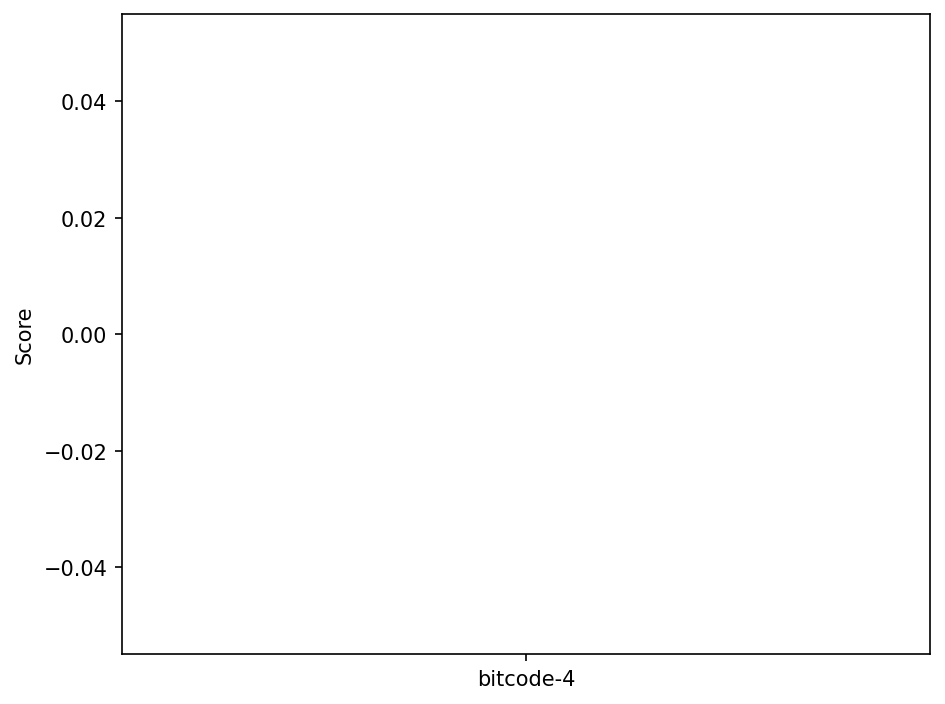

Features : [0.0007499062617172854, 0.3333333333333333, 0.12, 0.03395669291338583, 0.2, 0.01851851851851852]


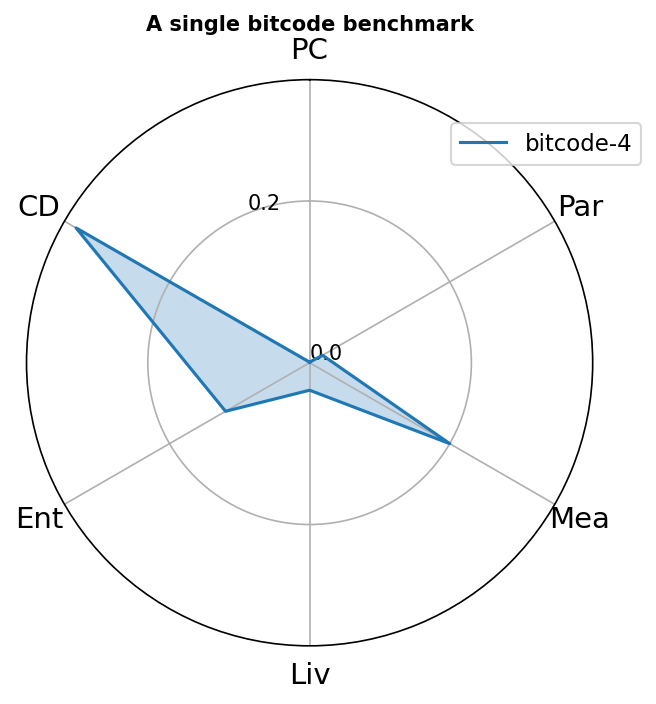

Executing BitCode with 5 qubits.....
********** Executing on ibm_brisbane backend*****************
Score :  0.0
Creation, execution and Quantum Times = 0.0014073848724365234,12.896495819091797 & 2 seconds


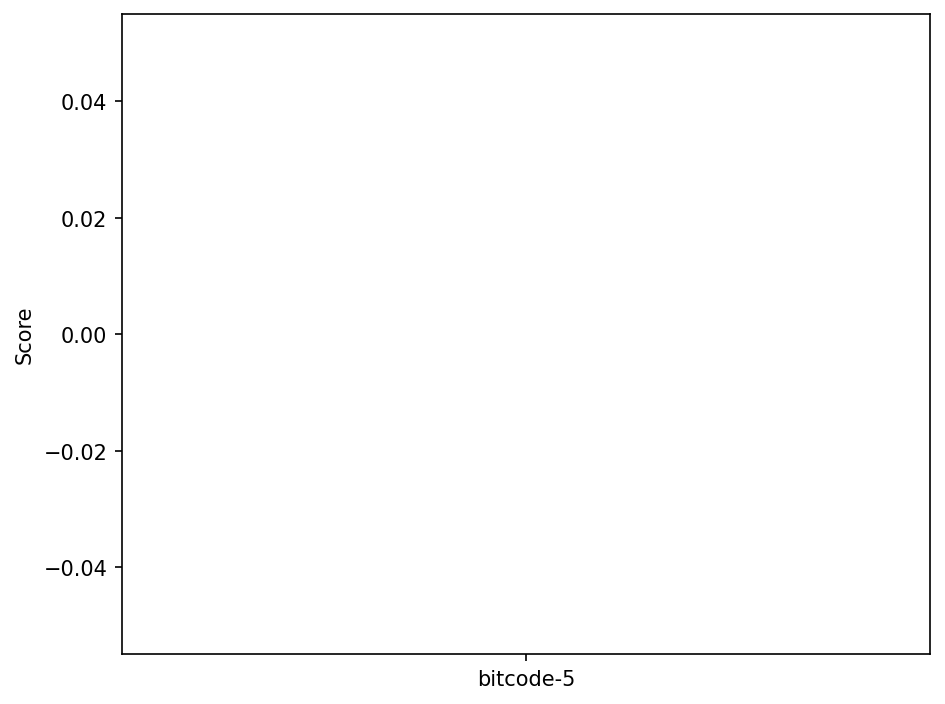

Features : [0.000999875015623047, 0.25, 0.12307692307692308, 0.04429133858267716, 0.2, 0.026455026455026454]


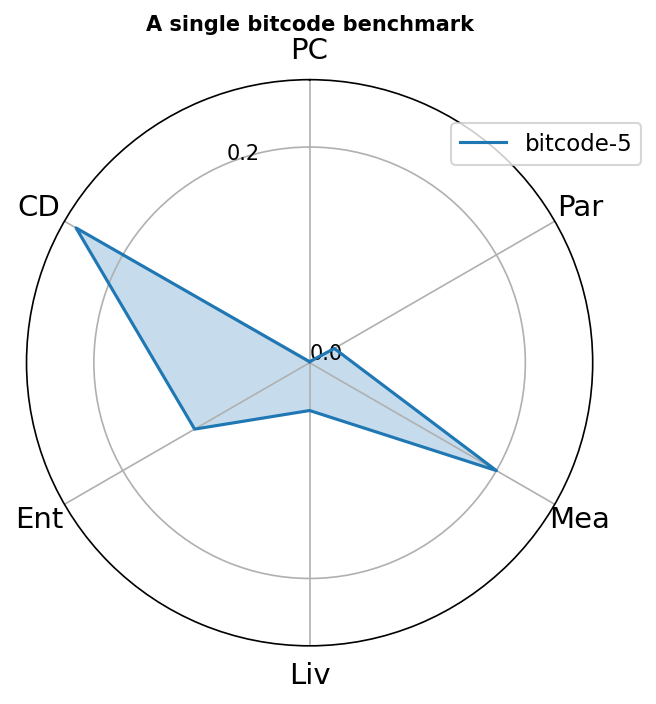

Executing BitCode with 6 qubits.....
********** Executing on ibm_brisbane backend*****************
Score :  0.0
Creation, execution and Quantum Times = 0.00152587890625,17.420079231262207 & 2 seconds


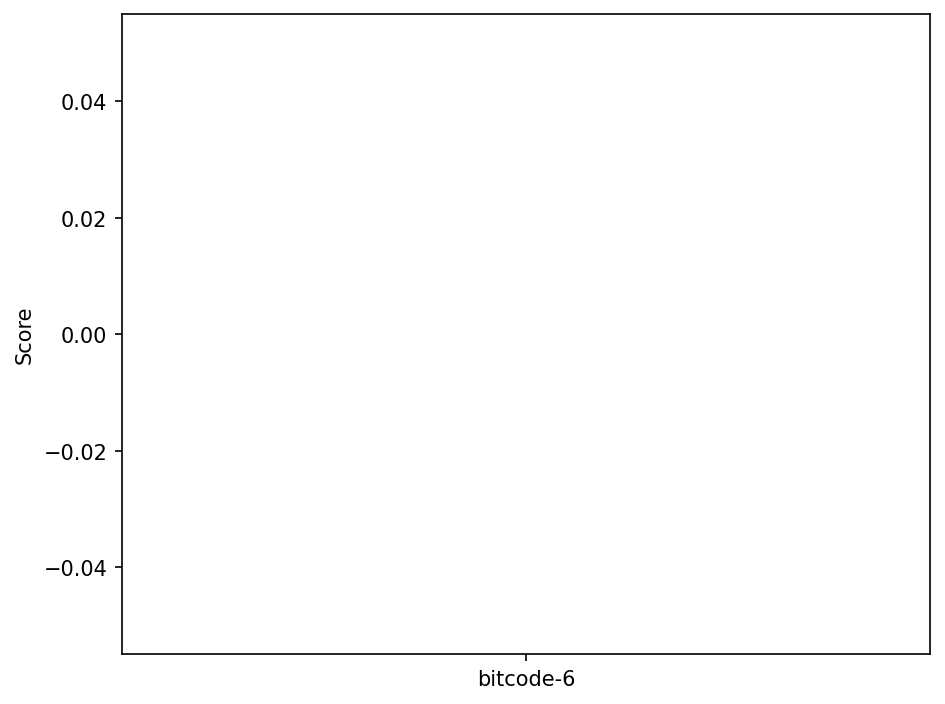

Features : [0.001249843769528809, 0.2, 0.11904761904761904, 0.056594488188976375, 0.26666666666666666, 0.0365079365079365]


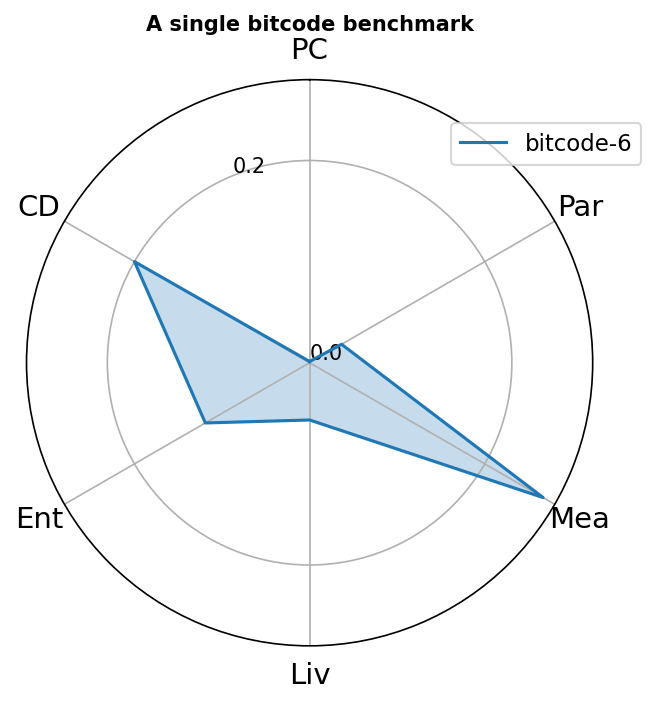

Executing BitCode with 7 qubits.....
********** Executing on ibm_brisbane backend*****************
Score :  0.0
Creation, execution and Quantum Times = 0.0016400814056396484,14.99143671989441 & 2 seconds


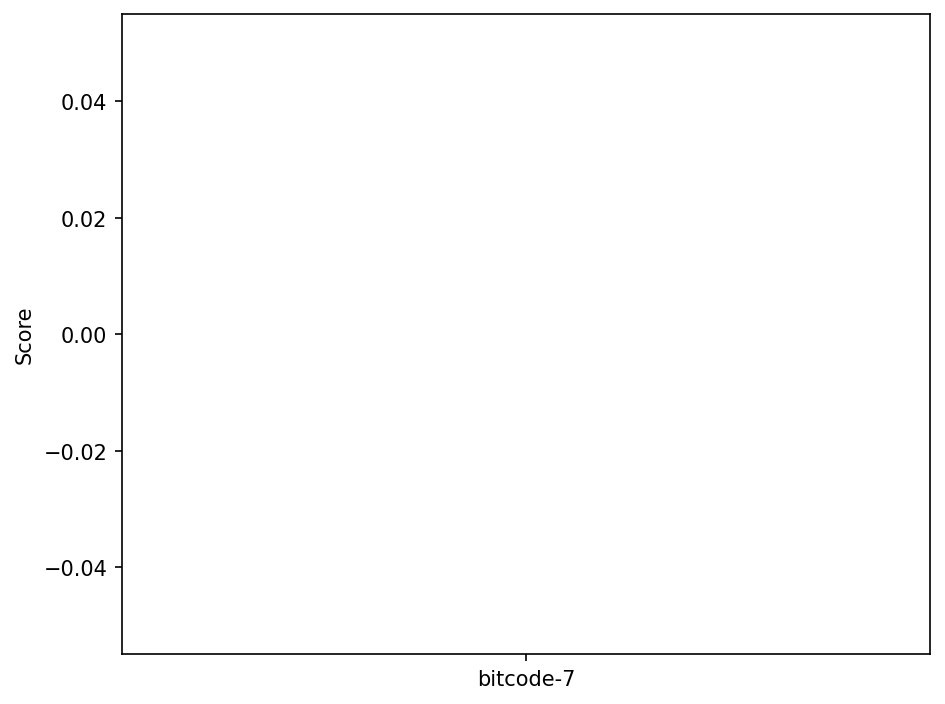

Features : [0.0014998125234345708, 0.16666666666666666, 0.12244897959183673, 0.06643700787401575, 0.26666666666666666, 0.043915343915343914]


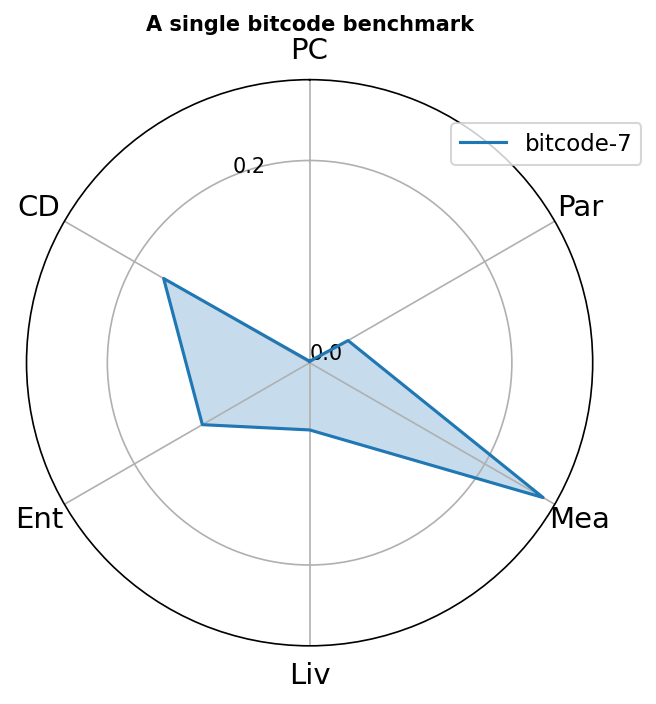

Executing BitCode with 8 qubits.....
********** Executing on ibm_brisbane backend*****************
Score :  0.0
Creation, execution and Quantum Times = 0.0017771720886230469,8.489919185638428 & 2 seconds


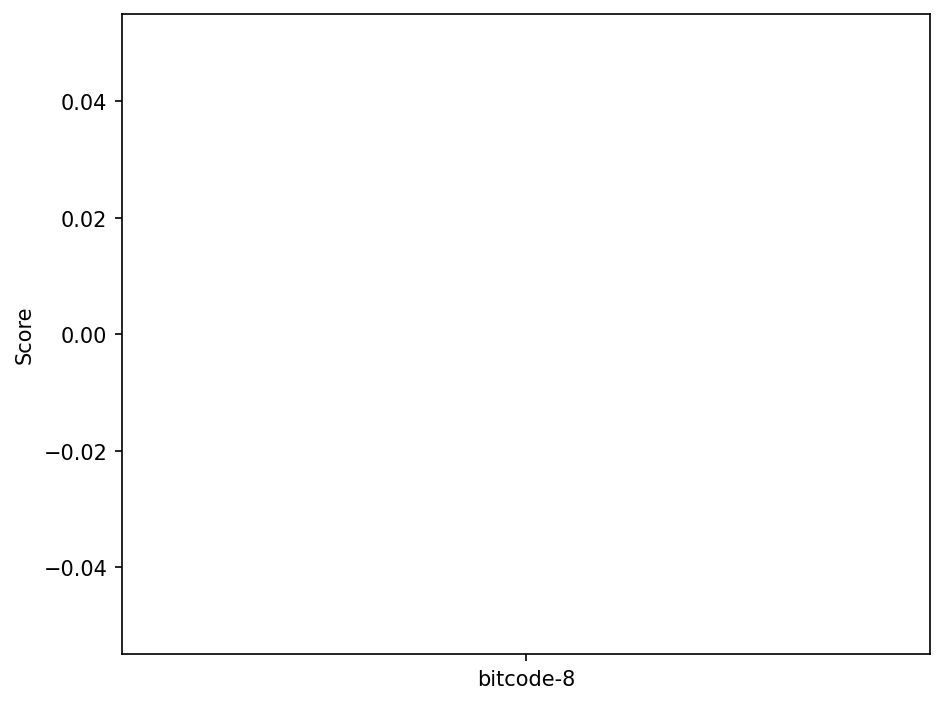

Features : [0.0017497812773403325, 0.14285714285714285, 0.11965811965811966, 0.07874015748031496, 0.26666666666666666, 0.053968253968253964]


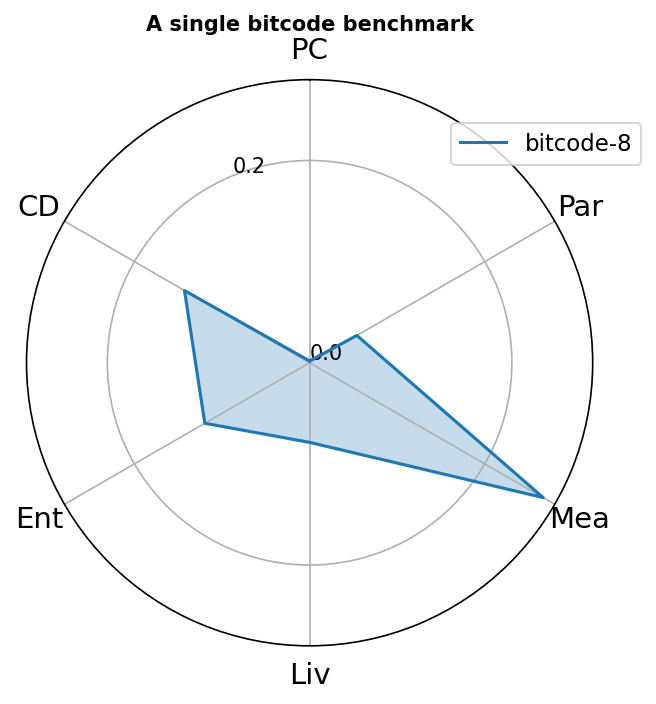

Executing BitCode with 9 qubits.....
********** Executing on ibm_brisbane backend*****************
Score :  0.0
Creation, execution and Quantum Times = 0.0020875930786132812,23.585148811340332 & 2 seconds


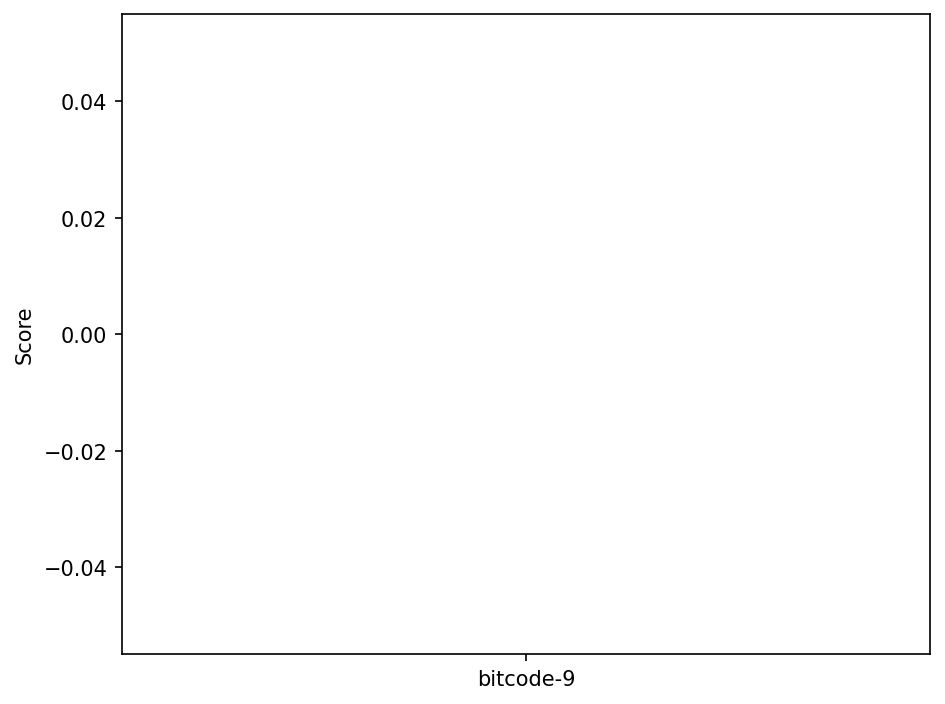

Features : [0.001999750031246094, 0.125, 0.11678832116788321, 0.09153543307086615, 0.26666666666666666, 0.06455026455026455]


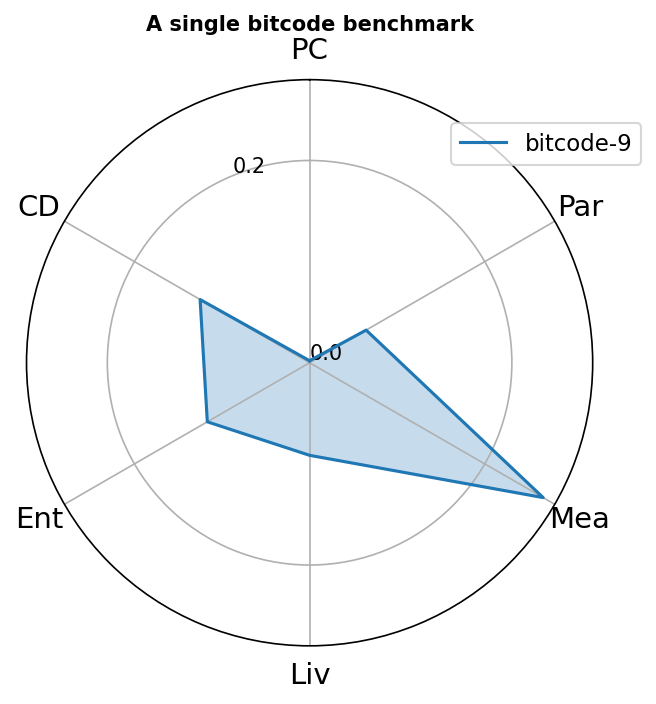

Executing BitCode with 10 qubits.....
********** Executing on ibm_brisbane backend*****************
Score :  0.0
Creation, execution and Quantum Times = 0.0018990039825439453,10.644083261489868 & 2 seconds


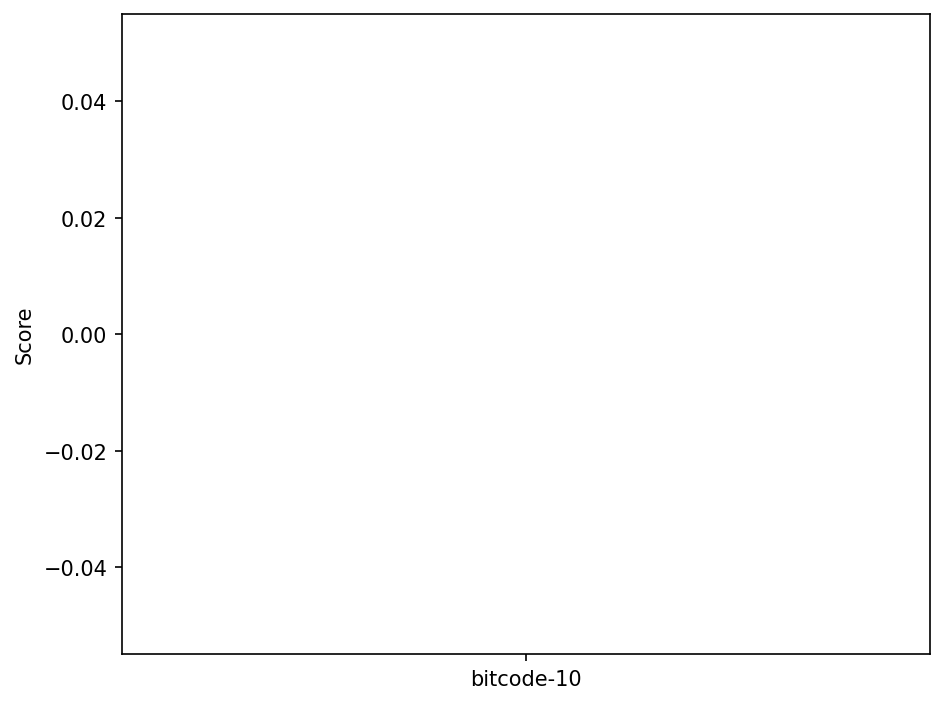

Features : [0.0022497187851518562, 0.1111111111111111, 0.11612903225806452, 0.10334645669291338, 0.26666666666666666, 0.07407407407407408]


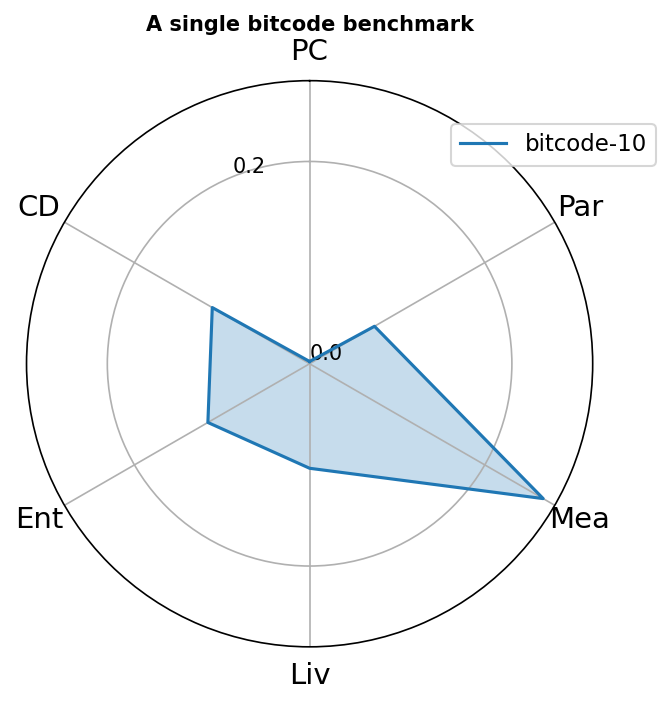

Executing BitCode with 11 qubits.....
********** Executing on ibm_brisbane backend*****************
Score :  0.0
Creation, execution and Quantum Times = 0.0019490718841552734,9.838497161865234 & 2 seconds


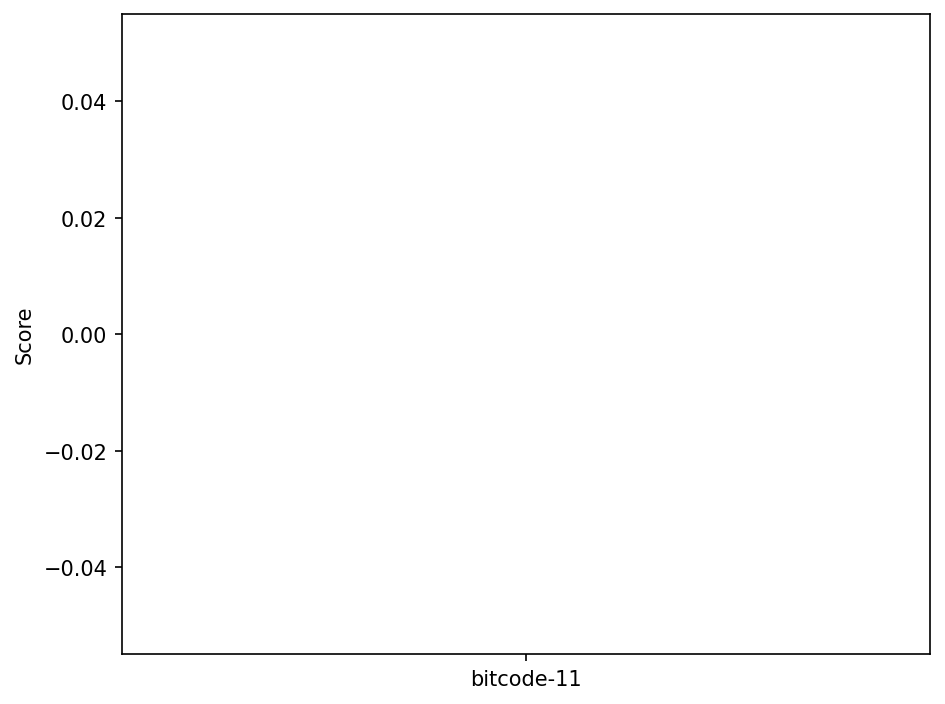

Features : [0.002499687539057618, 0.1, 0.11695906432748537, 0.1141732283464567, 0.2, 0.08253968253968254]


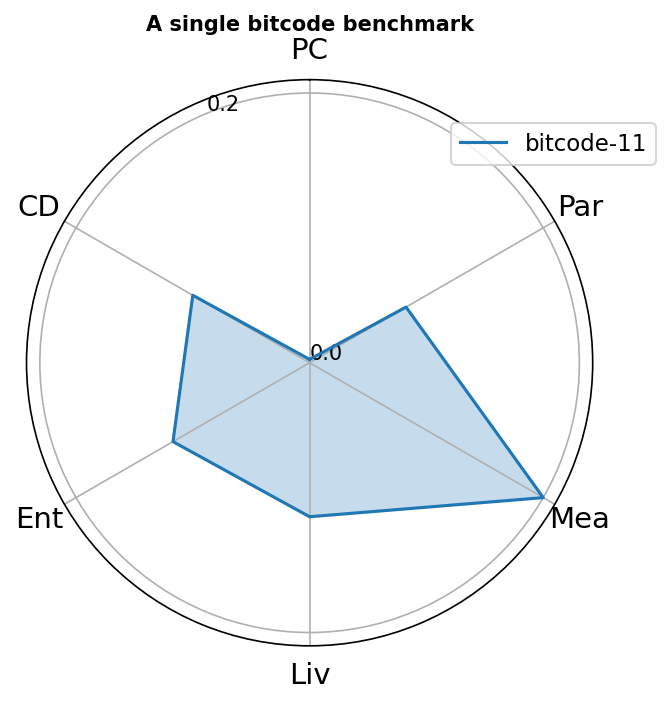

Executing BitCode with 12 qubits.....
********** Executing on ibm_brisbane backend*****************
Score :  0.0
Creation, execution and Quantum Times = 0.00234222412109375,8.984990119934082 & 2 seconds


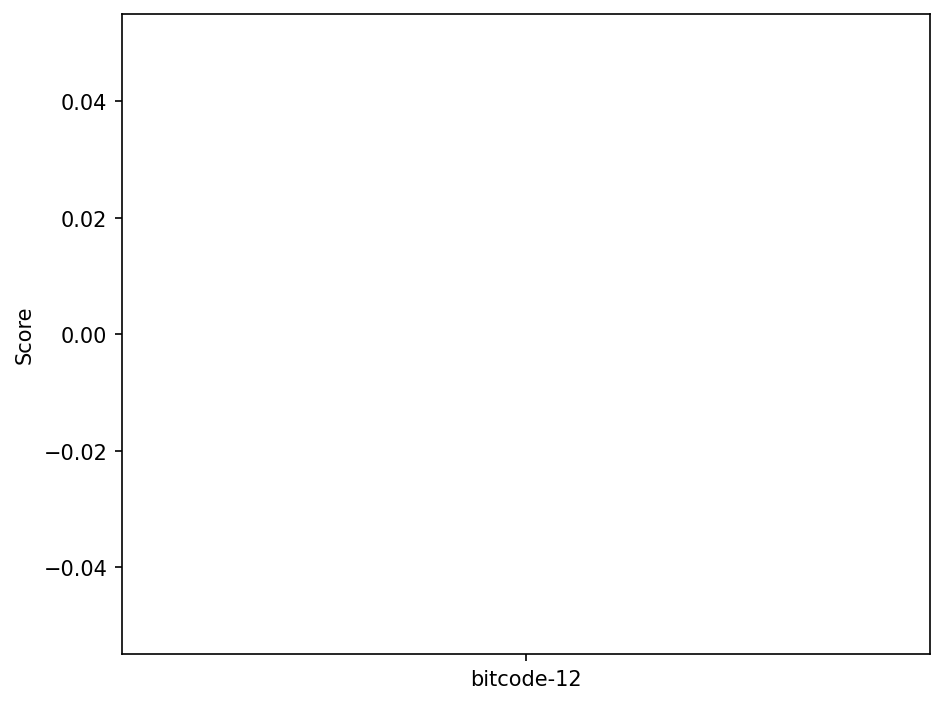

Features : [0.0027496562929633797, 0.09090909090909091, 0.1134020618556701, 0.12844488188976377, 0.26666666666666666, 0.09470899470899471]


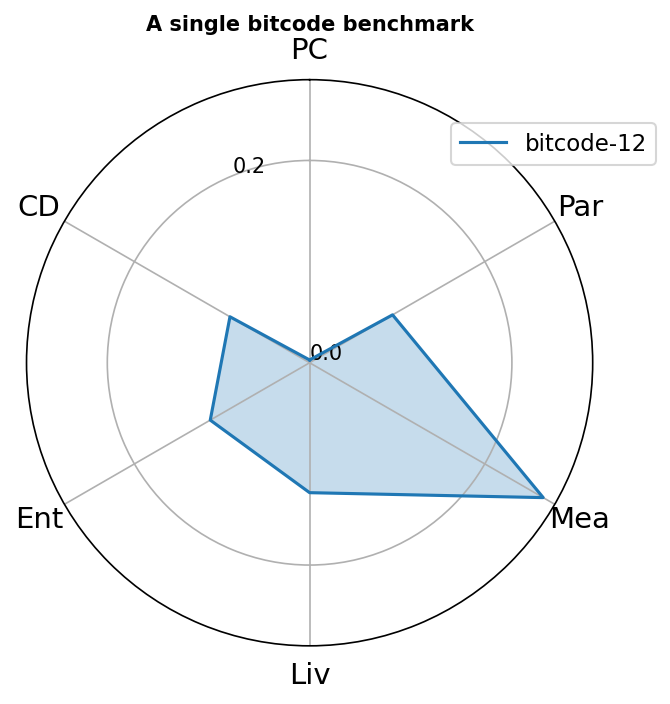

Executing BitCode with 13 qubits.....
********** Executing on ibm_brisbane backend*****************
Score :  0.0
Creation, execution and Quantum Times = 0.002184152603149414,86.0339035987854 & 2 seconds


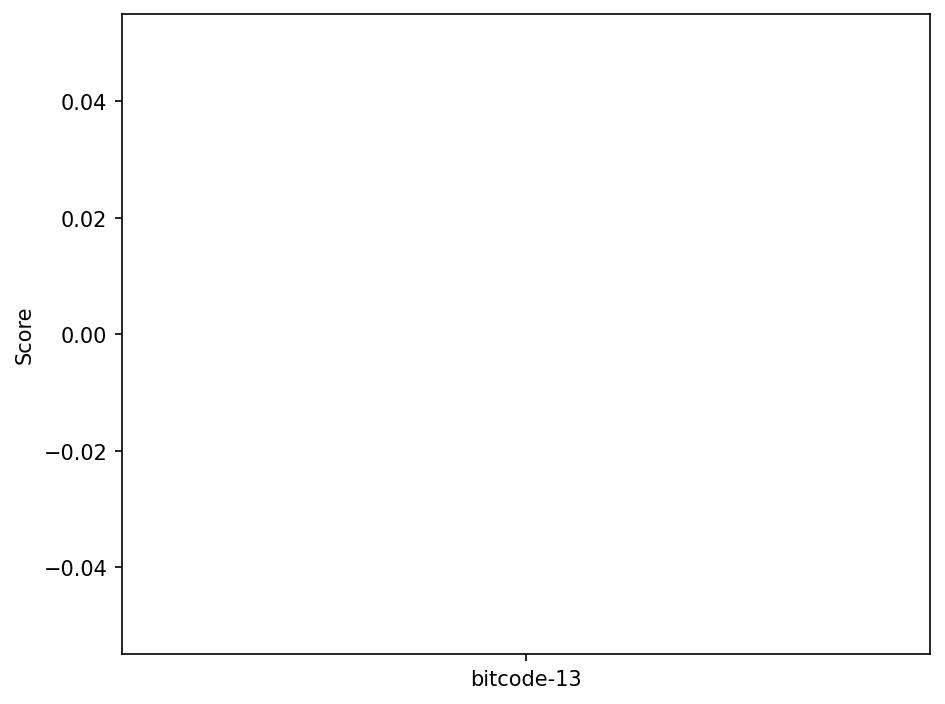

Features : [0.0029996250468691415, 0.08333333333333333, 0.11374407582938388, 0.13976377952755906, 0.26666666666666666, 0.1037037037037037]


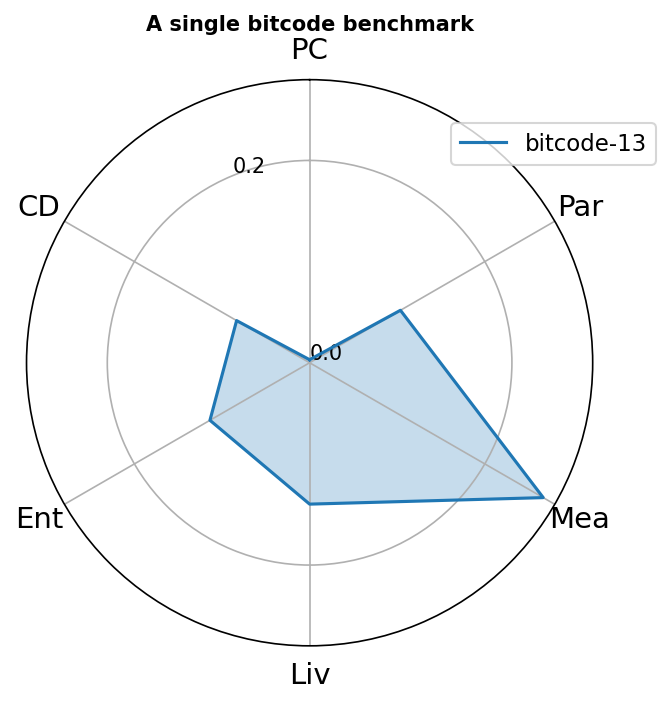

Executing BitCode with 14 qubits.....
********** Executing on ibm_brisbane backend*****************
Score :  0.0
Creation, execution and Quantum Times = 0.0022923946380615234,32.30638122558594 & 2 seconds


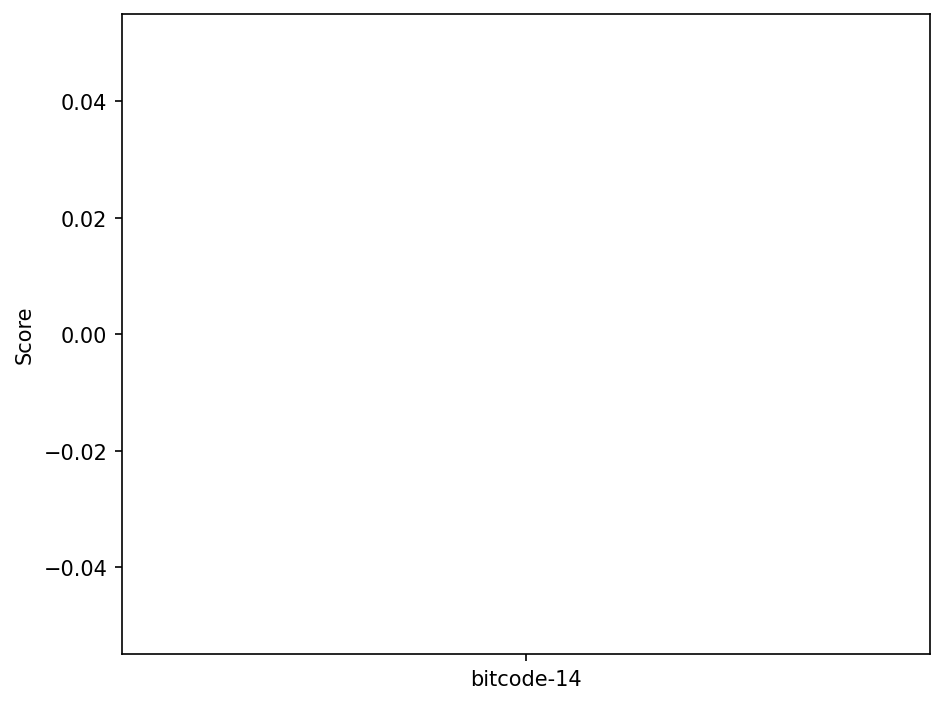

Features : [0.0032495938007749033, 0.07692307692307693, 0.11607142857142858, 0.14911417322834647, 0.26666666666666666, 0.11058201058201059]


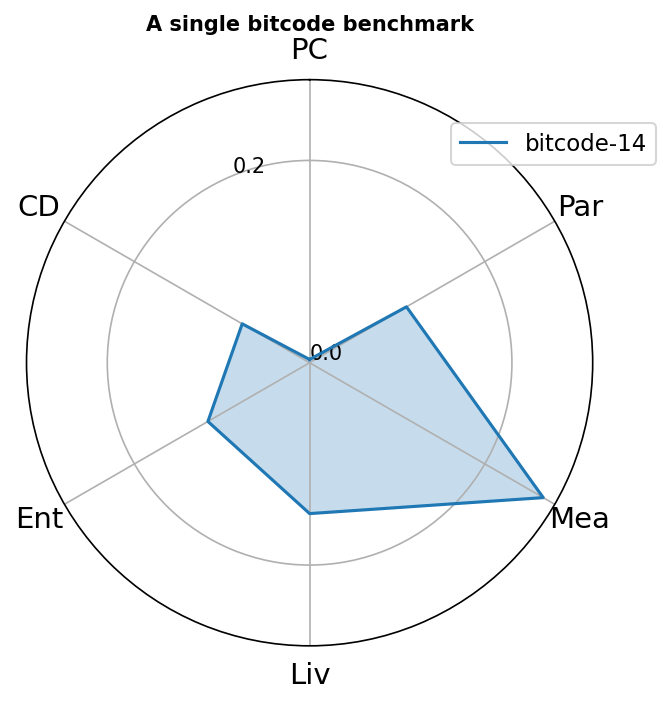

Executing BitCode with 15 qubits.....
********** Executing on ibm_brisbane backend*****************
Score :  0.0
Creation, execution and Quantum Times = 0.002470254898071289,174.10480856895447 & 3 seconds


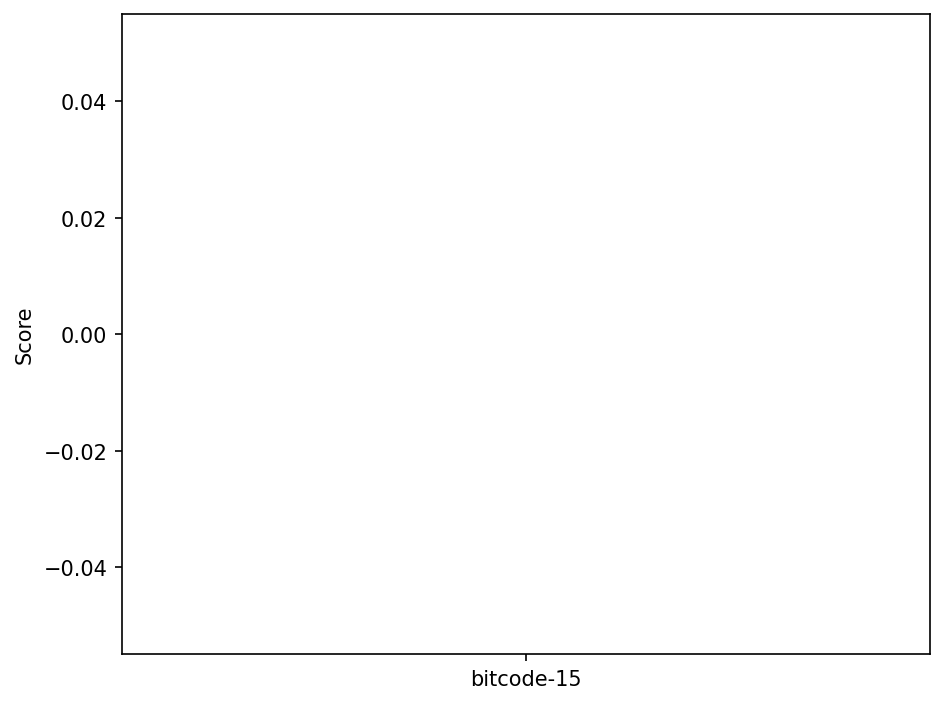

Features : [0.003499562554680665, 0.07142857142857142, 0.11764705882352941, 0.15895669291338582, 0.26666666666666666, 0.11798941798941799]


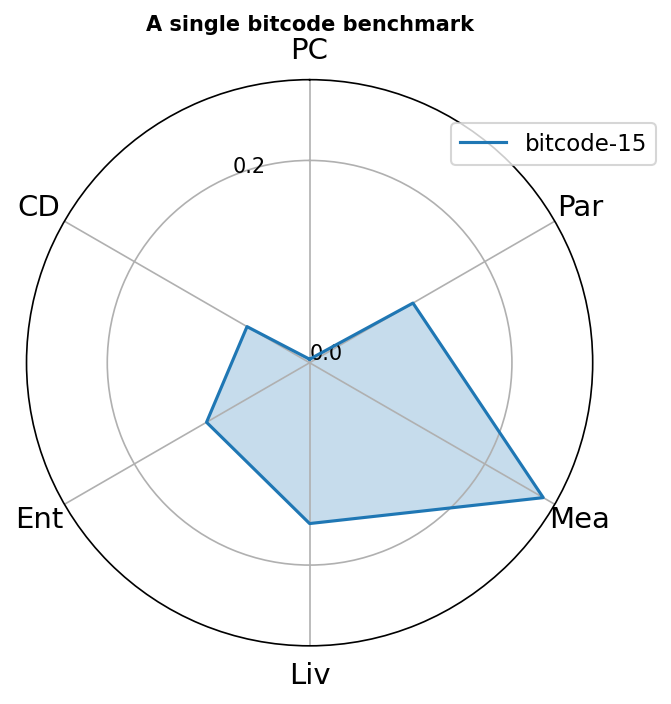

Executing BitCode with 16 qubits.....
********** Executing on ibm_brisbane backend*****************
Score :  0.0
Creation, execution and Quantum Times = 0.004909992218017578,58.109315633773804 & 3 seconds


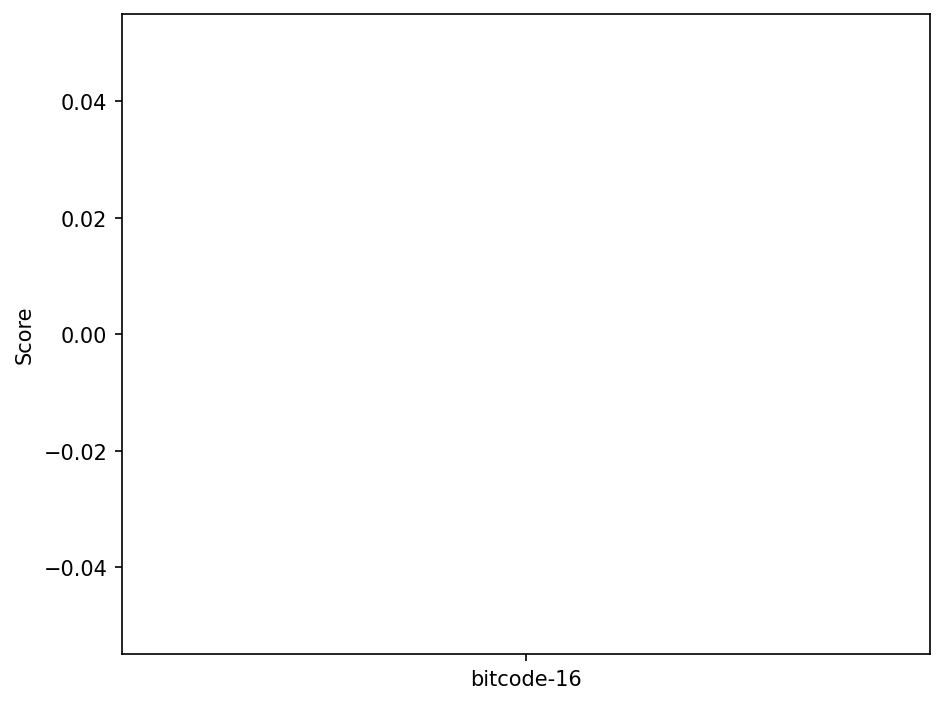

Features : [0.0037495313085864268, 0.06666666666666667, 0.11320754716981132, 0.17519685039370078, 0.26666666666666666, 0.1322751322751323]


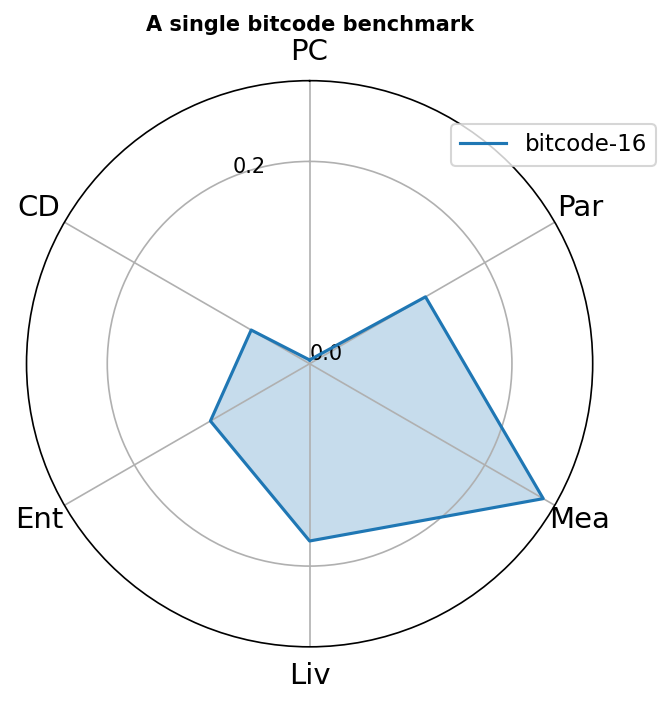

Executing BitCode with 17 qubits.....
********** Executing on ibm_brisbane backend*****************
Score :  0.0
Creation, execution and Quantum Times = 0.0035276412963867188,73.15186905860901 & 3 seconds


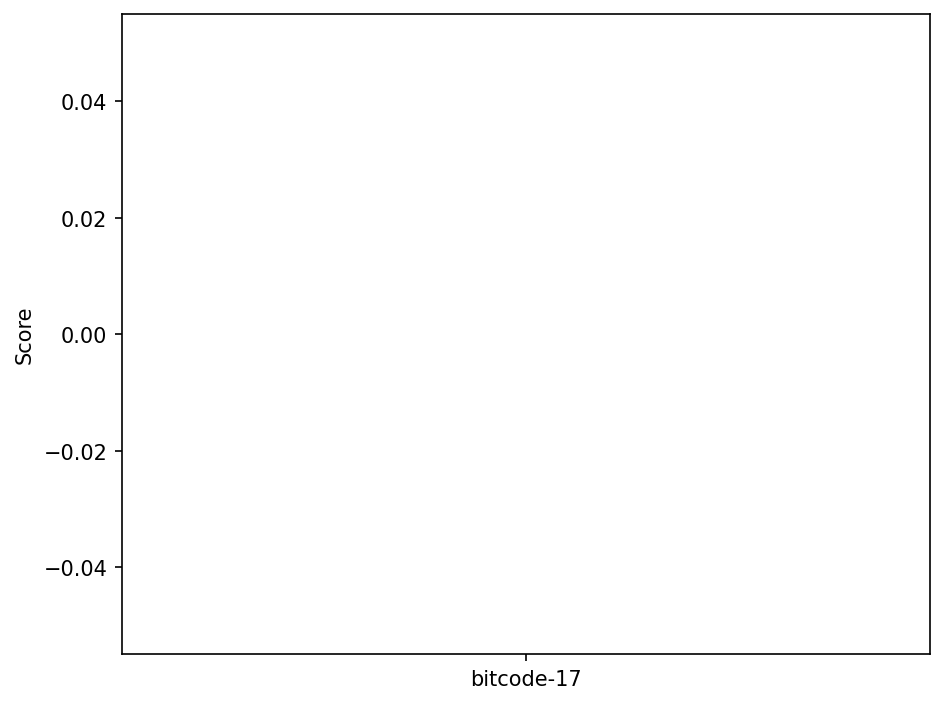

Features : [0.003999500062492188, 0.0625, 0.11678832116788321, 0.18257874015748032, 0.26666666666666666, 0.13703703703703704]


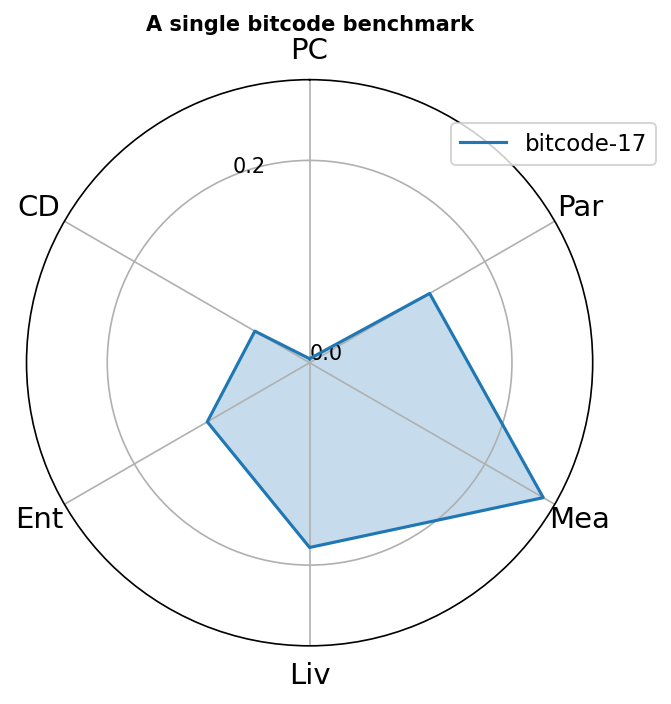

Executing BitCode with 18 qubits.....
********** Executing on ibm_brisbane backend*****************
Score :  0.0
Creation, execution and Quantum Times = 0.0029206275939941406,17.646488666534424 & 3 seconds


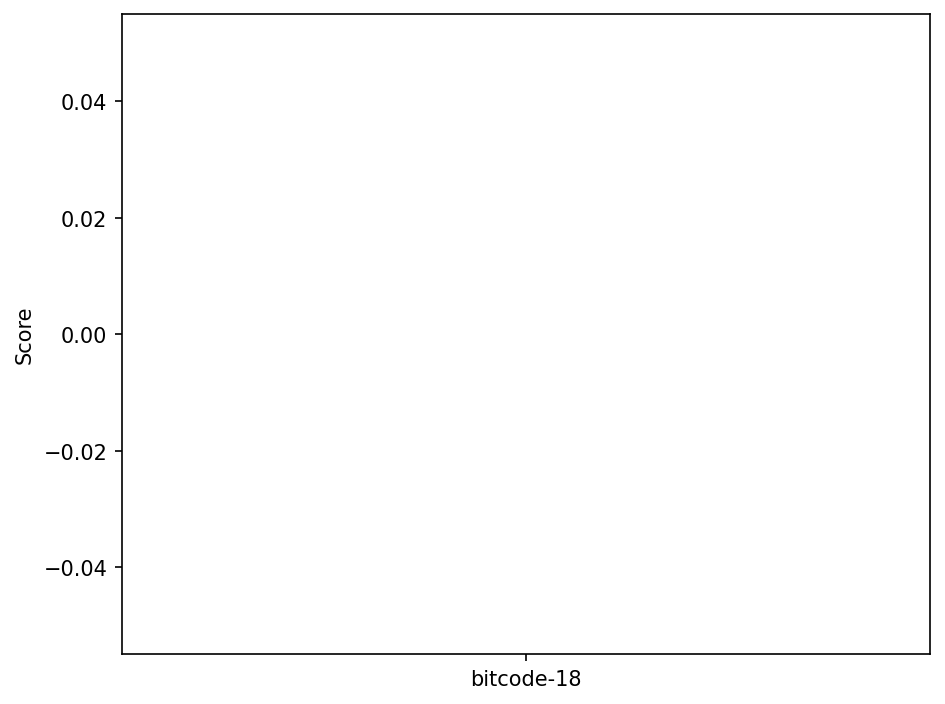

Features : [0.00424946881639795, 0.058823529411764705, 0.1152542372881356, 0.19586614173228348, 0.26666666666666666, 0.14814814814814817]


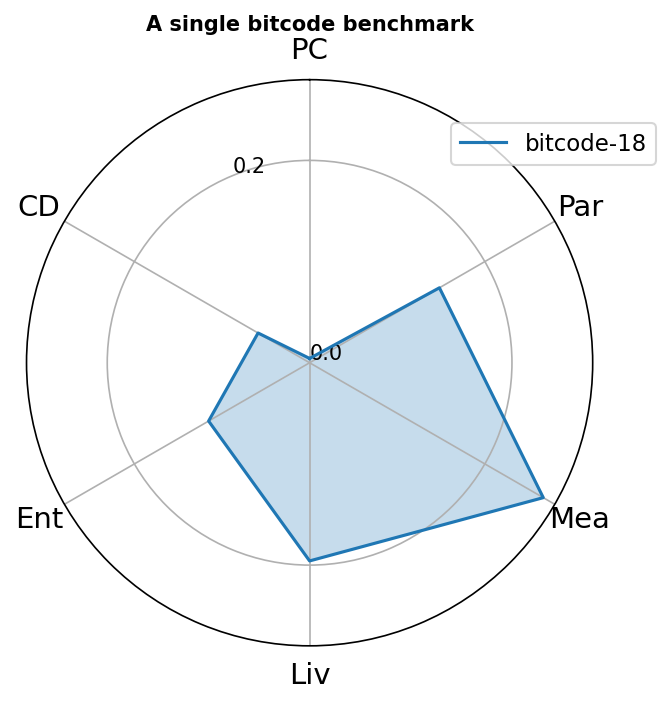

Executing BitCode with 19 qubits.....
********** Executing on ibm_brisbane backend*****************
Score :  0.0
Creation, execution and Quantum Times = 0.003201723098754883,19.211170434951782 & 9 seconds


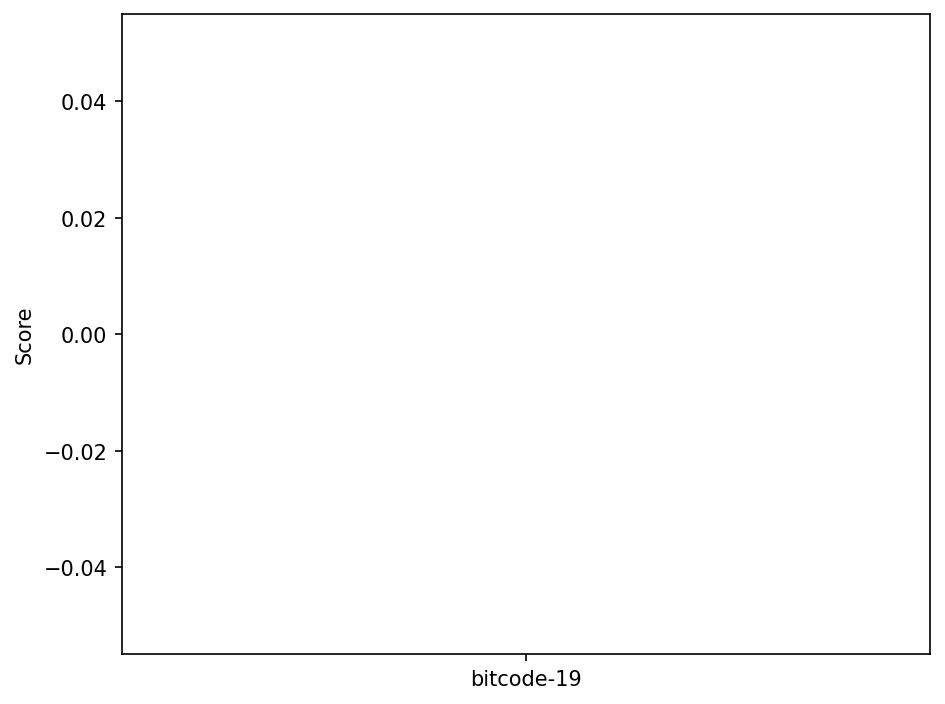

Features : [0.0044994375703037125, 0.05555555555555555, 0.11920529801324503, 0.20226377952755906, 0.4, 0.15185185185185185]


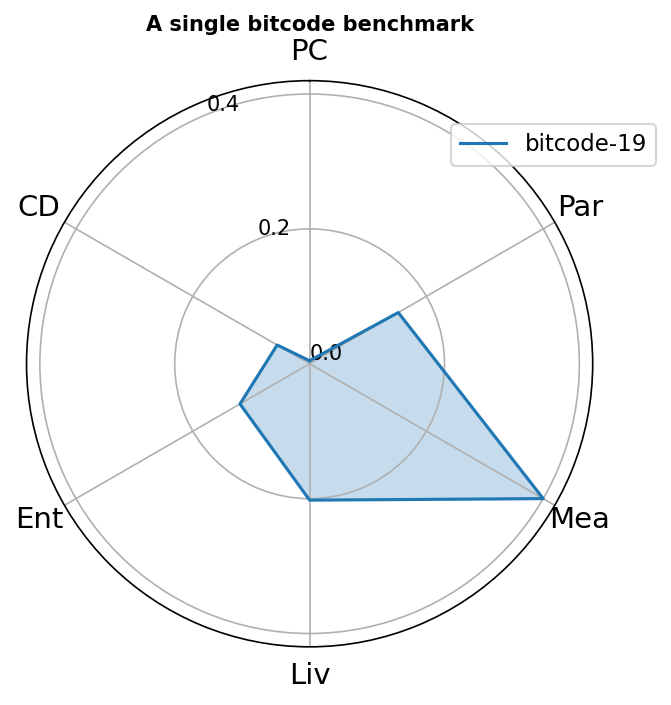

Executing BitCode with 20 qubits.....
********** Executing on ibm_brisbane backend*****************
Score :  0.0
Creation, execution and Quantum Times = 0.0030667781829833984,11.411638021469116 & 3 seconds


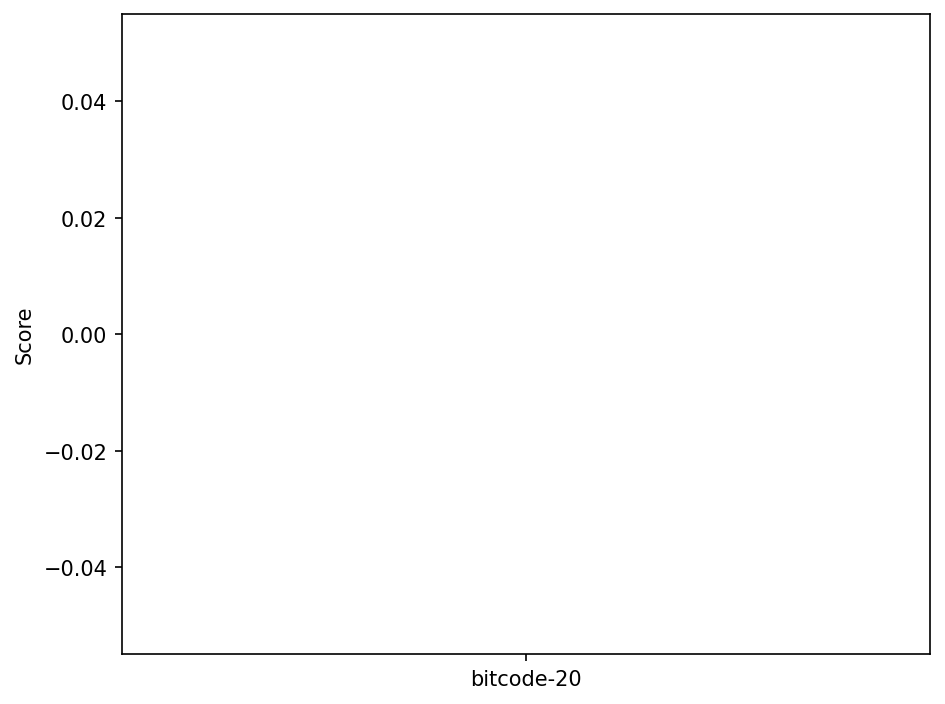

Features : [0.004749406324209474, 0.05263157894736842, 0.12297734627831715, 0.20866141732283464, 0.4, 0.15555555555555556]


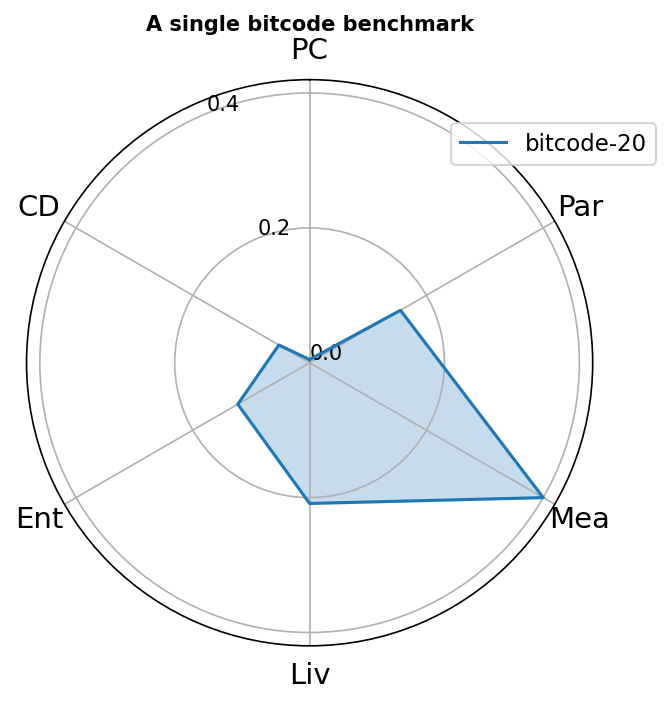

In [26]:
# '''
#     Args:
#         num_data: The number of data qubits.
#         num_rounds: The number of measurement rounds.
#         bit_state: A list denoting the state to initialize each data qubit to.

#     Returns:
#         A `cirq.Circuit` for the bit-flip error correcting code.
# '''

# num_data_qubits = 3
# num_rounds = 1
# bit_state = [1, 1, 1]

def bc(q):
    print(f"Executing BitCode with {q} qubits.....")
    shots = 1000
    name = "bitcode"
    t_c = time.time()
    qubits = q
    
    bc = BitCode(q,1,[1]*q)
    bc_ckt = bc.circuit()
    #only Cirq's implementation for ckt creation
    qc = cirq_to_qiskit(bc_ckt)
    creation_time = time.time()-t_c  #in sec
    
    print(f"********** Executing on {backend.name} backend*****************")
    
    qc = transpile(qc, backend=backend, optimization_level=2)

    # Calculate Execution time 
    t_e = time.time()
    job = sampler.run([qc], shots=shots)
    result = job.result()
    execution_time = time.time() - t_e #in sec
    #print(result)
    
    # Calculate quantum processing time 
    quantum_time = (job.usage()) #in sec

    #finding creg
    reg = qc.cregs[0].name

    counts = result[0].data[reg].get_counts()
    #print("counts : ",counts)
    
    score = bc.score(counts)
    print("Score : ",score)
    #device_scores.append(score)
    print(f"Creation, execution and Quantum Times = {creation_time},{execution_time} & {quantum_time} seconds")

    benchmark_name = f"{name}-{qubits}"
    plot_results([score],[benchmark_name])

    features = [
    compute_communication_with_qiskit(qc),
    compute_depth_with_qiskit(qc),
    compute_entanglement_with_qiskit(qc),
    compute_liveness_with_qiskit(qc),
    compute_measurement_with_qiskit(qc),
    compute_parallelism_with_qiskit(qc),
    ]

    label = str(name)+"_"+str(qubits)
    
    Features[label] = features
    print("Features :",features)

    plot_benchmark(title=f"A single {name} benchmark",labels=[benchmark_name],features=[features],
                   spoke_labels=["PC", "CD", "Ent", "Liv", "Mea", "Par"] )


if __name__=="__main__":
    for i in range(3,21):
        bc(i)

# Phase Code

Executing BitCode with 3 qubits.....
********** Executing on ibm_brisbane backend*****************
Score :  0.0
Creation, execution and Quantum Times = 0.0014710426330566406,10.930474758148193 & 3 seconds


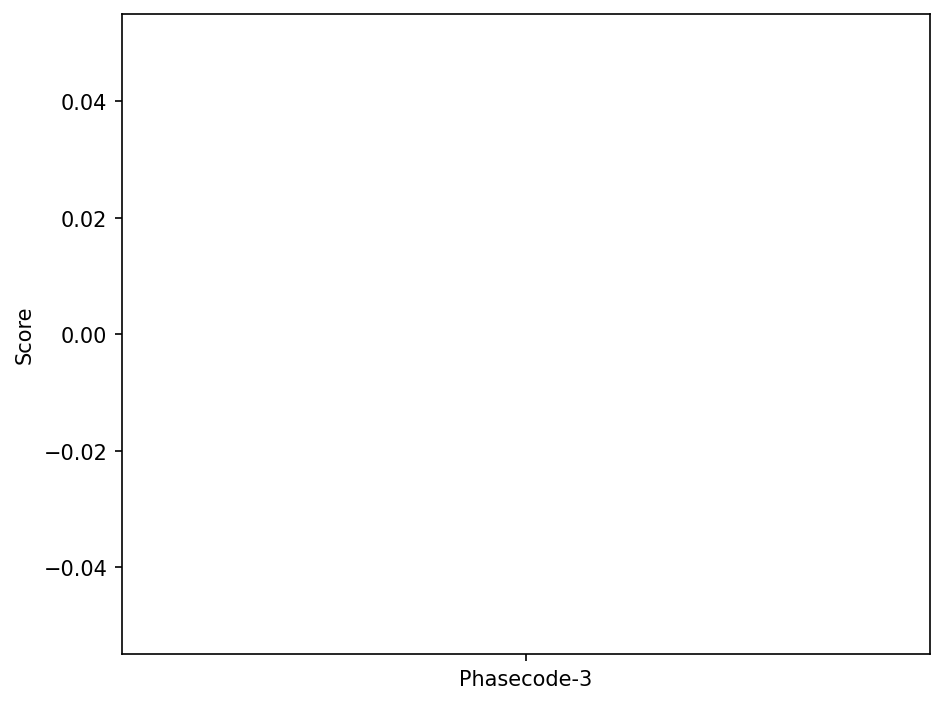

Features : [0.0004999375078115235, 0.5, 0.125, 0.03221188260558339, 0.1, 0.01746031746031746]


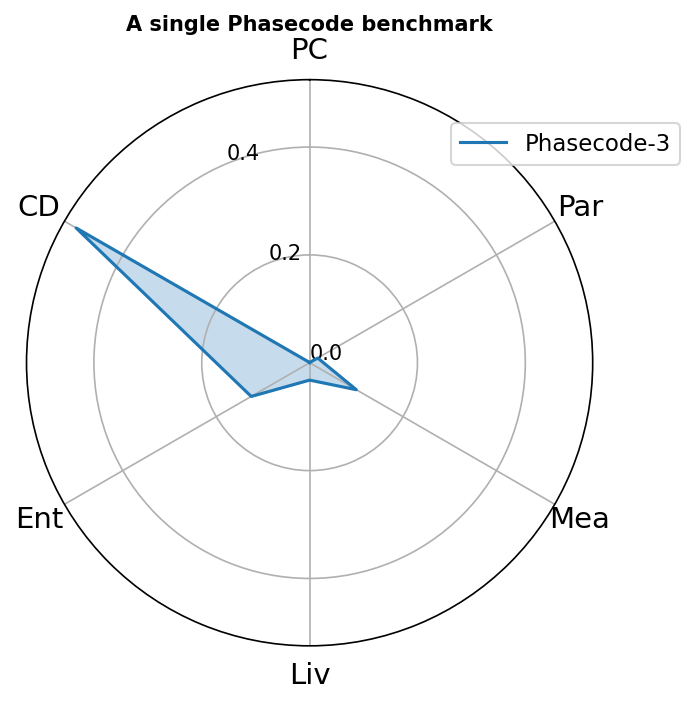

Executing BitCode with 4 qubits.....
********** Executing on ibm_brisbane backend*****************
Score :  0.0
Creation, execution and Quantum Times = 0.0026369094848632812,8.716153144836426 & 2 seconds


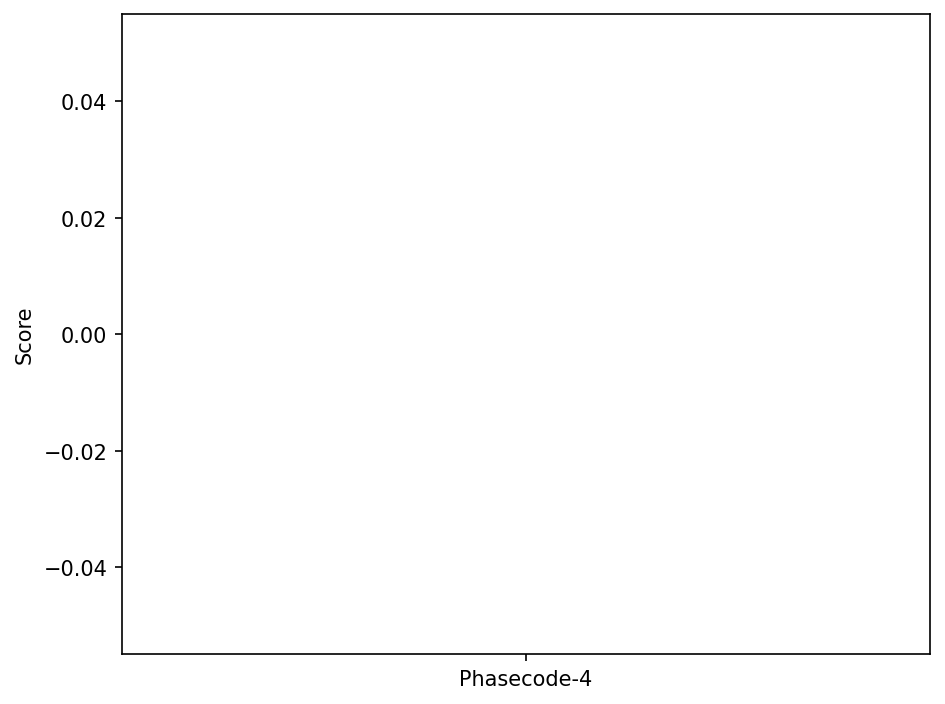

Features : [0.0007499062617172854, 0.3333333333333333, 0.12, 0.03395669291338583, 0.13333333333333333, 0.01851851851851852]


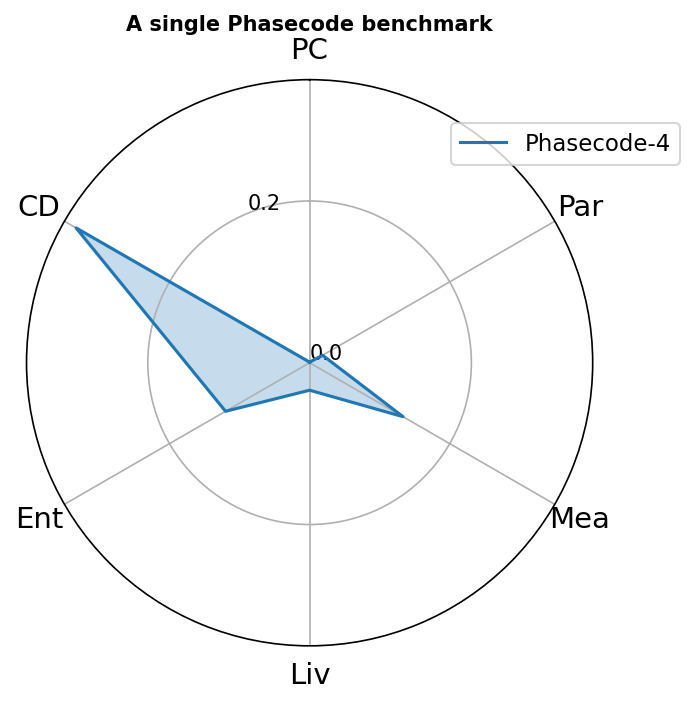

Executing BitCode with 5 qubits.....
********** Executing on ibm_brisbane backend*****************
Score :  0.0
Creation, execution and Quantum Times = 0.0016951560974121094,10.917088508605957 & 3 seconds


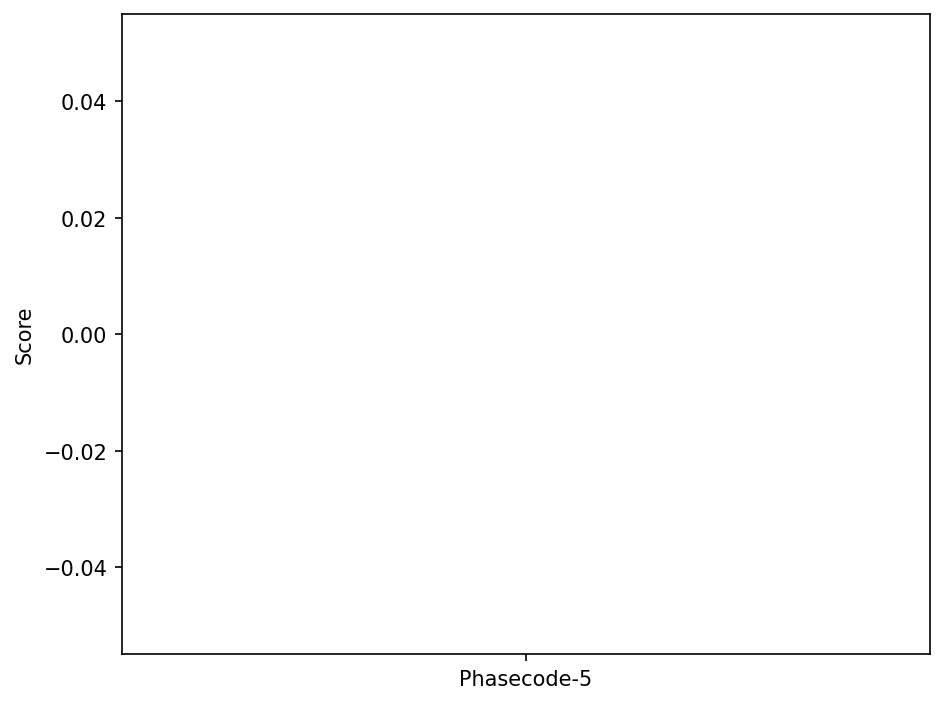

Features : [0.000999875015623047, 0.25, 0.12903225806451613, 0.04566929133858268, 0.21428571428571427, 0.0272108843537415]


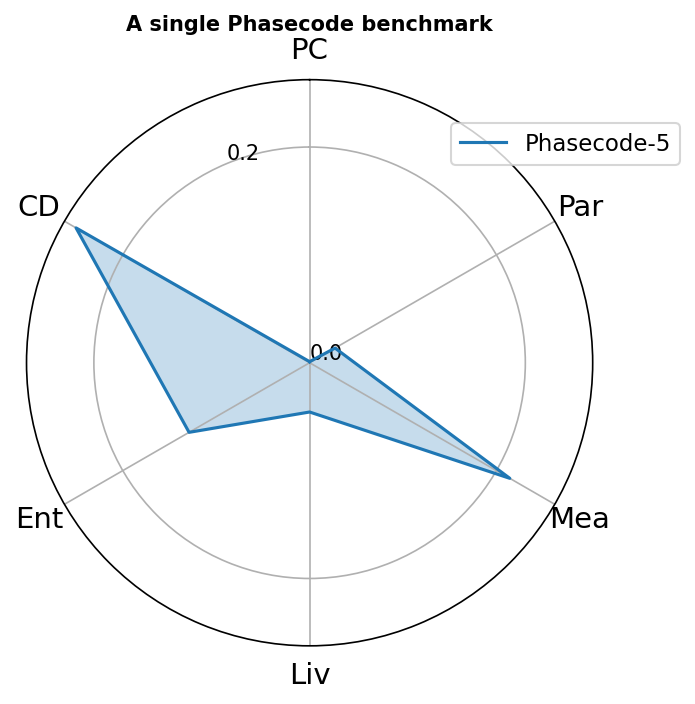

Executing BitCode with 6 qubits.....
********** Executing on ibm_brisbane backend*****************
Score :  0.0
Creation, execution and Quantum Times = 0.0019545555114746094,9.059072732925415 & 2 seconds


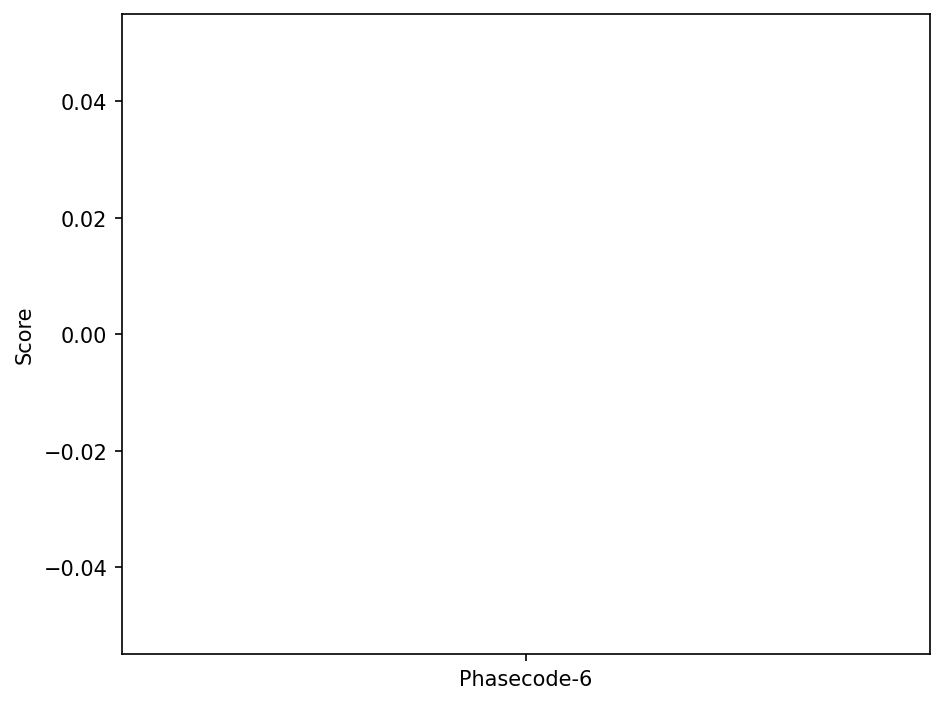

Features : [0.001249843769528809, 0.2, 0.11764705882352941, 0.05708661417322835, 0.2, 0.03703703703703704]


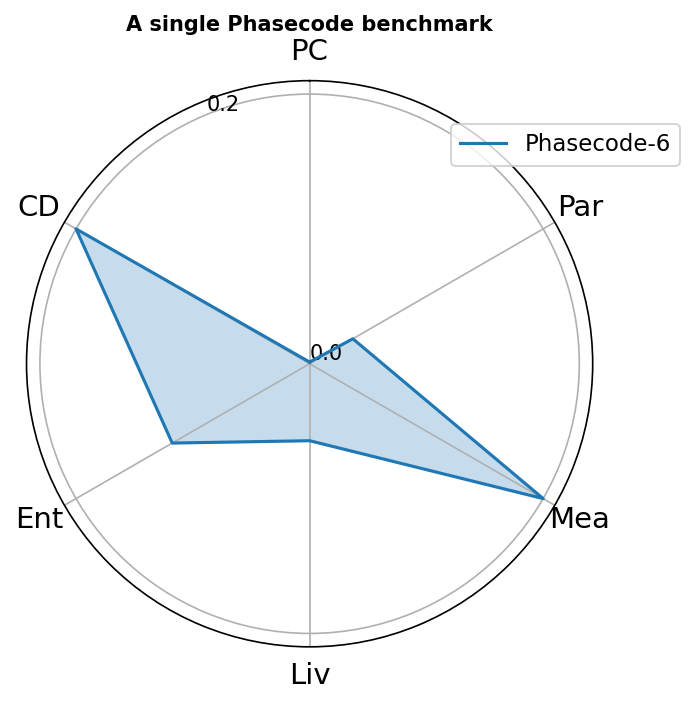

Executing BitCode with 7 qubits.....
********** Executing on ibm_brisbane backend*****************
Score :  0.0
Creation, execution and Quantum Times = 0.0022873878479003906,9.363369464874268 & 2 seconds


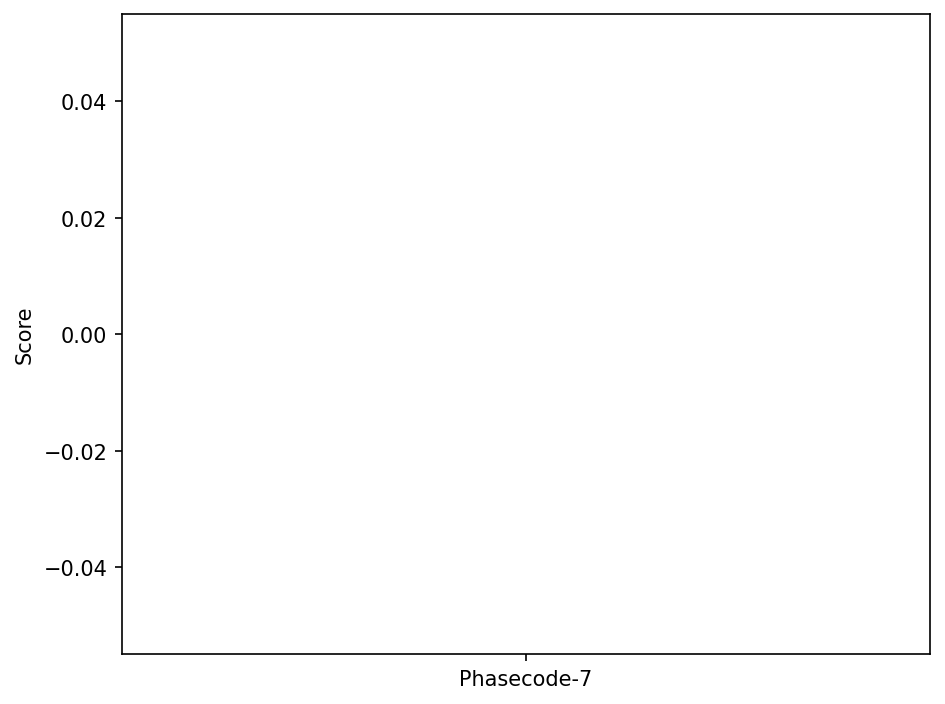

Features : [0.0014998125234345708, 0.16666666666666666, 0.12121212121212122, 0.06692913385826772, 0.2, 0.04444444444444444]


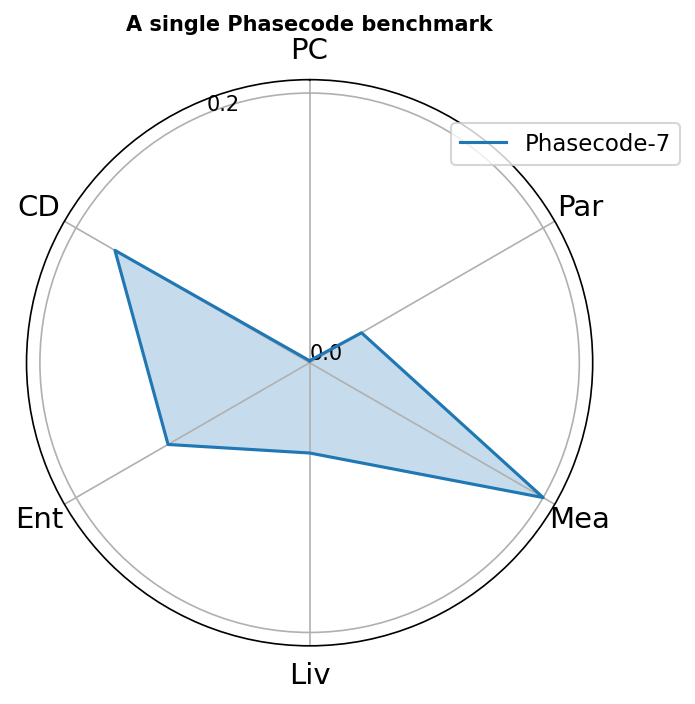

Executing BitCode with 8 qubits.....
********** Executing on ibm_brisbane backend*****************
Score :  0.0
Creation, execution and Quantum Times = 0.002569913864135742,10.514259576797485 & 2 seconds


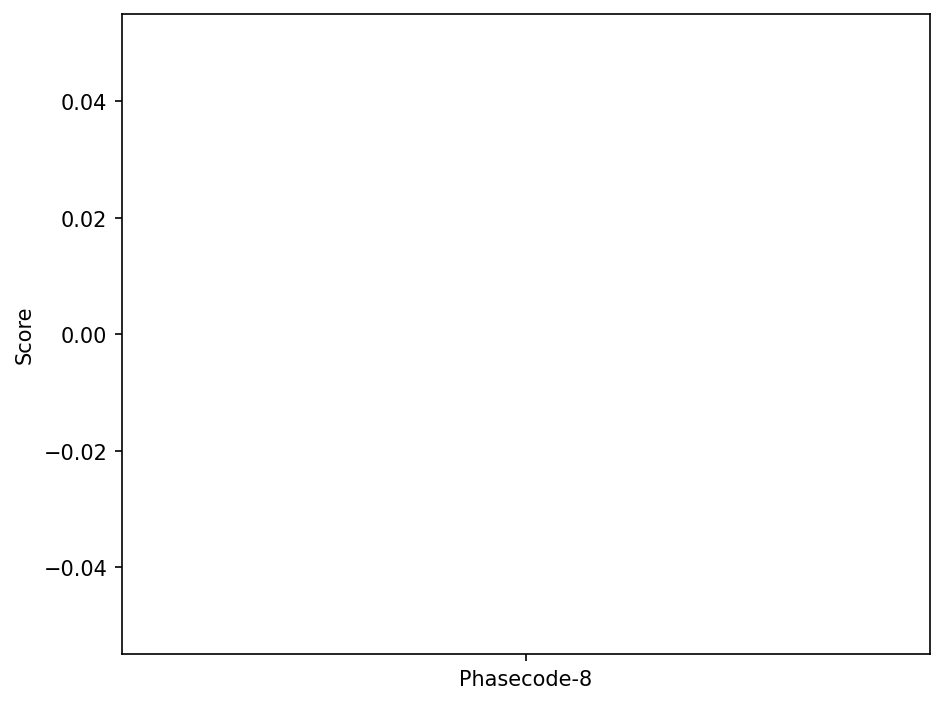

Features : [0.0017497812773403325, 0.14285714285714285, 0.125, 0.07627952755905512, 0.2, 0.051322751322751325]


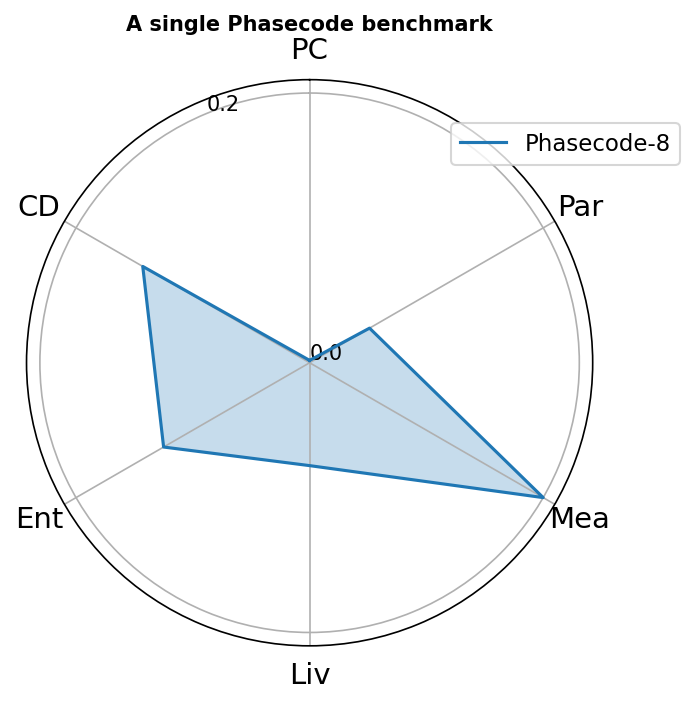

Executing BitCode with 9 qubits.....
********** Executing on ibm_brisbane backend*****************
Score :  0.0
Creation, execution and Quantum Times = 0.002681732177734375,9.190760612487793 & 2 seconds


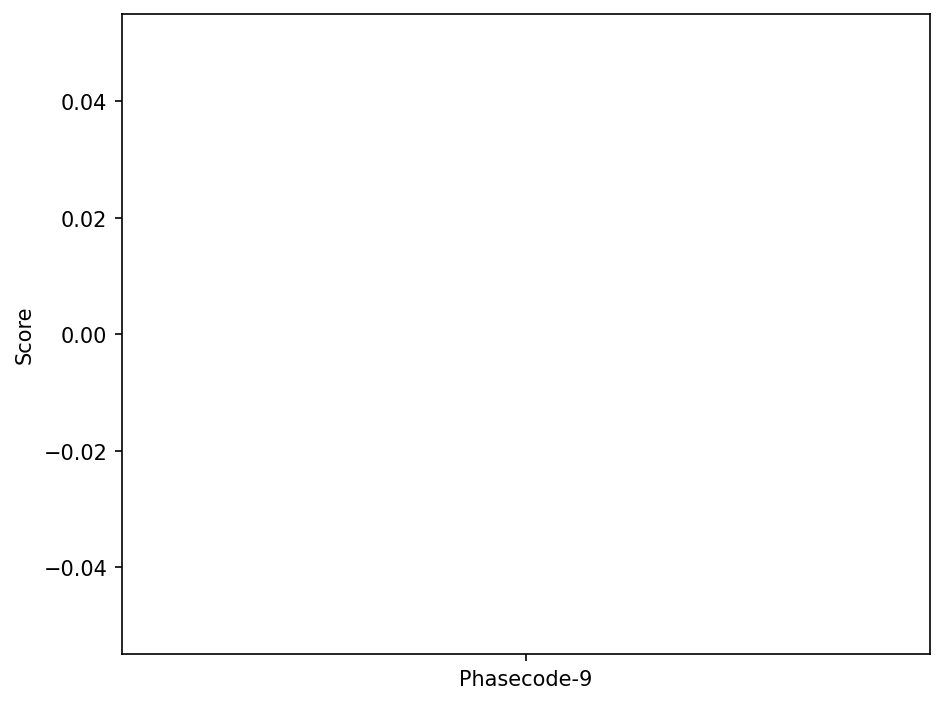

Features : [0.001999750031246094, 0.125, 0.12030075187969924, 0.08956692913385826, 0.2, 0.06243386243386244]


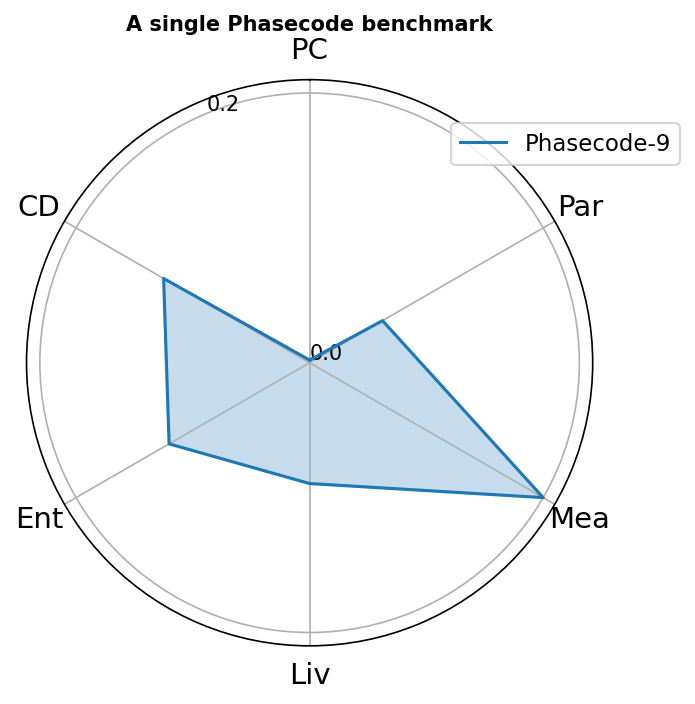

Executing BitCode with 10 qubits.....
********** Executing on ibm_brisbane backend*****************
Score :  0.0
Creation, execution and Quantum Times = 0.0030999183654785156,151.4164924621582 & 3 seconds


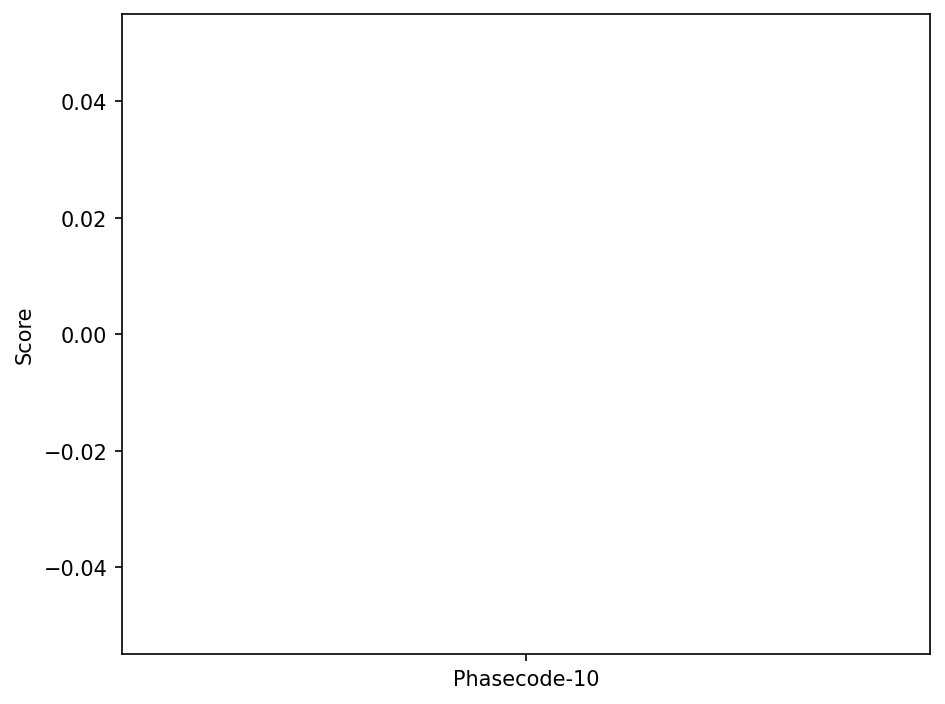

Features : [0.0022497187851518562, 0.1111111111111111, 0.11920529801324503, 0.10137795275590551, 0.2, 0.07195767195767196]


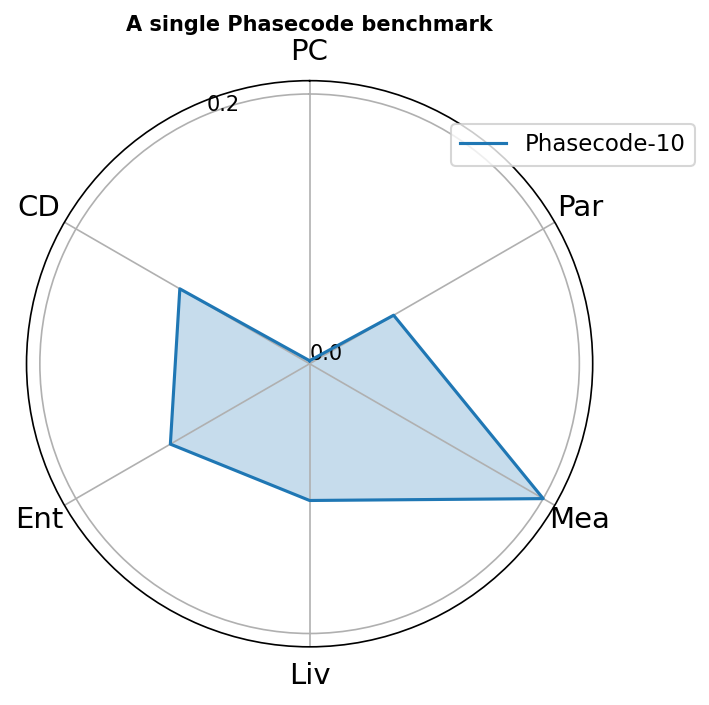

Executing BitCode with 11 qubits.....
********** Executing on ibm_brisbane backend*****************
Score :  0.0
Creation, execution and Quantum Times = 0.0032739639282226562,10.059121131896973 & 2 seconds


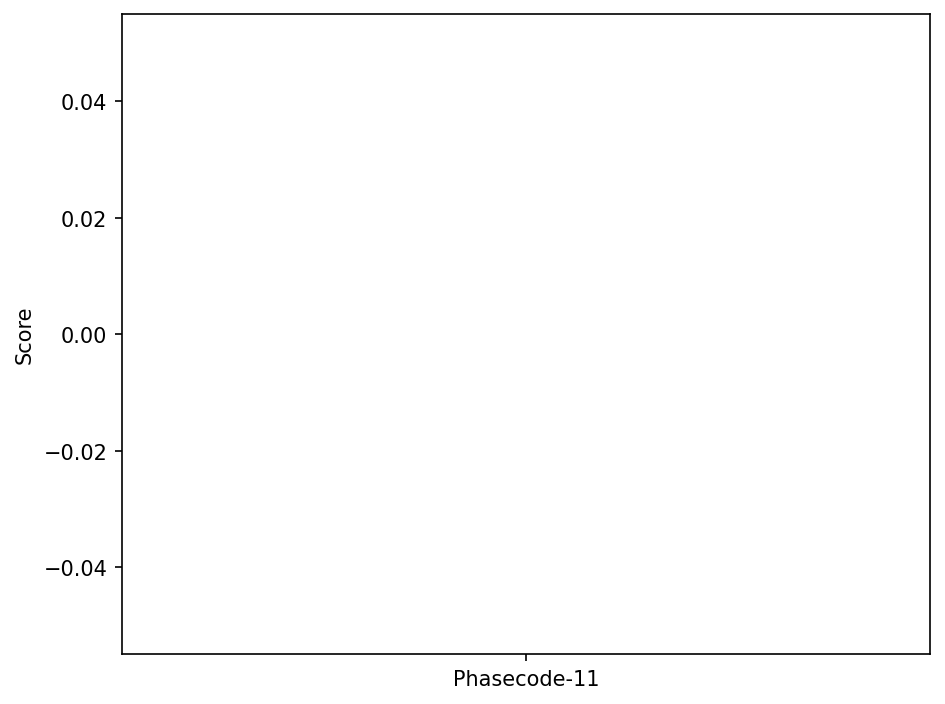

Features : [0.002499687539057618, 0.1, 0.11363636363636363, 0.11663385826771654, 0.2, 0.08518518518518518]


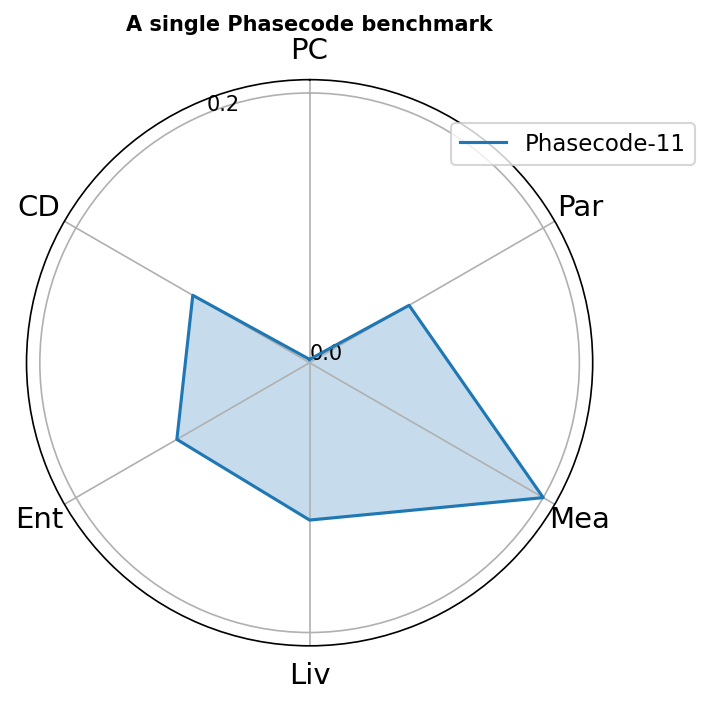

Executing BitCode with 12 qubits.....
********** Executing on ibm_brisbane backend*****************
Score :  0.0
Creation, execution and Quantum Times = 0.004772663116455078,9.990310907363892 & 2 seconds


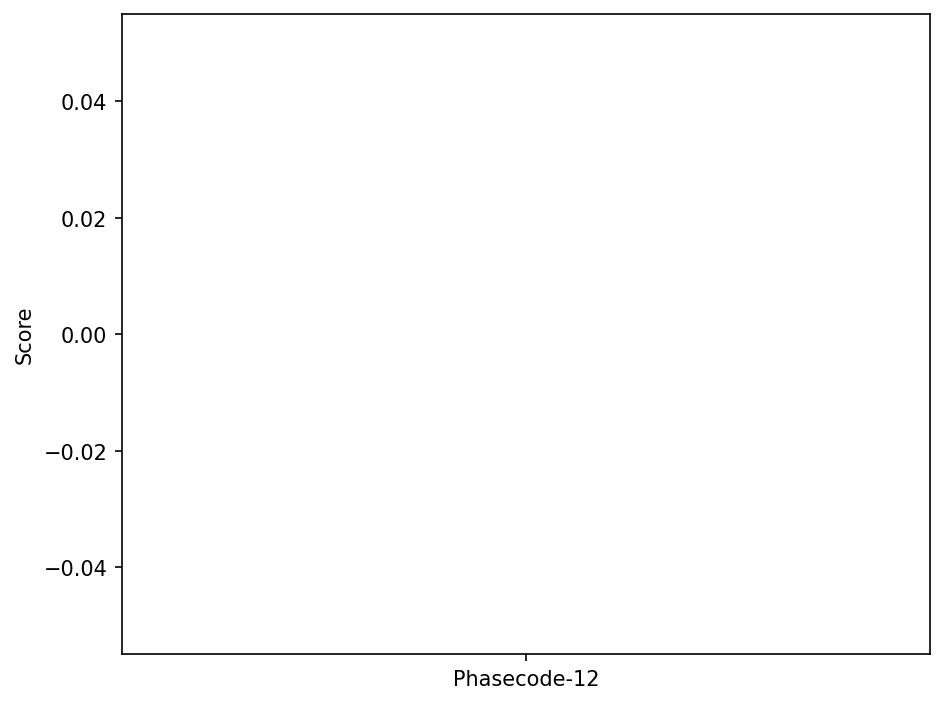

Features : [0.0027496562929633797, 0.09090909090909091, 0.12154696132596685, 0.1220472440944882, 0.2, 0.08783068783068783]


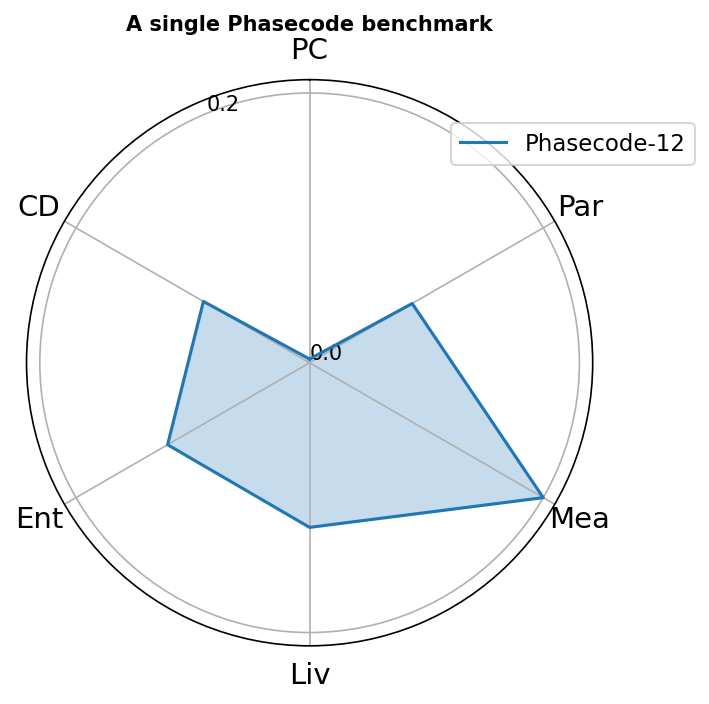

Executing BitCode with 13 qubits.....
********** Executing on ibm_brisbane backend*****************
Score :  0.0
Creation, execution and Quantum Times = 0.0036542415618896484,9.837130308151245 & 2 seconds


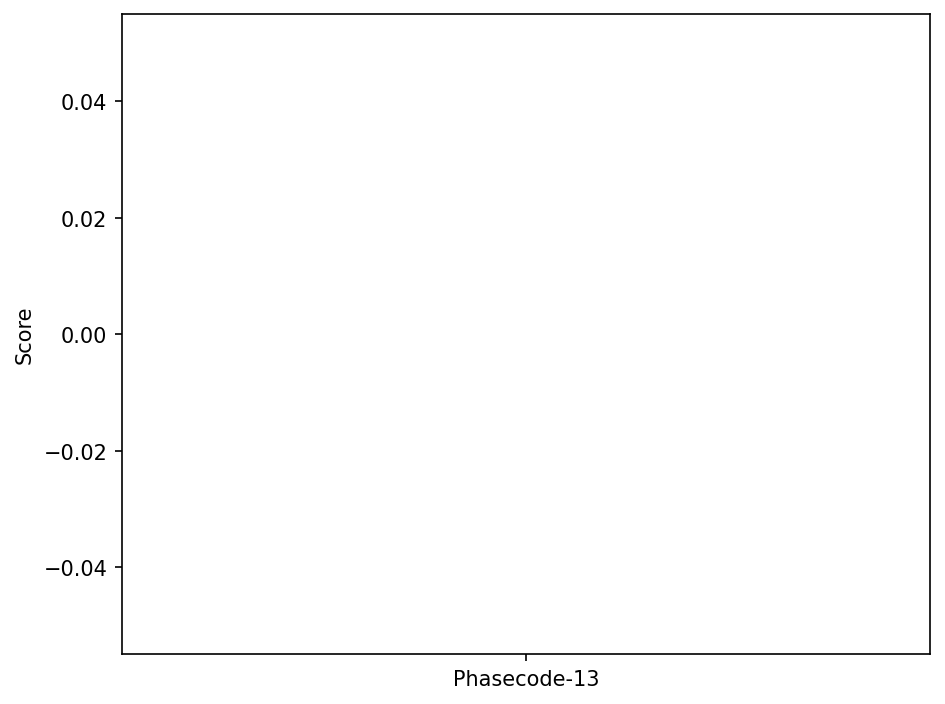

Features : [0.0029996250468691415, 0.08333333333333333, 0.11594202898550725, 0.1377952755905512, 0.26666666666666666, 0.10158730158730159]


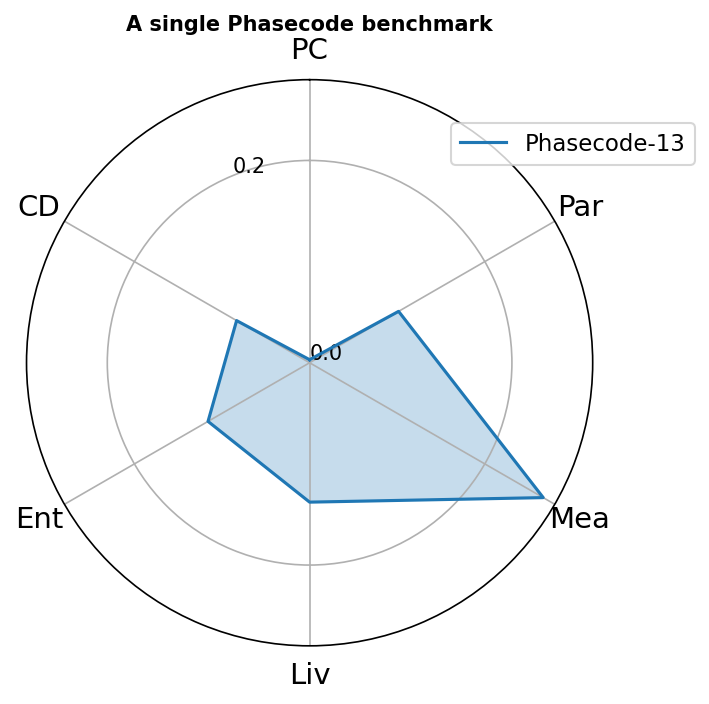

Executing BitCode with 14 qubits.....
********** Executing on ibm_brisbane backend*****************
Score :  0.0
Creation, execution and Quantum Times = 0.003906726837158203,9.84219479560852 & 3 seconds


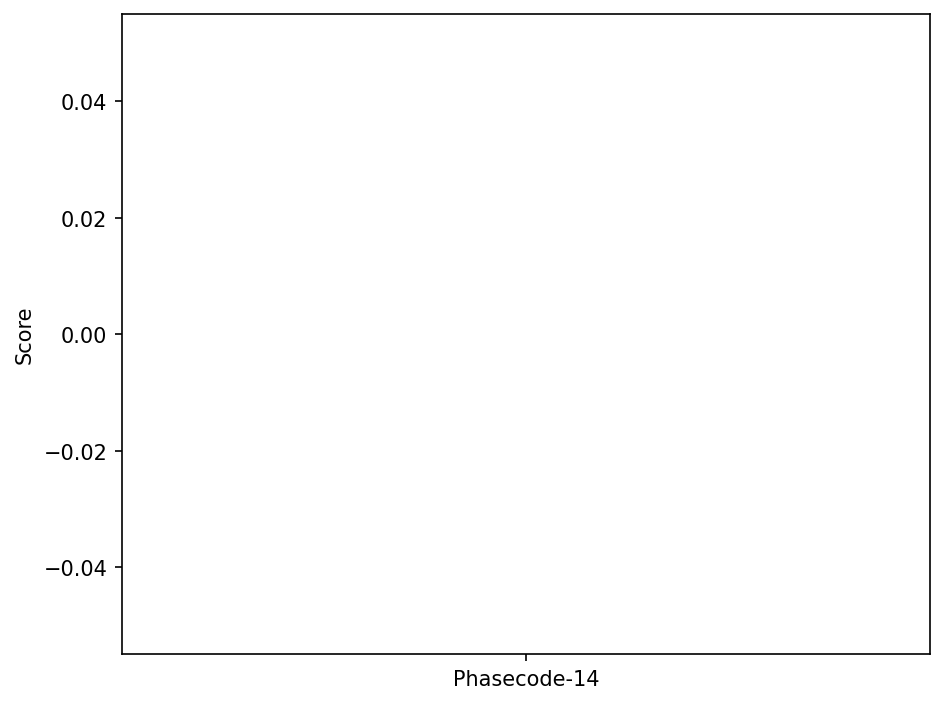

Features : [0.0032495938007749033, 0.07692307692307693, 0.11818181818181818, 0.14714566929133857, 0.2, 0.10846560846560846]


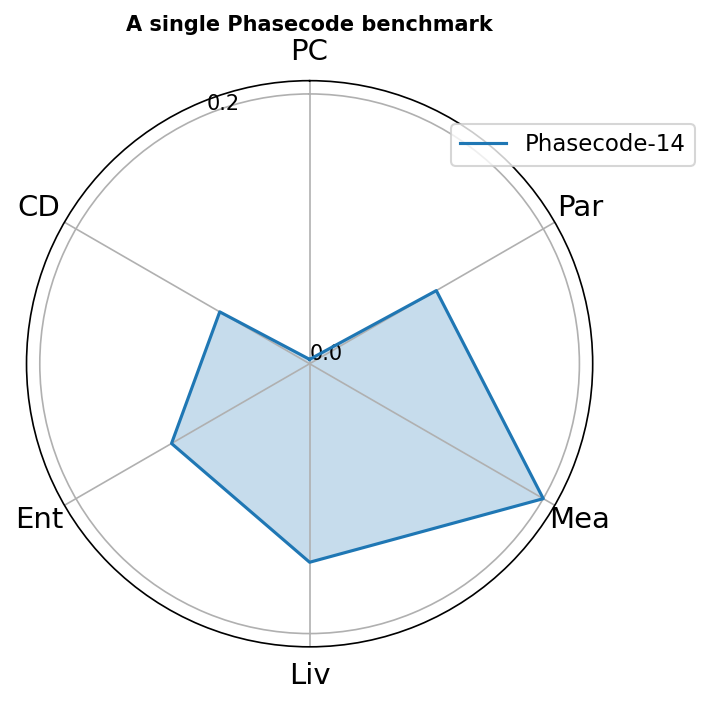

Executing BitCode with 15 qubits.....
********** Executing on ibm_brisbane backend*****************
Score :  0.0
Creation, execution and Quantum Times = 0.0043871402740478516,9.900495290756226 & 3 seconds


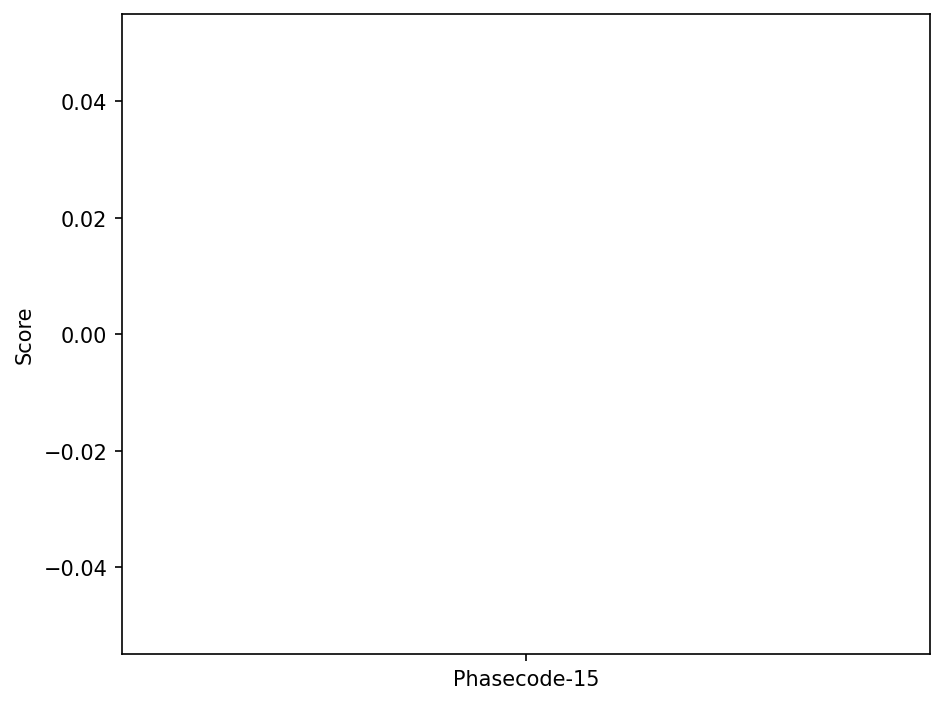

Features : [0.003499562554680665, 0.07142857142857142, 0.11666666666666667, 0.15994094488188976, 0.2, 0.11904761904761904]


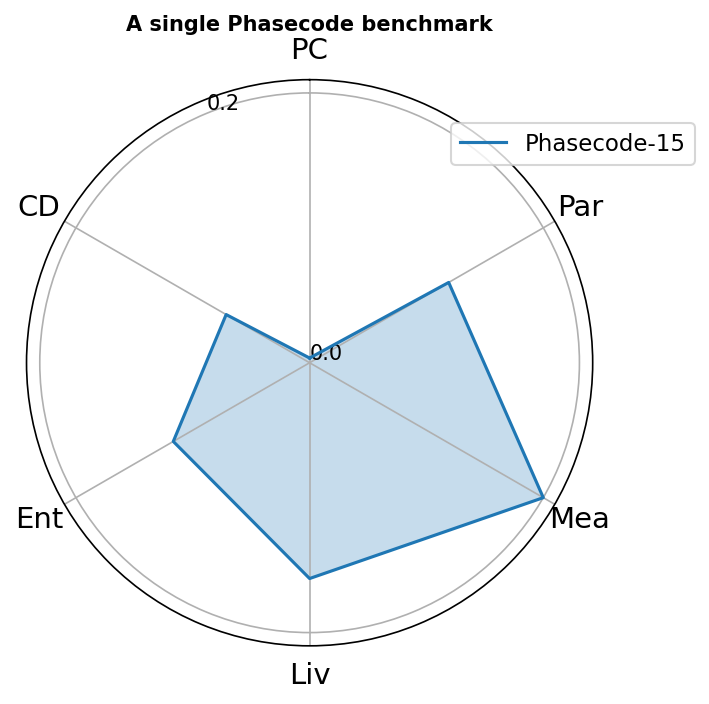

Executing BitCode with 16 qubits.....
********** Executing on ibm_brisbane backend*****************
Score :  0.0
Creation, execution and Quantum Times = 0.00458979606628418,10.087230920791626 & 3 seconds


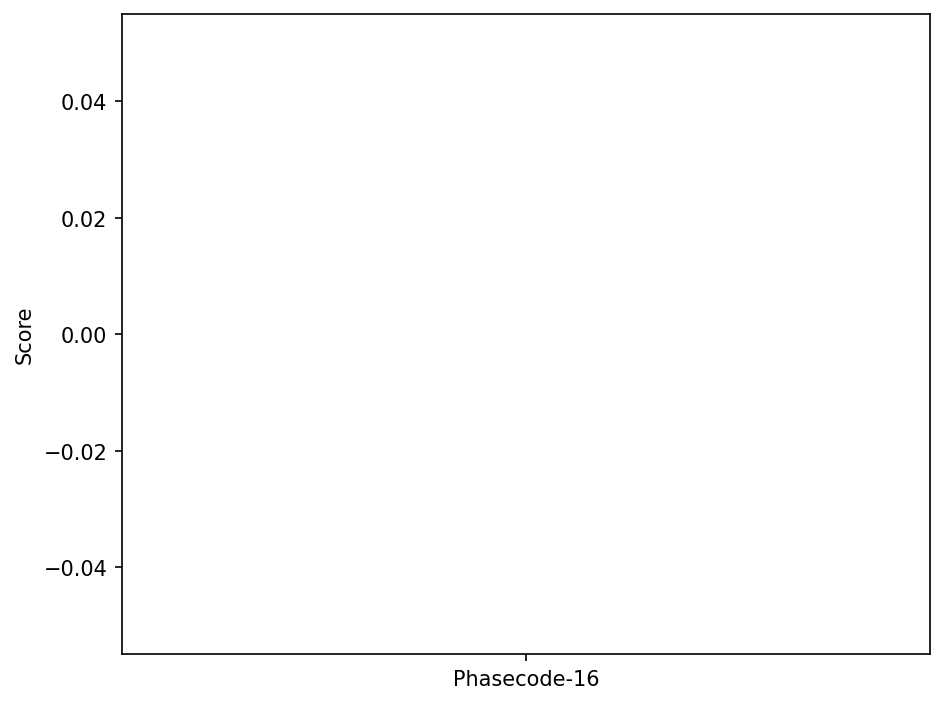

Features : [0.0037495313085864268, 0.06666666666666667, 0.11583011583011583, 0.17224409448818898, 0.3333333333333333, 0.1291005291005291]


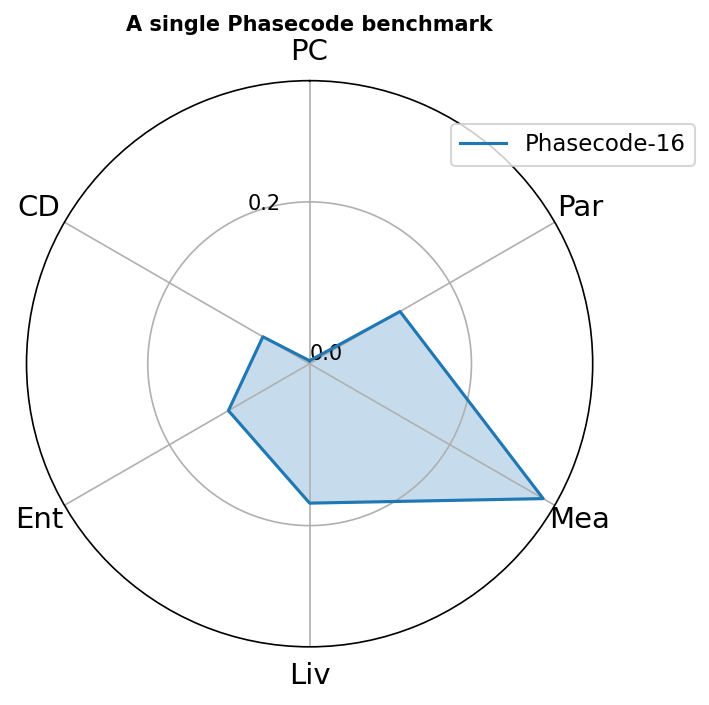

Executing BitCode with 17 qubits.....
********** Executing on ibm_brisbane backend*****************
Score :  0.0
Creation, execution and Quantum Times = 0.004593372344970703,9.77289080619812 & 3 seconds


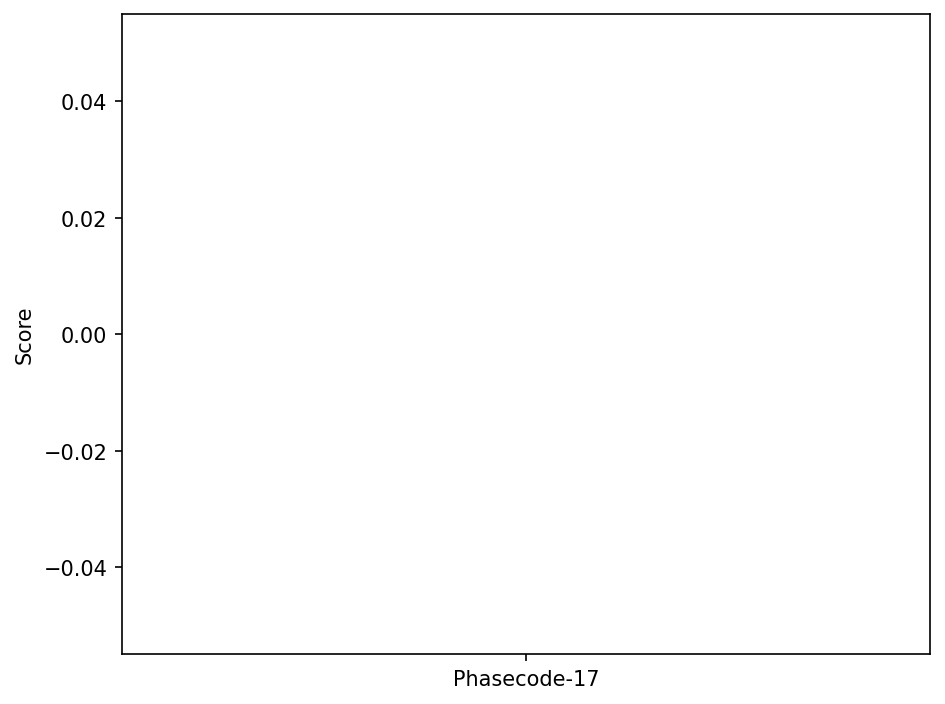

Features : [0.003999500062492188, 0.0625, 0.11636363636363636, 0.1830708661417323, 0.26666666666666666, 0.13756613756613756]


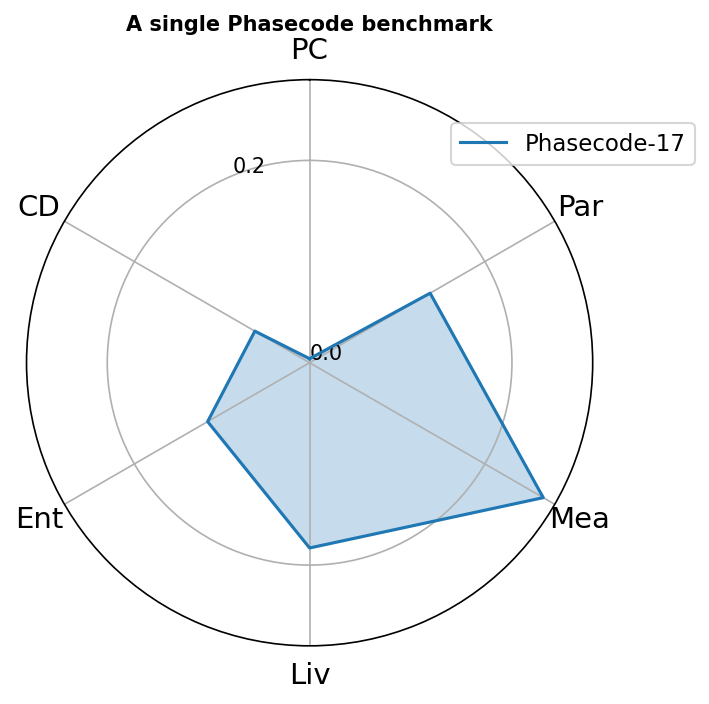

Executing BitCode with 18 qubits.....
********** Executing on ibm_brisbane backend*****************
Score :  0.0
Creation, execution and Quantum Times = 0.0050089359283447266,10.394179344177246 & 3 seconds


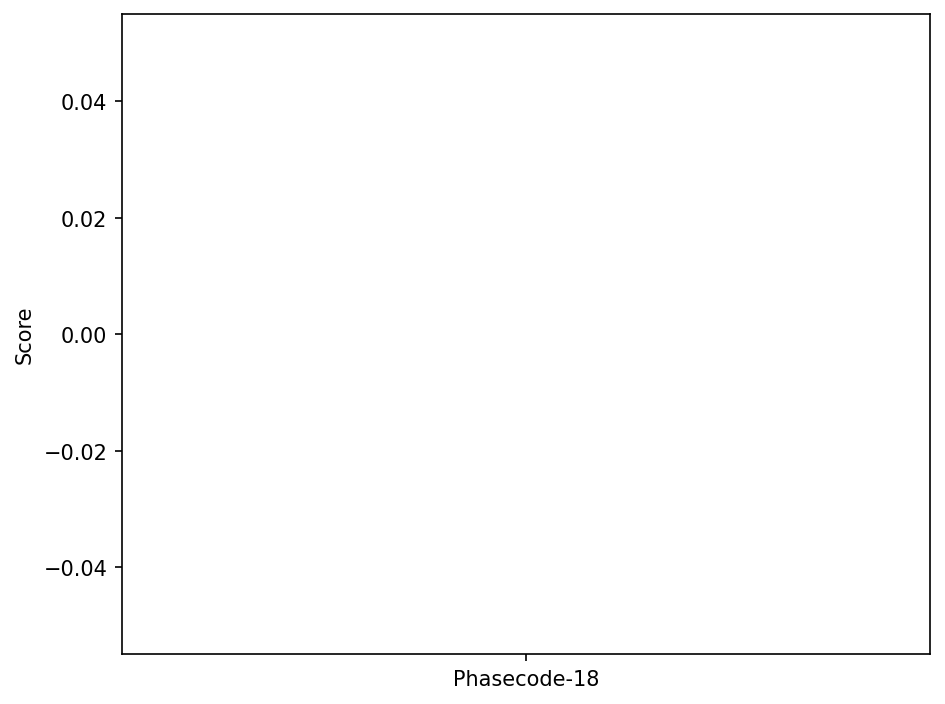

Features : [0.00424946881639795, 0.058823529411764705, 0.11643835616438356, 0.19438976377952755, 0.3333333333333333, 0.14656084656084656]


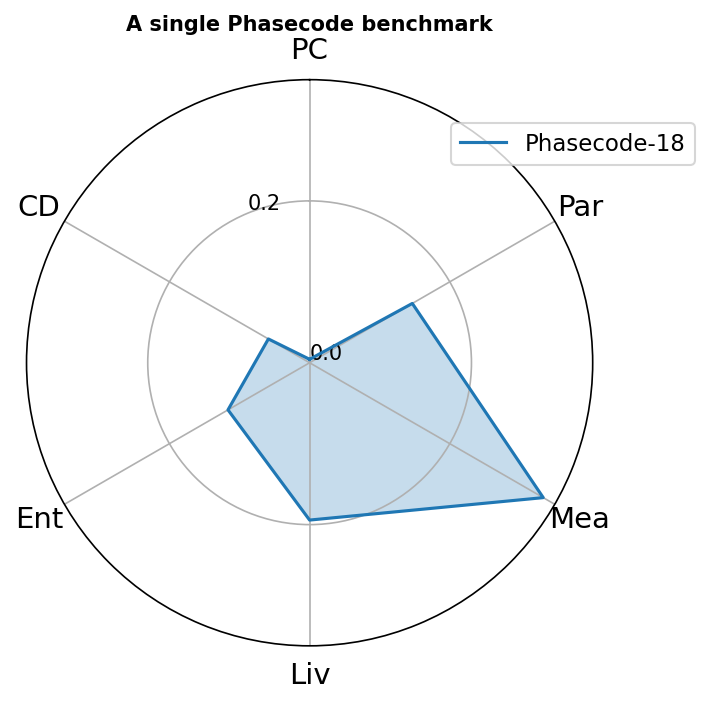

Executing BitCode with 19 qubits.....
********** Executing on ibm_brisbane backend*****************
Score :  0.0
Creation, execution and Quantum Times = 0.005099296569824219,10.924330949783325 & 3 seconds


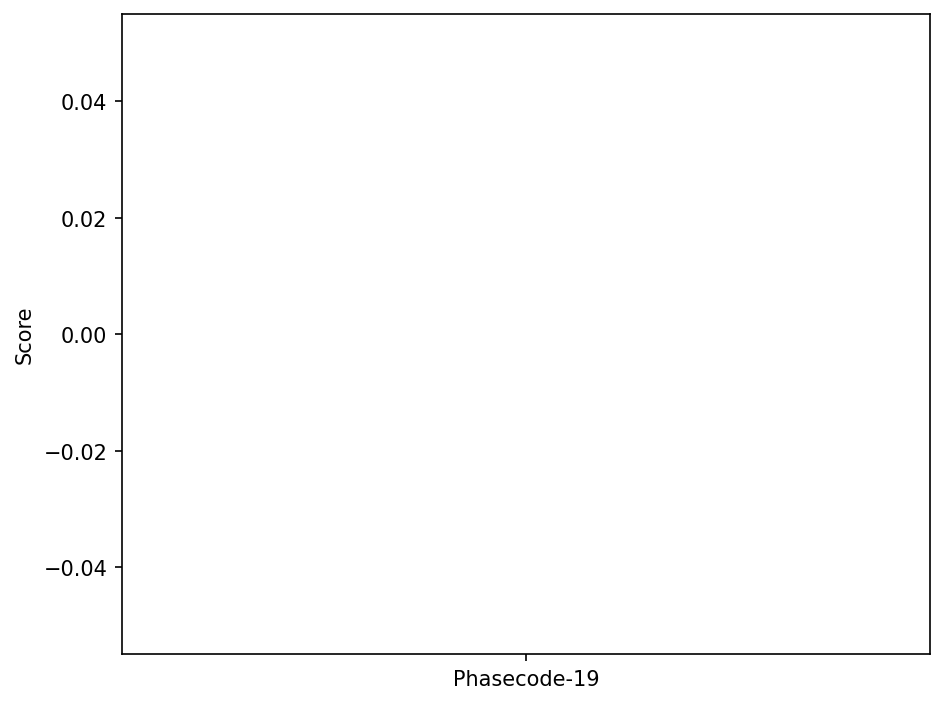

Features : [0.0044994375703037125, 0.05555555555555555, 0.11688311688311688, 0.20521653543307086, 0.3333333333333333, 0.15502645502645504]


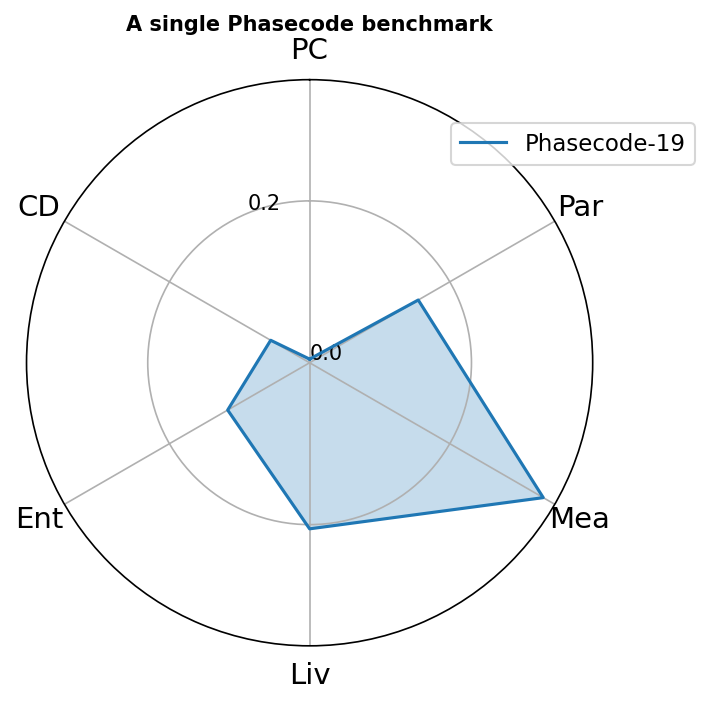

Executing BitCode with 20 qubits.....
********** Executing on ibm_brisbane backend*****************
Score :  1.9721522630525295e-31
Creation, execution and Quantum Times = 0.005357503890991211,10.863133907318115 & 3 seconds


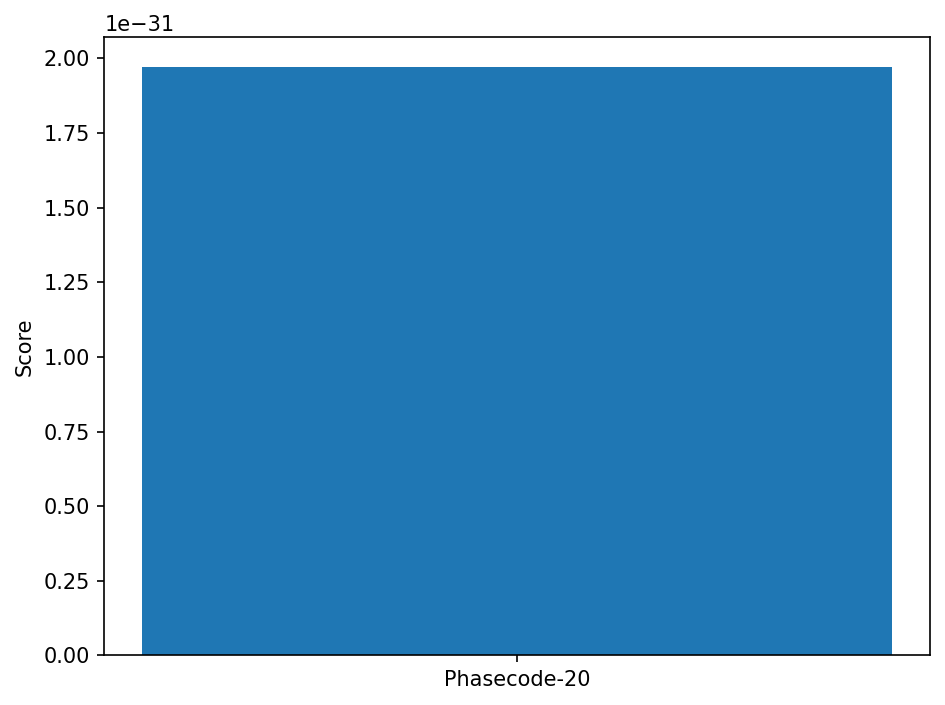

Features : [0.004749406324209474, 0.05263157894736842, 0.1165644171779141, 0.2170275590551181, 0.2, 0.16455026455026456]


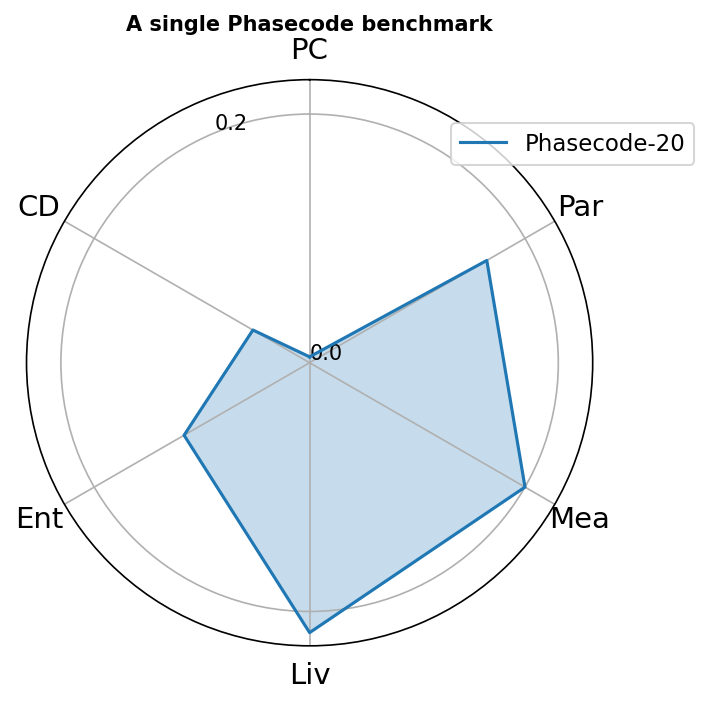

In [6]:
# # Only cirq circuit implementation is given


# # num_data_qubits = 3
# # num_rounds = 1
# # phase_state = [1, 1, 1]

# qubits = 3

# pc = PhaseCode(3, 1, [1, 1, 1])
# pc_ckt = bc.circuit()
# #only Cirq's implementation for ckt creation
# pc_ckt = cirq_to_qiskit(pc_ckt)
# print(pc_ckt)

# job = execute(pc_ckt, backend, shots=shots, **options)
# counts = job.result().results[0].data.partial_probability
# for key in counts.keys():
#     counts[key] = int(counts[key] * shots)
    
# print("counts : ",counts)
# score = pc.score(counts)
# print("Score : ",score)

# name = "Bitcode"

# benchmark_name = f"{name}-{qubits}"
# plot_results([score],[benchmark_name])

# features = [
# compute_communication_with_qiskit(pc_ckt),
# compute_depth_with_qiskit(pc_ckt),
# compute_entanglement_with_qiskit(pc_ckt),
# compute_liveness_with_qiskit(pc_ckt),
# compute_measurement_with_qiskit(pc_ckt),
# compute_parallelism_with_qiskit(pc_ckt),
# ]
# print("Features :",features)

# plot_benchmark(title=f"A single {name} benchmark",labels=[benchmark_name],features=[features],
#                    spoke_labels=["PC", "CD", "Ent", "Liv", "Mea", "Par"] )

# '''
#     Args:
#         num_data: The number of data qubits.
#         num_rounds: The number of measurement rounds.
#         bit_state: A list denoting the state to initialize each data qubit to.

#     Returns:
#         A `cirq.Circuit` for the bit-flip error correcting code.
# '''

# num_data_qubits = 3
# num_rounds = 1
# bit_state = [1, 1, 1]

def pc(q):
    print(f"Executing BitCode with {q} qubits.....")
    shots = 1000
    name = "Phasecode"
    t_c = time.time()
    qubits = q
    
    pc = PhaseCode(q,1,[1]*q)
    pc_ckt = pc.circuit()
    #only Cirq's implementation for ckt creation
    qc = cirq_to_qiskit(pc_ckt)
    creation_time = time.time()-t_c  #in sec
    
    print(f"********** Executing on {backend.name} backend*****************")
    
    qc = transpile(qc, backend=backend, optimization_level=2)

    # Calculate Execution time 
    t_e = time.time()
    job = sampler.run([qc], shots=shots)
    result = job.result()
    execution_time = time.time() - t_e #in sec
    #print(result)
    
    # Calculate quantum processing time 
    quantum_time = (job.usage()) #in sec

    #finding creg
    reg = qc.cregs[0].name

    counts = result[0].data[reg].get_counts()
    #print("counts : ",counts)
    
    score = pc.score(counts)
    print("Score : ",score)
    #device_scores.append(score)
    print(f"Creation, execution and Quantum Times = {creation_time},{execution_time} & {quantum_time} seconds")

    benchmark_name = f"{name}-{qubits}"
    plot_results([score],[benchmark_name])

    features = [
    compute_communication_with_qiskit(qc),
    compute_depth_with_qiskit(qc),
    compute_entanglement_with_qiskit(qc),
    compute_liveness_with_qiskit(qc),
    compute_measurement_with_qiskit(qc),
    compute_parallelism_with_qiskit(qc),
    ]

    label = str(name)+"_"+str(qubits)
    
    Features[label] = features
    print("Features :",features)

    plot_benchmark(title=f"A single {name} benchmark",labels=[benchmark_name],features=[features],
                   spoke_labels=["PC", "CD", "Ent", "Liv", "Mea", "Par"] )


if __name__=="__main__":
    for i in range(3,21):
        pc(i)

# VQE-Proxy

********** Executing on ibm_brisbane backend*****************
 For circuit i=       ┌────────────┐┌────────────┐     ┌──────────┐┌────────────┐»
 q_0: ─┤ Ry(6.8831) ├┤ Rz(6.7823) ├──■──┤ Ry(5.74) ├┤ Rz(9.2327) ├»
       ├────────────┤├────────────┤┌─┴─┐└──────────┘├────────────┤»
 q_1: ─┤ Ry(2.6142) ├┤ Rz(2.7451) ├┤ X ├─────■──────┤ Ry(2.8293) ├»
      ┌┴────────────┤├────────────┤└───┘   ┌─┴─┐    ├────────────┤»
 q_2: ┤ Ry(0.77462) ├┤ Rz(3.1946) ├────────┤ X ├────┤ Ry(3.0195) ├»
      └─────────────┘└────────────┘        └───┘    └────────────┘»
m0: 3/════════════════════════════════════════════════════════════»
                                                                  »
«                       ┌─┐      
« q_0: ─────────────────┤M├──────
«        ┌───────────┐  └╥┘┌─┐   
« q_1: ──┤ Rz(9.211) ├───╫─┤M├───
«      ┌─┴───────────┴─┐ ║ └╥┘┌─┐
« q_2: ┤ Rz(-0.050808) ├─╫──╫─┤M├
«      └───────────────┘ ║  ║ └╥┘
«m0: 3/══════════════════╩══╩══╩═
«                        0  1  2 , exec

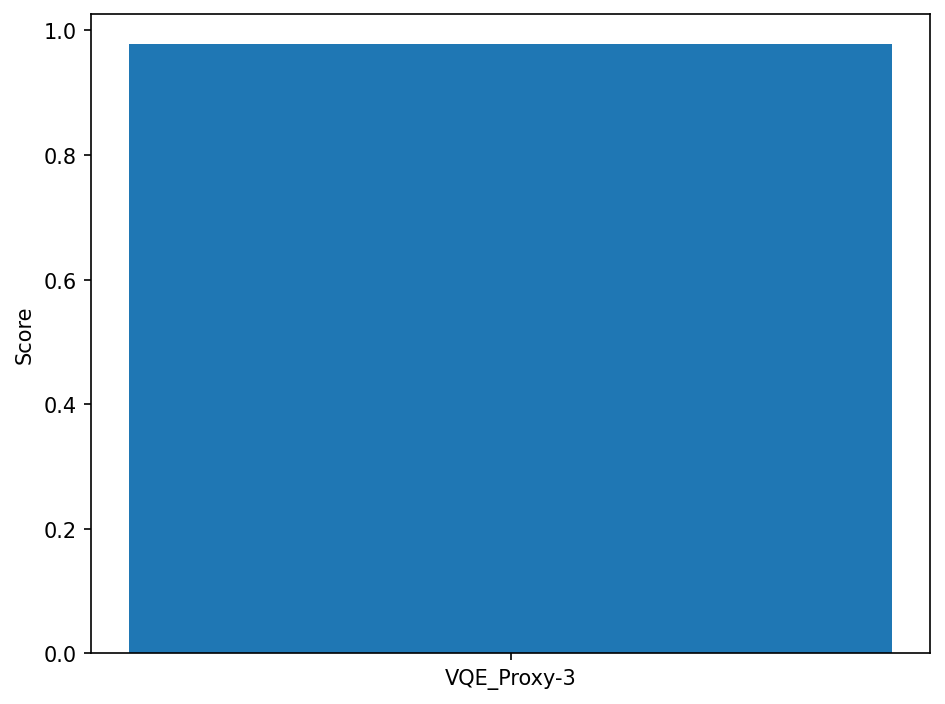

########################################################
********** Executing on ibm_brisbane backend*****************
 For circuit i=      ┌────────────┐┌────────────┐     ┌────────────┐┌────────────┐»
 q_0: ┤ Ry(6.2721) ├┤ Rz(13.074) ├──■──┤ Ry(9.9609) ├┤ Rz(3.1444) ├»
      ├────────────┤├────────────┤┌─┴─┐└────────────┘├───────────┬┘»
 q_1: ┤ Ry(3.0172) ├┤ Rz(10.276) ├┤ X ├──────■───────┤ Ry(6.841) ├─»
      ├────────────┤├────────────┤└───┘    ┌─┴─┐     └───────────┘ »
 q_2: ┤ Ry(6.7362) ├┤ Rz(4.8762) ├─────────┤ X ├───────────■───────»
      ├────────────┤├────────────┤         └───┘         ┌─┴─┐     »
 q_3: ┤ Ry(4.9618) ├┤ Rz(3.0184) ├───────────────────────┤ X ├─────»
      └────────────┘└────────────┘                       └───┘     »
m0: 4/═════════════════════════════════════════════════════════════»
                                                                   »
«                    ┌─┐                       
« q_0: ──────────────┤M├───────────────────────
«      ┌───

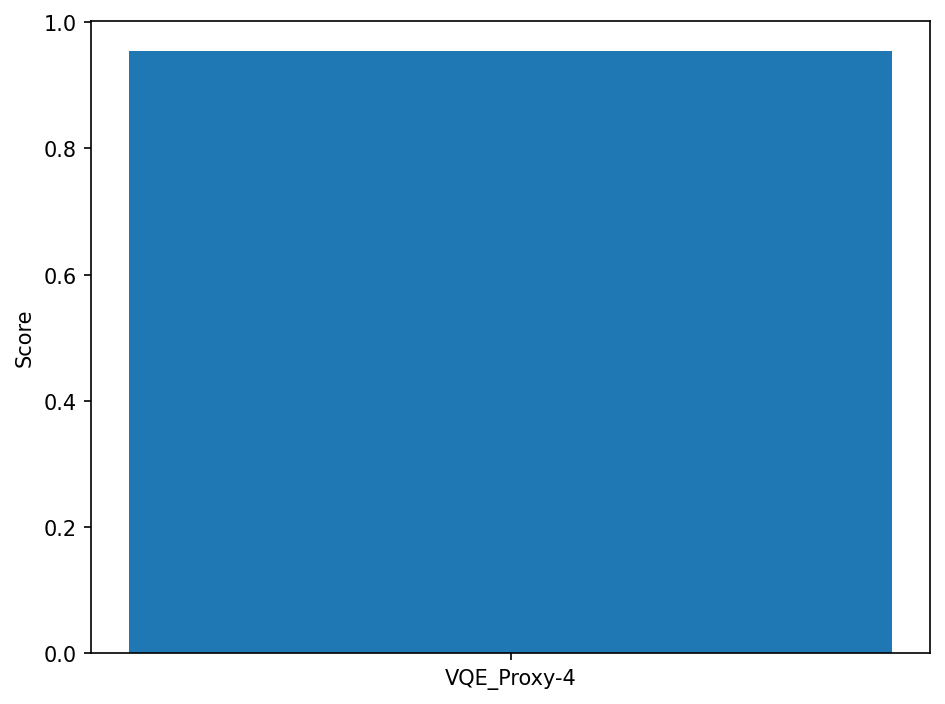

########################################################
********** Executing on ibm_brisbane backend*****************
 For circuit i=        ┌────────────┐ ┌────────────┐     ┌────────────┐┌────────────┐»
 q_0: ──┤ Ry(9.4225) ├─┤ Rz(3.6763) ├──■──┤ Ry(8.8999) ├┤ Rz(3.1492) ├»
        ├────────────┤ ├───────────┬┘┌─┴─┐└────────────┘├───────────┬┘»
 q_1: ──┤ Ry(6.2814) ├─┤ Rz(10.36) ├─┤ X ├──────■───────┤ Ry(3.665) ├─»
      ┌─┴────────────┴┐├───────────┴┐└───┘    ┌─┴─┐     └───────────┘ »
 q_2: ┤ Ry(-0.059329) ├┤ Rz(2.2638) ├─────────┤ X ├───────────■───────»
      └─┬────────────┬┘├────────────┤         └───┘         ┌─┴─┐     »
 q_3: ──┤ Ry(6.2011) ├─┤ Rz(10.403) ├───────────────────────┤ X ├─────»
        ├────────────┤ ├────────────┤                       └───┘     »
 q_4: ──┤ Ry(1.9191) ├─┤ Rz(12.823) ├─────────────────────────────────»
        └────────────┘ └────────────┘                                 »
m0: 5/════════════════════════════════════════════════════════════════»
  

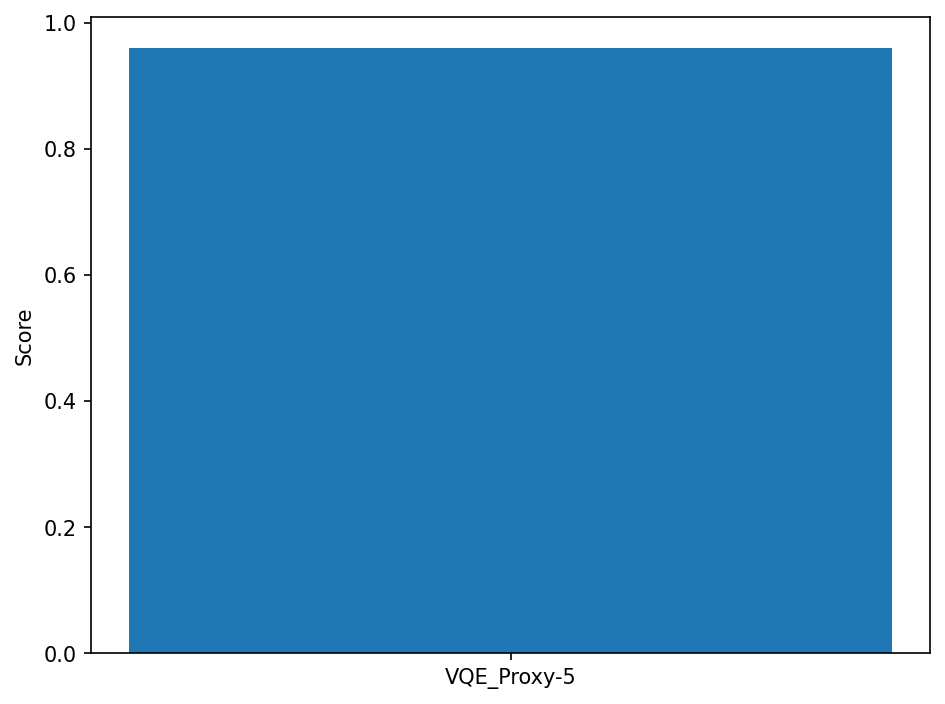

########################################################
********** Executing on ibm_brisbane backend*****************
 For circuit i=       ┌────────────┐ ┌────────────┐     ┌────────────┐┌────────────────┐»
 q_0: ─┤ Ry(3.1401) ├─┤ Rz(6.4723) ├──■──┤ Ry(12.038) ├┤ Rz(0.00089258) ├»
       ├────────────┤ ├────────────┤┌─┴─┐└────────────┘└─┬────────────┬─┘»
 q_1: ─┤ Ry(3.1388) ├─┤ Rz(9.4405) ├┤ X ├──────■─────────┤ Ry(8.8965) ├──»
       ├────────────┤ ├────────────┤└───┘    ┌─┴─┐       └────────────┘  »
 q_2: ─┤ Ry(6.3209) ├─┤ Rz(9.8276) ├─────────┤ X ├─────────────■─────────»
      ┌┴────────────┴┐├───────────┬┘         └───┘           ┌─┴─┐       »
 q_3: ┤ Ry(-0.13264) ├┤ Rz(2.417) ├──────────────────────────┤ X ├───────»
      └┬───────────┬─┘├───────────┴┐                         └───┘       »
 q_4: ─┤ Ry(2.292) ├──┤ Rz(11.767) ├─────────────────────────────────────»
       ├───────────┴┐ ├────────────┤                                     »
 q_5: ─┤ Ry(7.9231) ├─┤ Rz(6.4171) ├─────

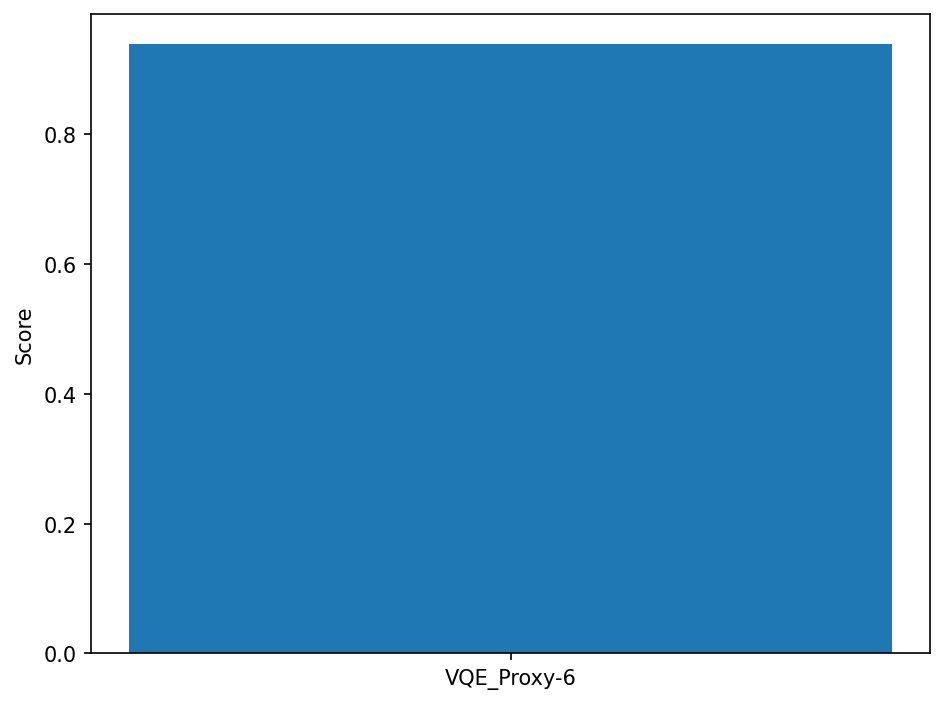

########################################################
********** Executing on ibm_brisbane backend*****************
 For circuit i=       ┌────────────┐ ┌────────────┐     ┌────────────┐┌────────────┐»
 q_0: ─┤ Ry(6.2822) ├─┤ Rz(3.3526) ├──■──┤ Ry(5.7522) ├┤ Rz(9.4271) ├»
       ├────────────┤ ├────────────┤┌─┴─┐└────────────┘├────────────┤»
 q_1: ─┤ Ry(3.1434) ├─┤ Rz(6.0468) ├┤ X ├──────■───────┤ Ry(9.9497) ├»
       ├────────────┤ ├────────────┤└───┘    ┌─┴─┐     └────────────┘»
 q_2: ─┤ Ry(6.2927) ├─┤ Rz(6.6544) ├─────────┤ X ├───────────■───────»
       ├────────────┤ ├────────────┤         └───┘         ┌─┴─┐     »
 q_3: ─┤ Ry(3.1551) ├─┤ Rz(10.422) ├───────────────────────┤ X ├─────»
       ├────────────┤ ├────────────┤                       └───┘     »
 q_4: ─┤ Ry(12.459) ├─┤ Rz(3.0603) ├─────────────────────────────────»
      ┌┴────────────┤ ├────────────┤                                 »
 q_5: ┤ Ry(0.24415) ├─┤ Rz(11.249) ├─────────────────────────────────»
      └┬──────

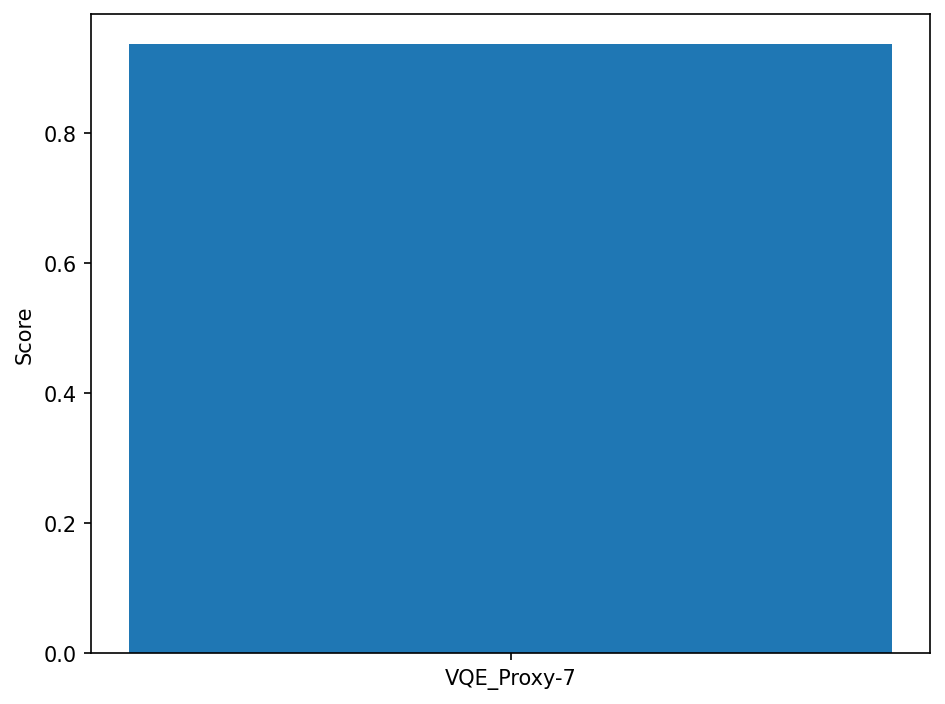

########################################################
********** Executing on ibm_brisbane backend*****************
 For circuit i=      ┌────────────┐   ┌────────────┐       ┌────────────┐┌────────────┐»
 q_0: ┤ Ry(5.9008) ├───┤ Rz(11.232) ├────■──┤ Ry(13.546) ├┤ Rz(6.2669) ├»
      ├────────────┤   ├────────────┤  ┌─┴─┐└────────────┘├────────────┤»
 q_1: ┤ Ry(7.3933) ├───┤ Rz(1.5505) ├──┤ X ├──────■───────┤ Ry(6.5117) ├»
      ├────────────┤   ├────────────┤  └───┘    ┌─┴─┐     └────────────┘»
 q_2: ┤ Ry(8.3469) ├───┤ Rz(3.2658) ├───────────┤ X ├───────────■───────»
      ├────────────┤┌──┴────────────┴─┐         └───┘         ┌─┴─┐     »
 q_3: ┤ Ry(13.614) ├┤ Rz(-0.00076335) ├───────────────────────┤ X ├─────»
      ├────────────┤└──┬───────────┬──┘                       └───┘     »
 q_4: ┤ Ry(5.2107) ├───┤ Rz(6.299) ├────────────────────────────────────»
      ├────────────┤   ├───────────┴┐                                   »
 q_5: ┤ Ry(7.3632) ├───┤ Rz(3.1459) ├───────────────

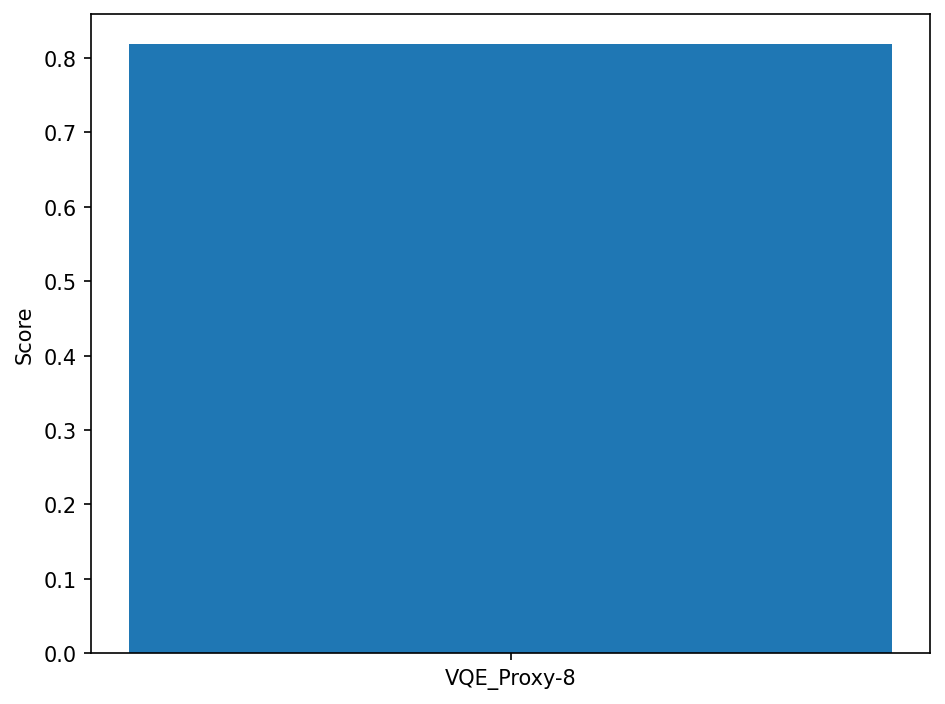

########################################################
********** Executing on ibm_brisbane backend*****************
 For circuit i=         ┌────────────┐  ┌────────────┐     ┌──────────────┐ ┌────────────┐»
 q_0: ───┤ Ry(6.2834) ├──┤ Rz(7.5931) ├──■──┤ Ry(-0.53003) ├─┤ Rz(3.1362) ├»
      ┌──┴────────────┴─┐├────────────┤┌─┴─┐└──────────────┘┌┴────────────┤»
 q_1: ┤ Ry(-0.00098539) ├┤ Rz(4.2731) ├┤ X ├───────■────────┤ Ry(0.52328) ├»
      └──┬────────────┬─┘├────────────┤└───┘     ┌─┴─┐      └─────────────┘»
 q_2: ───┤ Ry(9.4251) ├──┤ Rz(9.6255) ├──────────┤ X ├─────────────■───────»
         ├────────────┤  ├────────────┤          └───┘           ┌─┴─┐     »
 q_3: ───┤ Ry(9.4232) ├──┤ Rz(4.4677) ├──────────────────────────┤ X ├─────»
         ├───────────┬┘  ├────────────┤                          └───┘     »
 q_4: ───┤ Ry(6.284) ├───┤ Rz(3.6387) ├────────────────────────────────────»
         ├───────────┴┐  ├────────────┤                                    »
 q_5: ───┤ Ry(9.431

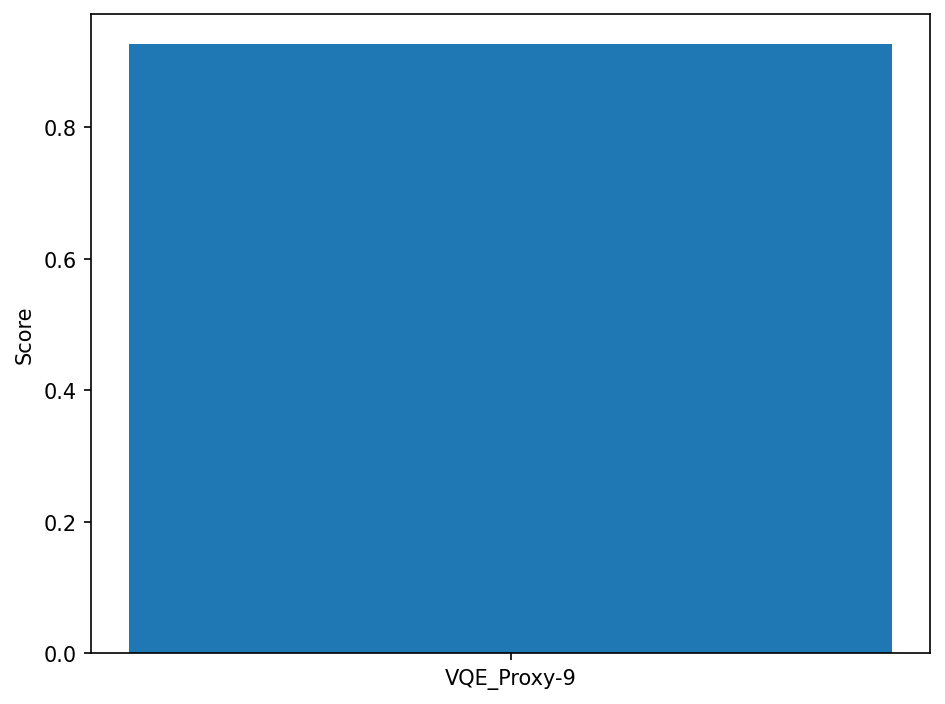

########################################################
********** Executing on ibm_brisbane backend*****************
 For circuit i=       ┌────────────┐┌────────────┐     ┌────────────┐┌────────────┐»
  q_0: ┤ Ry(6.2824) ├┤ Rz(2.8355) ├──■──┤ Ry(3.6736) ├┤ Rz(9.4258) ├»
       ├────────────┤├────────────┤┌─┴─┐└────────────┘├────────────┤»
  q_1: ┤ Ry(9.4241) ├┤ Rz(9.3357) ├┤ X ├──────■───────┤ Ry(6.8052) ├»
       ├────────────┤├────────────┤└───┘    ┌─┴─┐     └────────────┘»
  q_2: ┤ Ry(9.4293) ├┤ Rz(1.3389) ├─────────┤ X ├───────────■───────»
       ├────────────┤├───────────┬┘         └───┘         ┌─┴─┐     »
  q_3: ┤ Ry(12.538) ├┤ Rz(11.73) ├────────────────────────┤ X ├─────»
       ├────────────┤├───────────┴┐                       └───┘     »
  q_4: ┤ Ry(3.2536) ├┤ Rz(6.4287) ├─────────────────────────────────»
       ├────────────┤├───────────┬┘                                 »
  q_5: ┤ Ry(9.6278) ├┤ Rz(6.362) ├──────────────────────────────────»
       ├────────────┤├────

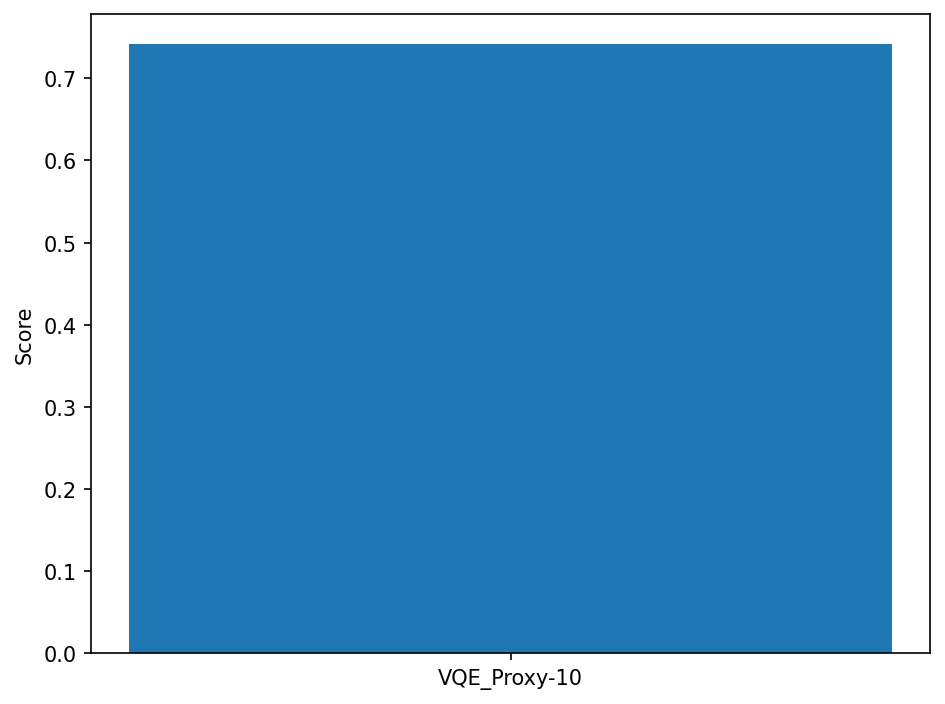

########################################################
********** Executing on ibm_brisbane backend*****************
 For circuit i=       ┌────────────┐  ┌────────────┐      ┌────────────┐┌────────────┐»
  q_0: ┤ Ry(9.0796) ├──┤ Rz(7.9241) ├───■──┤ Ry(8.5552) ├┤ Rz(3.2425) ├»
       ├────────────┤  ├────────────┤ ┌─┴─┐└────────────┘├────────────┤»
  q_1: ┤ Ry(11.555) ├──┤ Rz(1.7964) ├─┤ X ├──────■───────┤ Ry(3.0645) ├»
       ├────────────┤┌─┴────────────┴┐└───┘    ┌─┴─┐     └────────────┘»
  q_2: ┤ Ry(4.2101) ├┤ Rz(-0.052067) ├─────────┤ X ├───────────■───────»
       ├───────────┬┘└─┬────────────┬┘         └───┘         ┌─┴─┐     »
  q_3: ┤ Ry(8.345) ├───┤ Rz(6.2901) ├────────────────────────┤ X ├─────»
       ├───────────┴┐  ├────────────┤                        └───┘     »
  q_4: ┤ Ry(8.3552) ├──┤ Rz(6.2632) ├──────────────────────────────────»
       ├────────────┤  ├────────────┤                                  »
  q_5: ┤ Ry(10.488) ├──┤ Rz(6.2849) ├──────────────────────────

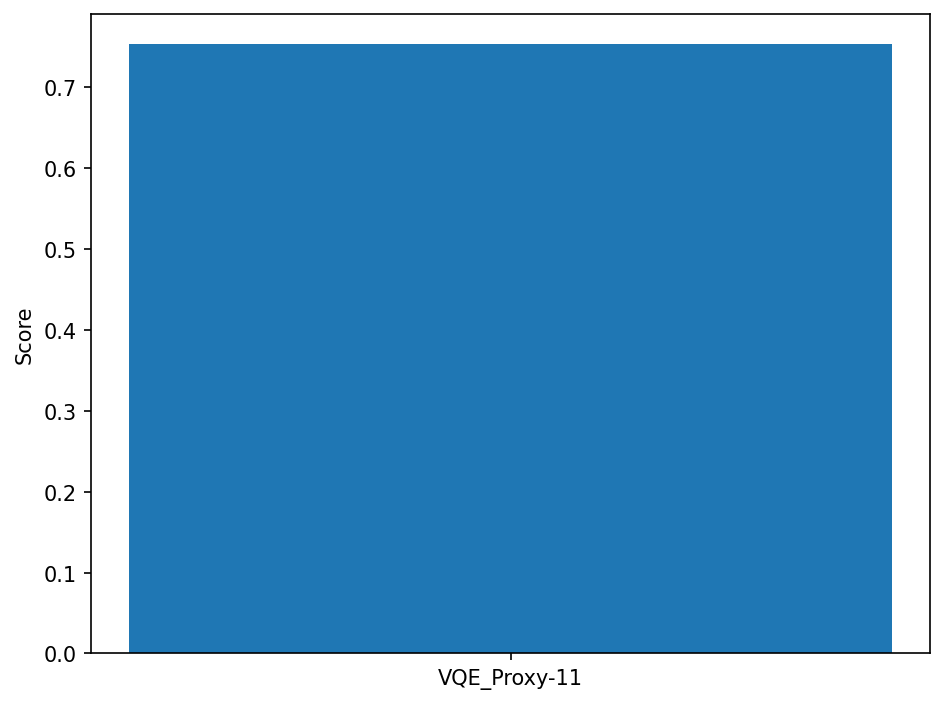

########################################################
********** Executing on ibm_brisbane backend*****************
 For circuit i=        ┌───────────┐  ┌────────────┐     ┌────────────┐ ┌────────────┐ »
  q_0: ─┤ Ry(6.284) ├──┤ Rz(1.9315) ├──■──┤ Ry(8.8889) ├─┤ Rz(12.603) ├─»
        ├───────────┴┐ ├────────────┤┌─┴─┐└────────────┘┌┴────────────┴┐»
  q_1: ─┤ Ry(9.4249) ├─┤ Rz(5.9862) ├┤ X ├──────■───────┤ Ry(-0.53297) ├»
        ├────────────┤ ├────────────┤└───┘    ┌─┴─┐     └──────────────┘»
  q_2: ─┤ Ry(6.2844) ├─┤ Rz(10.035) ├─────────┤ X ├────────────■────────»
        └┬──────────┬┘ ├────────────┤         └───┘          ┌─┴─┐      »
  q_3: ──┤ Ry(3.14) ├──┤ Rz(4.4594) ├────────────────────────┤ X ├──────»
        ┌┴──────────┴┐ ├────────────┤                        └───┘      »
  q_4: ─┤ Ry(9.4297) ├─┤ Rz(11.339) ├───────────────────────────────────»
        ├────────────┤ ├────────────┤                                   »
  q_5: ─┤ Ry(9.4325) ├─┤ Rz(2.1268) ├───────────────

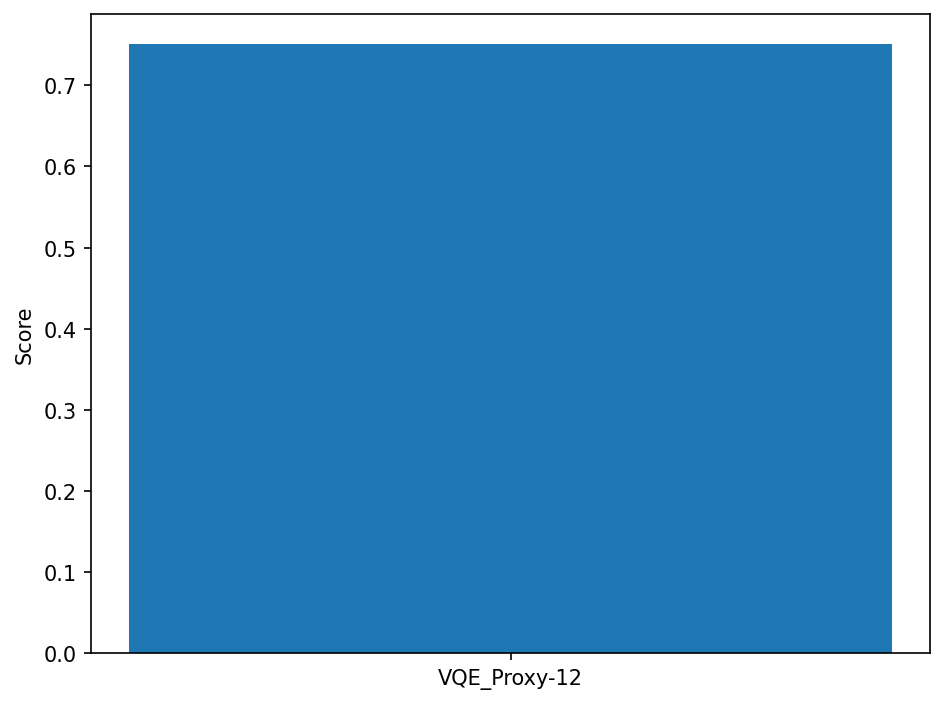

########################################################
********** Executing on ibm_brisbane backend*****************
 For circuit i=       ┌────────────┐┌────────────┐     ┌────────────┐┌────────────┐»
  q_0: ┤ Ry(9.5693) ├┤ Rz(5.8062) ├──■──┤ Ry(11.876) ├┤ Rz(6.2491) ├»
       ├────────────┤├────────────┤┌─┴─┐└────────────┘├────────────┤»
  q_1: ┤ Ry(3.7802) ├┤ Rz(16.421) ├┤ X ├──────■───────┤ Ry(2.0423) ├»
       ├───────────┬┘├────────────┤└───┘    ┌─┴─┐     └────────────┘»
  q_2: ┤ Ry(4.666) ├─┤ Rz(3.4547) ├─────────┤ X ├───────────■───────»
       ├───────────┴┐├────────────┤         └───┘         ┌─┴─┐     »
  q_3: ┤ Ry(11.248) ├┤ Rz(9.3408) ├───────────────────────┤ X ├─────»
       ├────────────┤├────────────┤                       └───┘     »
  q_4: ┤ Ry(8.2422) ├┤ Rz(6.3027) ├─────────────────────────────────»
       └┬──────────┬┘├────────────┤                                 »
  q_5: ─┤ Ry(7.38) ├─┤ Rz(9.4083) ├─────────────────────────────────»
       ┌┴──────────┴┐├────

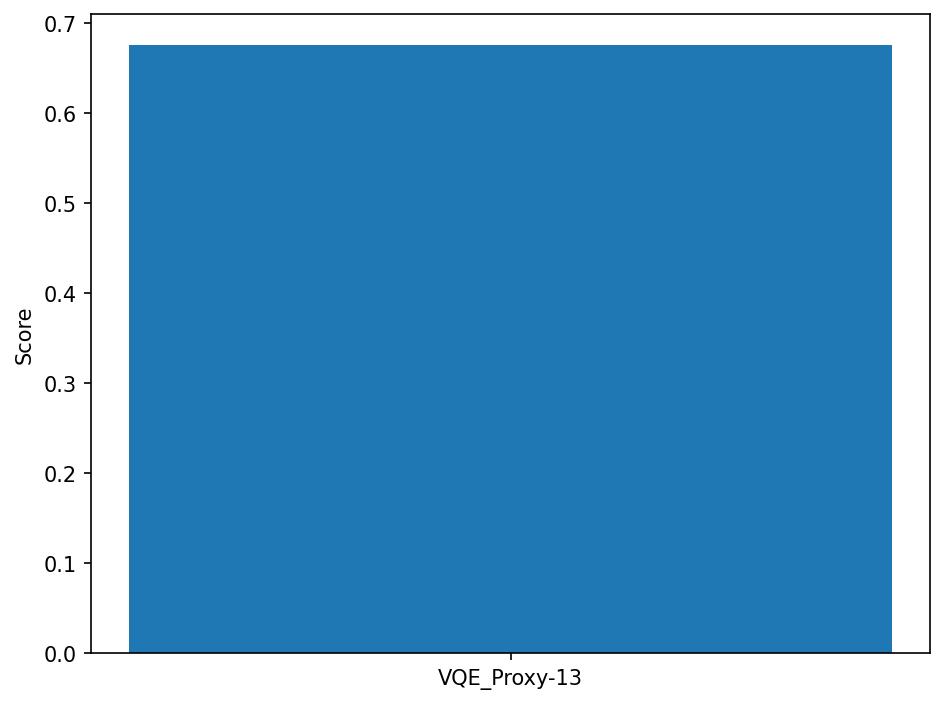

########################################################
********** Executing on ibm_brisbane backend*****************
 For circuit i=       ┌────────────┐┌────────────┐     ┌────────────┐┌────────────┐»
  q_0: ┤ Ry(6.2706) ├┤ Rz(6.8668) ├──■──┤ Ry(12.027) ├┤ Rz(3.1375) ├»
       ├───────────┬┘├────────────┤┌─┴─┐└────────────┘├────────────┤»
  q_1: ┤ Ry(9.485) ├─┤ Rz(13.199) ├┤ X ├──────■───────┤ Ry(3.7122) ├»
       ├───────────┴┐├────────────┤└───┘    ┌─┴─┐     └────────────┘»
  q_2: ┤ Ry(6.4494) ├┤ Rz(12.528) ├─────────┤ X ├───────────■───────»
       ├────────────┤├────────────┤         └───┘         ┌─┴─┐     »
  q_3: ┤ Ry(5.9018) ├┤ Rz(9.6406) ├───────────────────────┤ X ├─────»
       ├────────────┤├────────────┤                       └───┘     »
  q_4: ┤ Ry(14.998) ├┤ Rz(6.1359) ├─────────────────────────────────»
       ├────────────┤├────────────┤                                 »
  q_5: ┤ Ry(10.399) ├┤ Rz(12.522) ├─────────────────────────────────»
       ├────────────┤├────

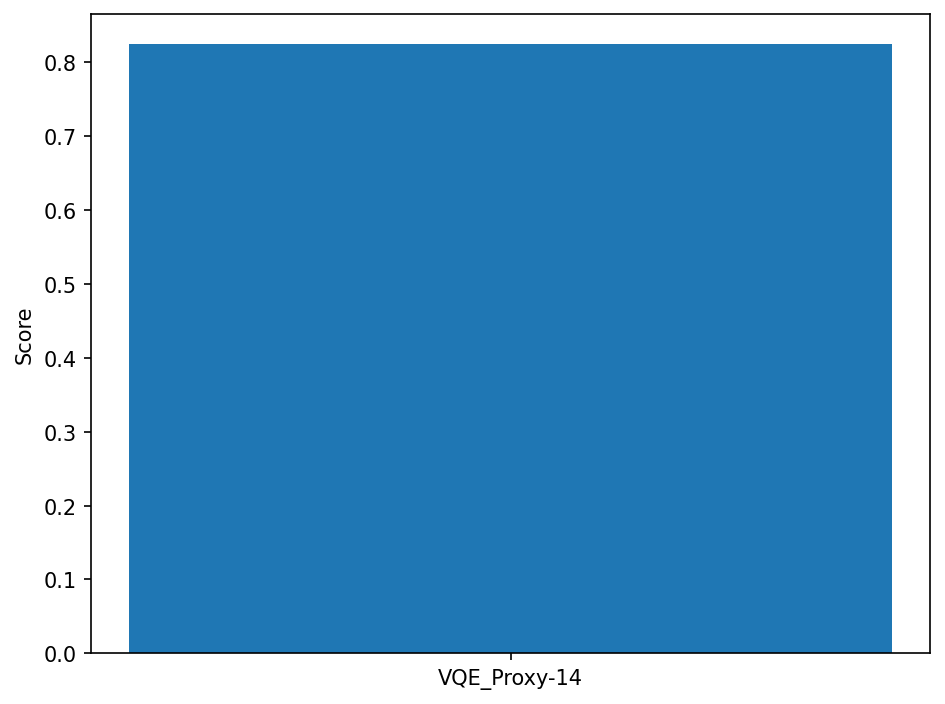

########################################################
********** Executing on ibm_brisbane backend*****************
 For circuit i=       ┌────────────┐  ┌────────────┐      ┌────────────┐┌────────────┐»
  q_0: ┤ Ry(2.3391) ├──┤ Rz(11.038) ├───■──┤ Ry(9.3531) ├┤ Rz(1.5457) ├»
       ├────────────┤  ├────────────┤ ┌─┴─┐└────────────┘├────────────┤»
  q_1: ┤ Ry(2.0177) ├──┤ Rz(12.574) ├─┤ X ├──────■───────┤ Ry(12.781) ├»
       ├────────────┤  ├────────────┤ └───┘    ┌─┴─┐     └────────────┘»
  q_2: ┤ Ry(11.464) ├──┤ Rz(6.2565) ├──────────┤ X ├───────────■───────»
       ├────────────┤  ├────────────┤          └───┘         ┌─┴─┐     »
  q_3: ┤ Ry(11.498) ├──┤ Rz(9.4135) ├────────────────────────┤ X ├─────»
       ├───────────┬┘  ├───────────┬┘                        └───┘     »
  q_4: ┤ Ry(7.362) ├───┤ Rz(12.58) ├───────────────────────────────────»
       ├───────────┴┐  ├───────────┴┐                                  »
  q_5: ┤ Ry(4.2094) ├──┤ Rz(12.579) ├──────────────────────────

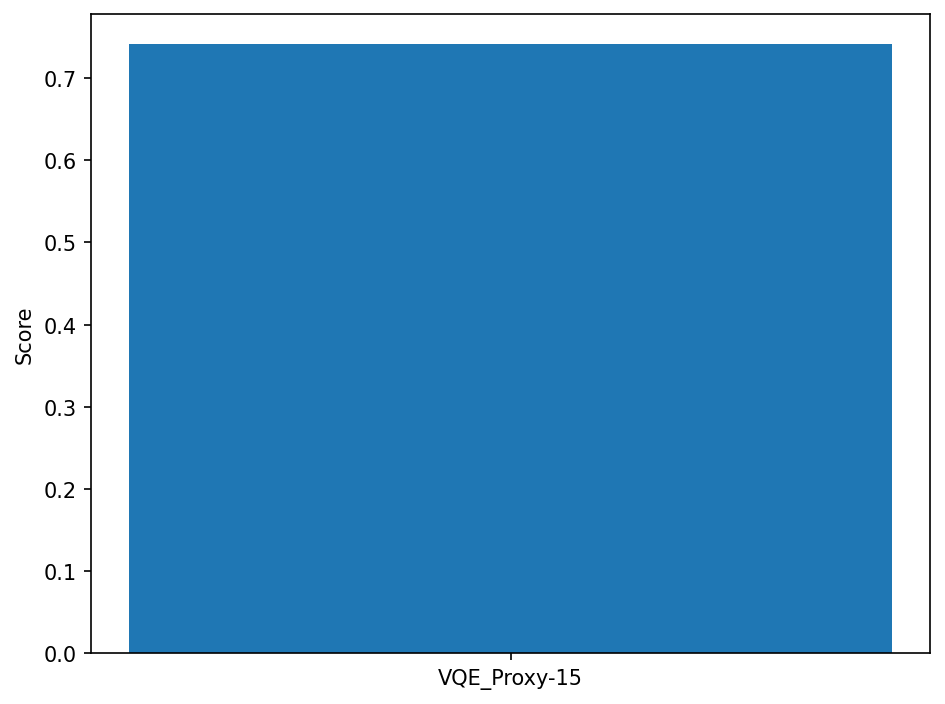

########################################################
********** Executing on ibm_brisbane backend*****************
 For circuit i=        ┌────────────┐ ┌────────────┐      ┌────────────┐┌────────────┐»
  q_0: ─┤ Ry(6.3126) ├─┤ Rz(7.6399) ├───■──┤ Ry(8.8239) ├┤ Rz(6.2983) ├»
       ┌┴────────────┤ ├────────────┤ ┌─┴─┐└────────────┘├────────────┤»
  q_1: ┤ Ry(0.04573) ├─┤ Rz(8.0032) ├─┤ X ├──────■───────┤ Ry(8.9428) ├»
       └┬────────────┤ ├────────────┤ └───┘    ┌─┴─┐     └────────────┘»
  q_2: ─┤ Ry(6.2622) ├─┤ Rz(3.9566) ├──────────┤ X ├───────────■───────»
        ├────────────┤ ├────────────┤          └───┘         ┌─┴─┐     »
  q_3: ─┤ Ry(3.1956) ├─┤ Rz(11.044) ├────────────────────────┤ X ├─────»
        ├────────────┤ ├────────────┤                        └───┘     »
  q_4: ─┤ Ry(12.565) ├─┤ Rz(9.2158) ├──────────────────────────────────»
        ├────────────┤ ├────────────┤                                  »
  q_5: ─┤ Ry(3.1001) ├─┤ Rz(11.874) ├──────────────────────────

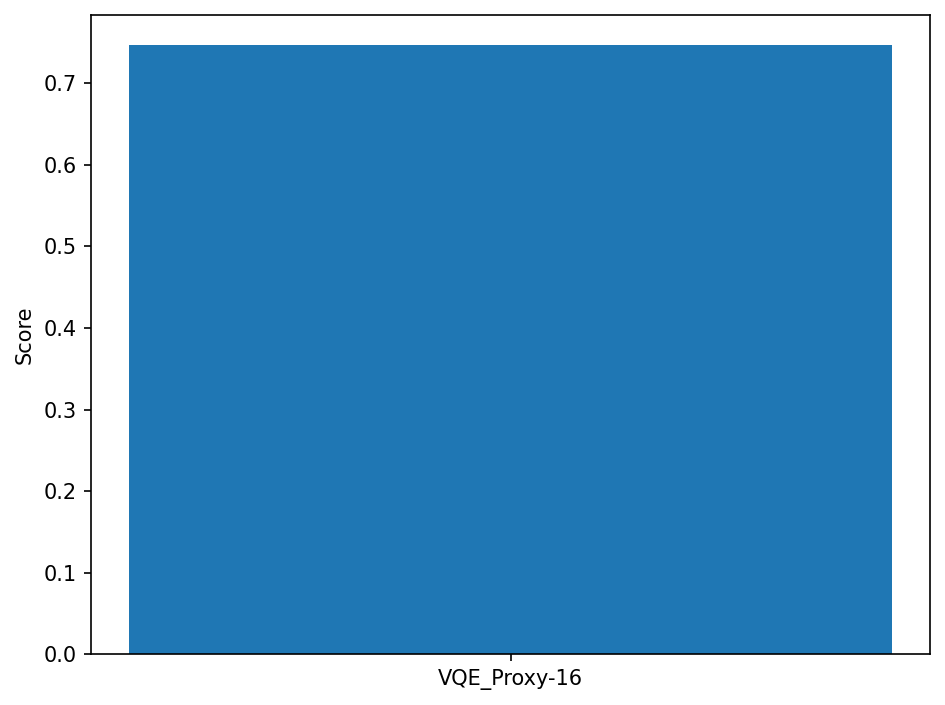

########################################################
********** Executing on ibm_brisbane backend*****************
 For circuit i=       ┌────────────┐ ┌────────────┐      ┌────────────┐┌────────────┐»
  q_0: ┤ Ry(3.1394) ├─┤ Rz(6.9155) ├───■──┤ Ry(12.026) ├┤ Rz(6.3094) ├»
       ├────────────┤ ├────────────┤ ┌─┴─┐└────────────┘├────────────┤»
  q_1: ┤ Ry(9.4426) ├─┤ Rz(5.0147) ├─┤ X ├──────■───────┤ Ry(3.6491) ├»
       ├────────────┤ ├────────────┤ └───┘    ┌─┴─┐     └────────────┘»
  q_2: ┤ Ry(9.4198) ├─┤ Rz(8.7767) ├──────────┤ X ├───────────■───────»
       ├────────────┤ ├────────────┤          └───┘         ┌─┴─┐     »
  q_3: ┤ Ry(6.2914) ├─┤ Rz(10.227) ├────────────────────────┤ X ├─────»
       ├────────────┤ ├────────────┤                        └───┘     »
  q_4: ┤ Ry(6.2579) ├─┤ Rz(8.1947) ├──────────────────────────────────»
       ├────────────┤┌┴────────────┤                                  »
  q_5: ┤ Ry(12.564) ├┤ Rz(0.41899) ├──────────────────────────────────»
  

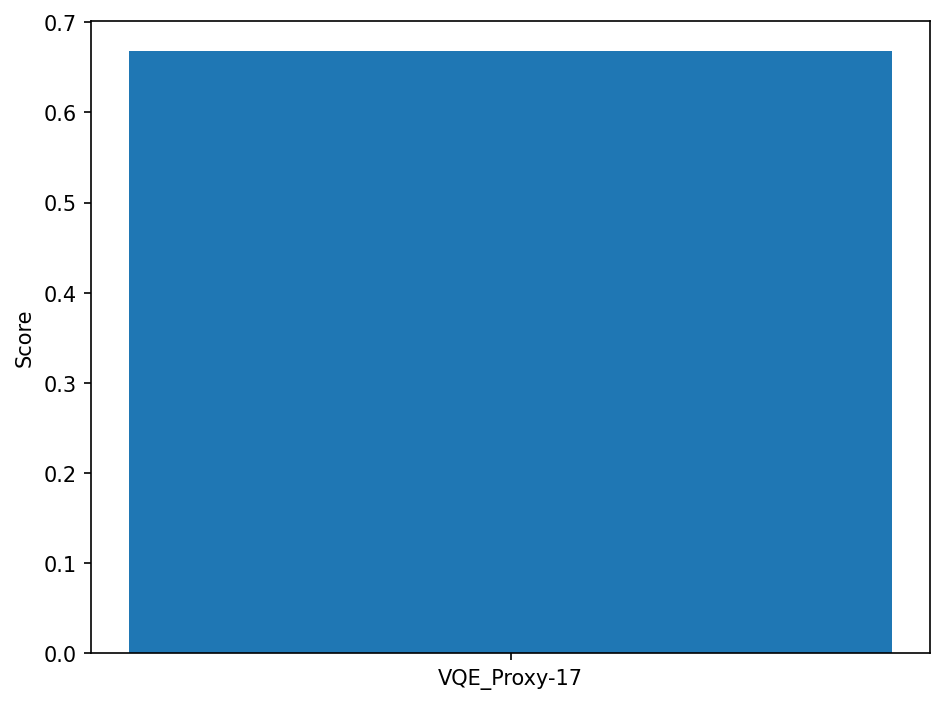

########################################################
********** Executing on ibm_brisbane backend*****************
 For circuit i=       ┌────────────┐  ┌────────────┐      ┌────────────┐┌────────────┐»
  q_0: ┤ Ry(12.532) ├──┤ Rz(9.2177) ├───■──┤ Ry(12.056) ├┤ Rz(9.3136) ├»
       ├────────────┤  ├────────────┤ ┌─┴─┐└────────────┘├────────────┤»
  q_1: ┤ Ry(2.9466) ├──┤ Rz(9.7471) ├─┤ X ├──────■───────┤ Ry(8.6885) ├»
       ├────────────┤  └┬──────────┬┘ └───┘    ┌─┴─┐     └────────────┘»
  q_2: ┤ Ry(11.917) ├───┤ Rz(4.58) ├───────────┤ X ├───────────■───────»
       ├────────────┤  ┌┴──────────┤           └───┘         ┌─┴─┐     »
  q_3: ┤ Ry(8.2463) ├──┤ Rz(3.712) ├─────────────────────────┤ X ├─────»
       ├────────────┤  ├───────────┴┐                        └───┘     »
  q_4: ┤ Ry(10.543) ├──┤ Rz(12.577) ├──────────────────────────────────»
       ├────────────┤  ├────────────┤                                  »
  q_5: ┤ Ry(2.0253) ├──┤ Rz(12.554) ├──────────────────────────

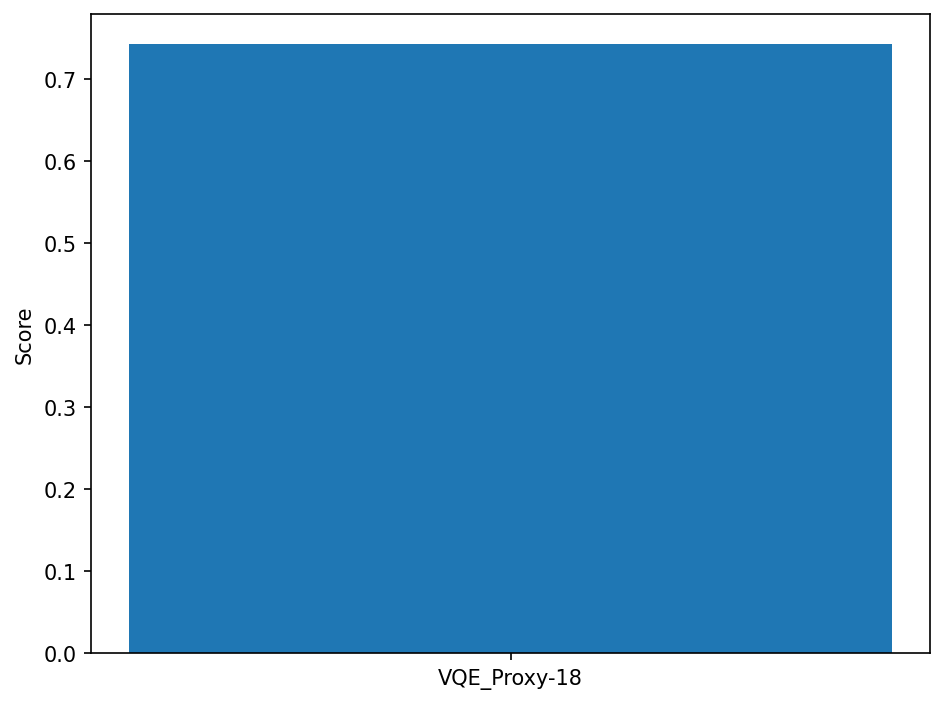

########################################################
********** Executing on ibm_brisbane backend*****************
 For circuit i=        ┌────────────┐ ┌────────────┐      ┌────────────┐┌────────────┐»
  q_0: ─┤ Ry(3.1913) ├─┤ Rz(9.1968) ├───■──┤ Ry(10.128) ├┤ Rz(12.533) ├»
        ├────────────┤┌┴────────────┤ ┌─┴─┐└────────────┘├────────────┤»
  q_1: ─┤ Ry(3.1348) ├┤ Rz(0.35508) ├─┤ X ├──────■───────┤ Ry(6.8519) ├»
        ├────────────┤└┬────────────┤ └───┘    ┌─┴─┐     └────────────┘»
  q_2: ─┤ Ry(12.585) ├─┤ Rz(3.5498) ├──────────┤ X ├───────────■───────»
        ├────────────┤ ├────────────┤          └───┘         ┌─┴─┐     »
  q_3: ─┤ Ry(6.2863) ├─┤ Rz(1.7001) ├────────────────────────┤ X ├─────»
        ├────────────┤ ├────────────┤                        └───┘     »
  q_4: ─┤ Ry(6.0806) ├─┤ Rz(2.1408) ├──────────────────────────────────»
        ├────────────┤ ├────────────┤                                  »
  q_5: ─┤ Ry(13.147) ├─┤ Rz(8.0128) ├──────────────────────────

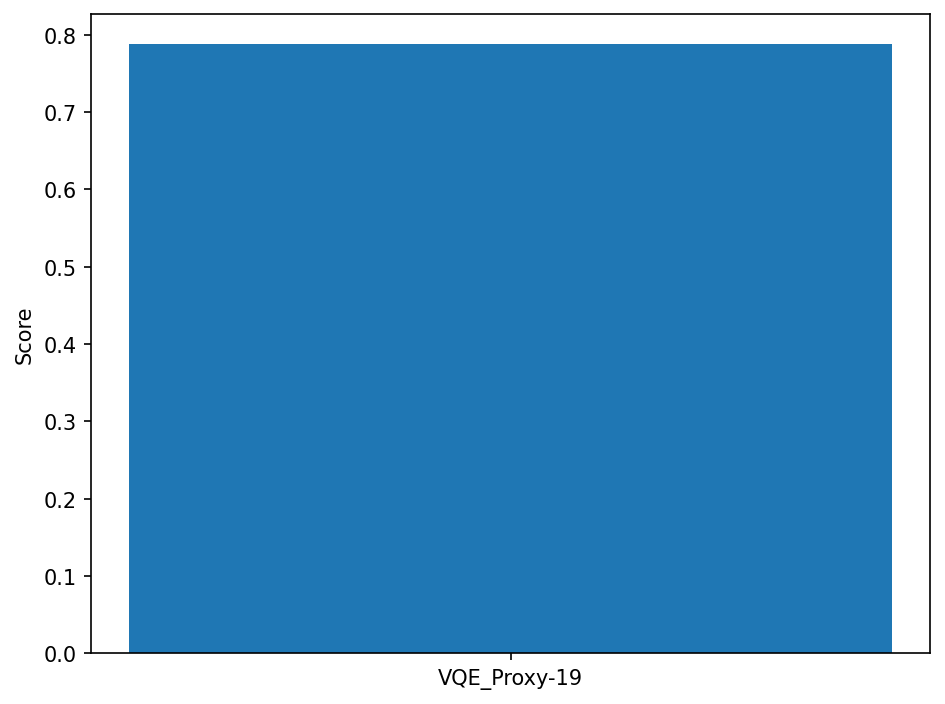

########################################################
********** Executing on ibm_brisbane backend*****************
 For circuit i=       ┌────────────┐  ┌────────────┐      ┌────────────┐┌────────────┐»
  q_0: ┤ Ry(6.7426) ├──┤ Rz(1.1891) ├───■──┤ Ry(7.4405) ├┤ Rz(6.3276) ├»
       ├────────────┤  ├────────────┤ ┌─┴─┐└────────────┘├────────────┤»
  q_1: ┤ Ry(11.374) ├──┤ Rz(4.7833) ├─┤ X ├──────■───────┤ Ry(12.856) ├»
       ├────────────┤  ├────────────┤ └───┘    ┌─┴─┐     └────────────┘»
  q_2: ┤ Ry(11.603) ├──┤ Rz(3.3859) ├──────────┤ X ├───────────■───────»
       ├────────────┤  ├────────────┤          └───┘         ┌─┴─┐     »
  q_3: ┤ Ry(2.2137) ├──┤ Rz(3.0701) ├────────────────────────┤ X ├─────»
       ├────────────┤  ├────────────┤                        └───┘     »
  q_4: ┤ Ry(13.523) ├──┤ Rz(3.1608) ├──────────────────────────────────»
       ├───────────┬┘  ├───────────┬┘                                  »
  q_5: ┤ Ry(5.196) ├───┤ Rz(9.458) ├───────────────────────────

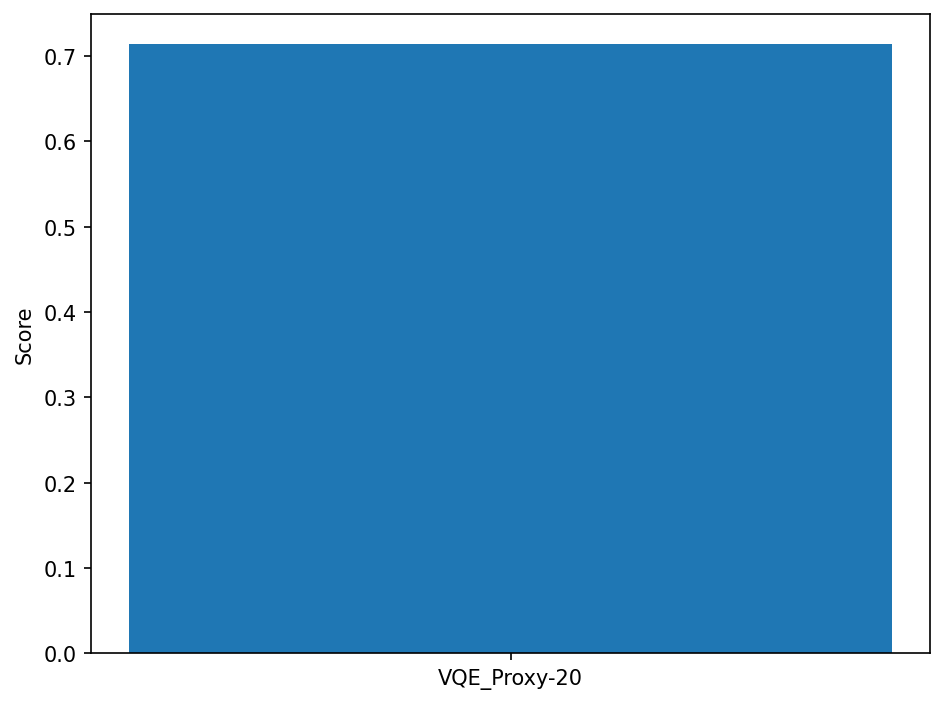

########################################################


In [7]:
import simulation,time

def VQEP(qubits,l):
    
    name = "VQE_Proxy"
    final_counts = []
    ckt_list = []
    execution_times = []
    quantum_times = []
    
    # Calculate Creation time 
    t_c = time.time()
    #vqe = VQEProxy(3, 1) #3 Qubits, 1 Layer
    vqe = VQEProxy(qubits, l)
    shots = 1000
    ckts =  vqe.circuit()
    creation_time = time.time()-t_c
    
    for i in ckts:
        ckt_list.append(cirq_to_qiskit(i))
    
    #print(f" Creation time for {len(ckt_list)} circuits = {creation_time} sec")
    
    # for i in ckts:
    #     print(i)
    
    for i in ckt_list:
        qc=i
        # Calculate Execution time 
        print(f"********** Executing on {backend.name} backend*****************")
        qc = transpile(qc, backend=backend, optimization_level=2)
        t_e = time.time()
        job = sampler.run([qc], shots=shots)
        result = job.result()
        execution_time = time.time() - t_e #in sec
    
        # Calculate quantum processing time 
        quantum_time = (job.usage()) #in sec
        #finding creg
        reg = qc.cregs[0].name
        counts = result[0].data[reg].get_counts()
        #print("counts : ",counts)
    
        print(f" For circuit i={i}, execution time = {execution_time} sec and quantum time = {quantum_time} sec")
    
        final_counts.append(counts)
        execution_times.append(execution_time)
        quantum_times.append(quantum_time)
    print("Final Counts:",final_counts)
    qubits = vqe.num_qubits
    print(f"for {len(ckt_list)} circuits of {qubits} qubits Creation time = {creation_time} sec, Execution time = {sum(execution_times)} sec and quantum time = {sum(quantum_times)} sec")
    
    score_vqe = vqe.score(final_counts)
    print(score_vqe)
    
    
    benchmark_name = f"{name}-{qubits}"
    plot_results([score_vqe],[benchmark_name])
    
    print("########################################################")

    # #Features = dict()
        
    # for i in ckt_list:
    #     features = [
    #     compute_communication_with_qiskit(i),
    #     compute_depth_with_qiskit(i),
    #     compute_entanglement_with_qiskit(i),
    #     compute_liveness_with_qiskit(i),
    #     compute_measurement_with_qiskit(i),
    #     compute_parallelism_with_qiskit(i),
    #     ]
    #     print(f"Features for ckt {i.name}: {features}")
    #     Features[str(name)+{i.name}] = features
    #     plot_benchmark(title=f"A single {name} benchmark",labels=[benchmark_name],features=[features],
    #                        spoke_labels=["PC", "CD", "Ent", "Liv", "Mea", "Par"] )
    
    # vqe_label = str(name)+"_"+str(qubits)
    # vqe_features = Features
    # vqe_score = score_vqe

if __name__=="__main__":
    for i in range(3,21):
        VQEP(i,1)

# Measure the correlation between device performance and application features

In [ ]:
device_scores

In [ ]:
#scores_device = [0.053,0.86,0.5,0.54,0.49]
scores_device = {'GHZ_12':0.05279864858694865,'Hamiltonian Simulation_12':0.863196609406728,
                 'MerminBell_12':0.5,'QAOAFermionicSwapProxy_12':0.5390578841972726,'QAOAVanillaProxy_12':0.4911652258960335}

In [ ]:
plot_correlations(
    benchmark_features,
    scores_device,
    ["PC", "CD", "Ent", "Liv", "Mea", "Par"],
    device_name=backend.name,
)